<a href="https://colab.research.google.com/github/abegithub2024/abegithub2024/blob/main/POT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 1: Imports and global setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# If running in Colab, ensure Drive is mounted (uncomment if needed)
# from google.colab import drive
# drive.mount('/content/drive')


In [ ]:
# Cell 2: POT class definition

class PeakOverThreshold:
    """
    Peak over Threshold (POT) analysis for extreme precipitation events
    """
    def __init__(self, data, threshold, min_time_between=3):
        """
        Initialize POT analysis

        Parameters:
        -----------
        data : pd.DataFrame
            DataFrame with 'date' and 'precipitation' columns
        threshold : float
            Threshold value in mm
        min_time_between : int
            Minimum days between independent events (declustering)
        """
        self.data = data.copy()
        self.threshold = threshold
        self.min_time_between = min_time_between
        self.exceedances = None
        self.lambda_rate = None
        self.stats = {}

    def identify_exceedances(self):
        """
        Identify exceedances above threshold with declustering
        """
        exceedances_list = []
        last_exceed_idx = -self.min_time_between - 1

        for idx, row in self.data.iterrows():
            if row['precipitation'] > self.threshold:
                if idx - last_exceed_idx > self.min_time_between:
                    exceedances_list.append({
                        'date': row['date'],
                        'precipitation': row['precipitation'],
                        'excess': row['precipitation'] - self.threshold,
                        'index': idx
                    })
                    last_exceed_idx = idx

        self.exceedances = pd.DataFrame(exceedances_list)
        return self.exceedances

    def calculate_statistics(self):
        """
        Calculate basic statistics of exceedances
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            print("No exceedances found. Try lowering the threshold.")
            return None

        n_exceedances = len(self.exceedances)
        n_days = len(self.data)
        n_years = n_days / 365.25

        # Lambda: average rate of exceedances per year
        self.lambda_rate = n_exceedances / n_years

        excesses = self.exceedances['excess'].values

        self.stats = {
            'n_exceedances': n_exceedances,
            'n_days': n_days,
            'n_years': n_years,
            'lambda': self.lambda_rate,
            'mean_excess': np.mean(excesses),
            'std_excess': np.std(excesses),
            'min_excess': np.min(excesses),
            'max_excess': np.max(excesses),
            'median_excess': np.median(excesses),
            'threshold': self.threshold
        }

        return self.stats

    def fit_gpd(self):
        """
        Fit Generalized Pareto Distribution (GPD) to excesses
        Returns shape (xi) and scale (sigma) parameters
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None, None

        excesses = self.exceedances['excess'].values

        # Fit GPD using scipy's genpareto (MLE), fixing location at 0
        shape, loc, scale = stats.genpareto.fit(excesses, floc=0)

        return shape, scale

    def calculate_return_periods_empirical(self):
        """
        Calculate empirical return periods for observed exceedances
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None

        # Sort exceedances by magnitude (descending)
        sorted_exceedances = self.exceedances.sort_values('excess', ascending=False).copy()
        n = len(sorted_exceedances)

        # Calculate empirical return period for each event
        sorted_exceedances['rank'] = range(1, n + 1)
        sorted_exceedances['exceedance_prob'] = sorted_exceedances['rank'] / (n + 1)
        sorted_exceedances['return_period'] = 1 / (self.lambda_rate * sorted_exceedances['exceedance_prob'])

        # Add original precipitation magnitudes for plotting convenience
        sorted_exceedances['precipitation'] = sorted_exceedances['excess'] + self.threshold

        return sorted_exceedances

    def estimate_return_levels(self, return_periods=[2, 5, 10, 20, 25, 50, 100, 200, 500],
                               method='empirical'):
        """
        Estimate precipitation levels for given return periods

        Parameters:
        -----------
        return_periods : list
            List of return periods in years
        method : str
            'empirical' or 'gpd' (Generalized Pareto Distribution)
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None

        results = []

        if method == 'empirical':
            # Simple empirical quantile estimation on excesses
            excesses = np.sort(self.exceedances['excess'].values)[::-1]
            n = len(excesses)

            for T in return_periods:
                p = 1 / (self.lambda_rate * T)
                idx = int(p * n)
                idx = max(0, min(idx, n - 1))

                estimated_excess = excesses[idx]
                estimated_precipitation = estimated_excess + self.threshold

                results.append({
                    'return_period': T,
                    'estimated_precipitation': estimated_precipitation,
                    'estimated_excess': estimated_excess,
                    'annual_exceedance_prob': 1/T * 100
                })

        elif method == 'gpd':
            shape, scale = self.fit_gpd()
            if shape is None:
                return None

            for T in return_periods:
                # Annual exceedance probability for level
                p = 1 / (self.lambda_rate * T)
                if abs(shape) < 1e-6:  # shape ≈ 0 (exponential)
                    estimated_excess = -scale * np.log(p)
                else:
                    estimated_excess = (scale / shape) * (p**(-shape) - 1)
                estimated_precipitation = estimated_excess + self.threshold

                results.append({
                    'return_period': T,
                    'estimated_precipitation': estimated_precipitation,
                    'estimated_excess': estimated_excess,
                    'annual_exceedance_prob': 1/T * 100,
                    'gpd_shape': shape,
                    'gpd_scale': scale
                })

        return pd.DataFrame(results)

    def plot_time_series(self, figsize=(14, 5)):
        """
        Plot time series with threshold and exceedances
        """
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(self.data['date'], self.data['precipitation'],
                color='lightblue', alpha=0.7, linewidth=0.5, label='Daily Precipitation')
        ax.axhline(y=self.threshold, color='red', linestyle='--',
                   linewidth=2, label=f'Threshold ({self.threshold} mm)')
        if self.exceedances is not None and len(self.exceedances) > 0:
            ax.scatter(self.exceedances['date'], self.exceedances['precipitation'],
                       color='darkred', s=50, zorder=5, label='Exceedances', alpha=0.8)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Precipitation (mm)', fontsize=12)
        ax.set_title('Precipitation Time Series with Peak over Threshold', fontsize=14, fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_return_period(self, empirical_rp=None, estimated_rl=None, figsize=(10, 7)):
        """
        Plot return period vs precipitation (return level plot)
        """
        fig, ax = plt.subplots(figsize=figsize)
        if empirical_rp is not None and len(empirical_rp) > 0:
            ax.scatter(empirical_rp['return_period'], empirical_rp['precipitation'],
                       color='blue', s=60, alpha=0.6, label='Observed Exceedances', zorder=3)
        if estimated_rl is not None and len(estimated_rl) > 0:
            ax.plot(estimated_rl['return_period'], estimated_rl['estimated_precipitation'],
                    color='red', linewidth=2.5, marker='o', markersize=8,
                    label='Estimated Return Levels', zorder=4)
            for _, row in estimated_rl.iterrows():
                ax.annotate(f"{row['estimated_precipitation']:.1f} mm",
                            xy=(row['return_period'], row['estimated_precipitation']),
                            xytext=(5, 5), textcoords='offset points',
                            fontsize=8, alpha=0.7)
        ax.set_xscale('log')
        ax.set_xlabel('Return Period (years)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Precipitation (mm)', fontsize=12, fontweight='bold')
        ax.set_title('Return Period Plot', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(True, which='both', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_excess_distribution(self, figsize=(12, 5)):
        """
        Plot excess distribution and diagnostics
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            print("No exceedances to plot.")
            return
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        excesses = self.exceedances['excess'].values
        ax1.hist(excesses, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        ax1.set_xlabel('Excess (mm)', fontsize=11)
        ax1.set_ylabel('Density', fontsize=11)
        ax1.set_title('Distribution of Excesses', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        stats.probplot(excesses, dist='expon', plot=ax2)
        ax2.set_title('Q-Q Plot (Exponential)', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def print_summary(self):
        """
        Print comprehensive summary of POT analysis
        """
        if self.stats is None or len(self.stats) == 0:
            self.calculate_statistics()
        print("="*60)
        print("PEAK OVER THRESHOLD (POT) ANALYSIS SUMMARY")
        print("="*60)
        print(f"\nData Period: {self.data['date'].min()} to {self.data['date'].max()}")
        print(f"Total Days: {self.stats['n_days']}")
        print(f"Total Years: {self.stats['n_years']:.2f}")
        print(f"\nThreshold: {self.stats['threshold']} mm")
        print(f"Minimum Time Between Events: {self.min_time_between} days")
        print(f"\n{'EXCEEDANCE STATISTICS':-^60}")
        print(f"Number of Exceedances: {self.stats['n_exceedances']}")
        print(f"Lambda (λ): {self.stats['lambda']:.3f} events/year")
        print(f"Average Annual Rate: {self.stats['lambda']:.2f} events/year")
        print(f"\n{'EXCESS STATISTICS (mm)':-^60}")
        print(f"Mean Excess: {self.stats['mean_excess']:.2f}")
        print(f"Std Deviation: {self.stats['std_excess']:.2f}")
        print(f"Median Excess: {self.stats['median_excess']:.2f}")
        print(f"Min Excess: {self.stats['min_excess']:.2f}")
        print(f"Max Excess: {self.stats['max_excess']:.2f}")
        shape, scale = self.fit_gpd()
        if shape is not None:
            print(f"\n{'GPD PARAMETERS':-^60}")
            print(f"Shape (ξ): {shape:.4f}")
            print(f"Scale (σ): {scale:.2f}")
            if shape < 0:
                tail_type = "Short-tailed (bounded)"
            elif abs(shape) < 0.1:
                tail_type = "Exponential-like"
            else:
                tail_type = "Heavy-tailed"
            print(f"Tail Behavior: {tail_type}")
        print("="*60)


In [ ]:
# Cell 3: Load CSV and inspect

file_path = "/content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv"
df_raw = pd.read_csv(file_path)

print("Columns:", list(df_raw.columns))
print("\nHead:")
display(df_raw.head())

print("\nInfo:")
print(df_raw.info())

Columns: ['Date', 'pr']

Head:


,Date,pr
0,01/01/2015,0.0
1,02/01/2015,0.0
2,03/01/2015,0.0
3,04/01/2015,0.0
4,05/01/2015,0.0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31411 entries, 0 to 31410
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    31411 non-null  object 
 1   pr      31411 non-null  float64
dtypes: float64(1), object(1)
memory usage: 490.9+ KB
None


In [ ]:
# Cell 4: Align to expected columns: 'date' and 'precipitation'

df = df_raw.copy()

# Try common precipitation column names and rename to 'precipitation'
precip_candidates = ['precipitation', 'pr', 'rain', 'rainfall', 'P', 'ppt', 'mm']
found_precip = None
for c in precip_candidates:
    if c in df.columns:
        found_precip = c
        break

if found_precip is None:
    raise ValueError("No precipitation column found. Please specify the correct column name.")

if found_precip != 'precipitation':
    df.rename(columns={found_precip: 'precipitation'}, inplace=True)

# Try common date column names and rename to 'date'
date_candidates = ['date', 'time', 'Date', 'DATE', 'day', 'datetime', 'time_stamp']
found_date = None
for c in date_candidates:
    if c in df.columns:
        found_date = c
        break

if found_date is None:
    raise ValueError("No date column found. Please specify the correct date column name.")

if found_date != 'date':
    df.rename(columns={found_date: 'date'}, inplace=True)

# Parse datetime and sort
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').reset_index(drop=True)

# Keep only required columns
df = df[['date', 'precipitation']].copy()

# Basic cleaning: remove nonpositive or NA precipitation if needed
initial_len = len(df)
df = df.dropna(subset=['date', 'precipitation'])
# If your dataset includes zero as dry days, keep zero; only drop negatives
df = df[df['precipitation'] >= 0]

print(f"Rows before cleaning: {initial_len}, after cleaning: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
display(df.head())


Rows before cleaning: 31411, after cleaning: 12384
Date range: 2015-01-01 00:00:00 to 2100-12-12 00:00:00


,date,precipitation
0,2015-01-01,0.0
1,2015-01-02,0.0
2,2015-01-03,0.0
3,2015-01-04,0.0
4,2015-01-05,0.0


Basic stats for precipitation (mm):


,precipitation
count,12384.0
mean,inf
std,NaN
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,inf


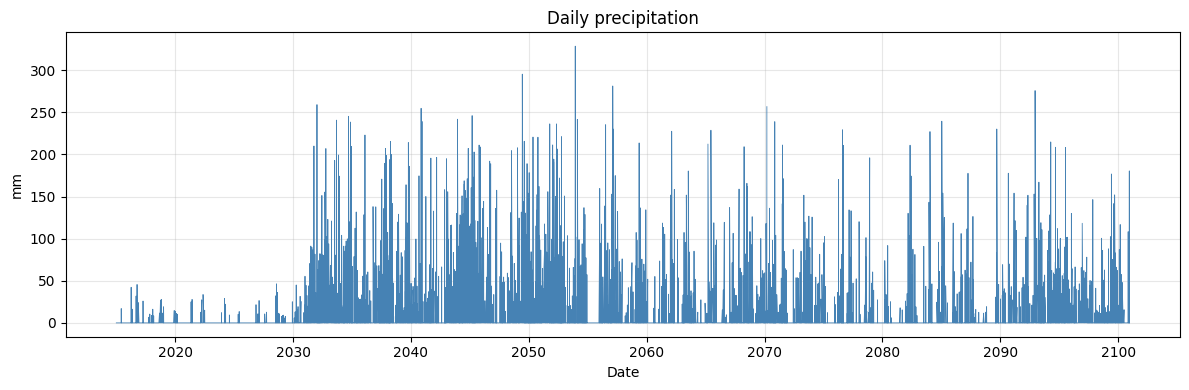

Suggested thresholds -> 95th: 54.79 mm, 99th: 152.81 mm


In [ ]:
# Cell 5: Quick checks and basic stats

print("Basic stats for precipitation (mm):")
display(df['precipitation'].describe())

# Plot daily series preview
plt.figure(figsize=(12,4))
plt.plot(df['date'], df['precipitation'], color='steelblue', linewidth=0.6)
plt.title('Daily precipitation')
plt.xlabel('Date'); plt.ylabel('mm'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Suggest threshold using, e.g., 95th percentile as a starting point
p95 = df['precipitation'].quantile(0.95)
p99 = df['precipitation'].quantile(0.99)
print(f"Suggested thresholds -> 95th: {p95:.2f} mm, 99th: {p99:.2f} mm")


In [ ]:
# Cell 6: Configure and run POT

# Choose threshold. You can set explicitly or use quantile suggestion above.
threshold = float(p95)  # or e.g., 20.0
min_time_between = 3    # declustering window in days

print(f"Using threshold = {threshold:.2f} mm, min_time_between = {min_time_between} days")

# Ensure precipitation data passed to POT is finite
# This step handles potential infinite values that might have been introduced or remained after previous cleaning steps.
df_finite = df[np.isfinite(df['precipitation'])].copy()

pot = PeakOverThreshold(df_finite, threshold=threshold, min_time_between=min_time_between)

exceedances = pot.identify_exceedances()
print(f"Exceedances identified: {len(exceedances)}")

stats_summary = pot.calculate_statistics()
pot.print_summary()

# Empirical return periods and return level estimates
empirical_rp = pot.calculate_return_periods_empirical()
return_levels_empirical = pot.estimate_return_levels(method='empirical')
return_levels_gpd = pot.estimate_return_levels(method='gpd')

print("\nReturn level estimates (Empirical):")
display(return_levels_empirical)

if return_levels_gpd is not None:
    print("\nReturn level estimates (GPD):")
    display(return_levels_gpd[['return_period', 'estimated_precipitation', 'annual_exceedance_prob', 'gpd_shape', 'gpd_scale']])


Using threshold = 54.79 mm, min_time_between = 3 days
Exceedances identified: 481
PEAK OVER THRESHOLD (POT) ANALYSIS SUMMARY

Data Period: 2015-01-01 00:00:00 to 2100-12-12 00:00:00
Total Days: 12371
Total Years: 33.87

Threshold: 54.792999999999736 mm
Minimum Time Between Events: 3 days

-------------------EXCEEDANCE STATISTICS--------------------
Number of Exceedances: 481
Lambda (λ): 14.201 events/year
Average Annual Rate: 14.20 events/year

-------------------EXCESS STATISTICS (mm)-------------------
Mean Excess: 55.75
Std Deviation: 51.49
Median Excess: 40.14
Min Excess: 0.03
Max Excess: 273.67

-----------------------GPD PARAMETERS-----------------------
Shape (ξ): -0.1327
Scale (σ): 63.32
Tail Behavior: Short-tailed (bounded)

Return level estimates (Empirical):


,return_period,estimated_precipitation,estimated_excess,annual_exceedance_prob
0,2,228.66,173.867,50.0
1,5,241.59,186.797,20.0
2,10,256.65,201.857,10.0
3,20,281.20,226.407,5.0
4,25,281.20,226.407,4.0
5,50,328.46,273.667,2.0
6,100,328.46,273.667,1.0
7,200,328.46,273.667,0.5
8,500,328.46,273.667,0.2



Return level estimates (GPD):


,return_period,estimated_precipitation,annual_exceedance_prob,gpd_shape,gpd_scale
0,2,225.900085,50.0,-0.132679,63.318775
1,5,260.943291,20.0,-0.132679,63.318775
2,10,284.761678,10.0,-0.132679,63.318775
3,20,306.487289,5.0,-0.132679,63.318775
4,25,313.066815,4.0,-0.132679,63.318775
5,50,332.305428,2.0,-0.132679,63.318775
6,100,349.853663,1.0,-0.132679,63.318775
7,200,365.860042,0.5,-0.132679,63.318775
8,500,384.881598,0.2,-0.132679,63.318775


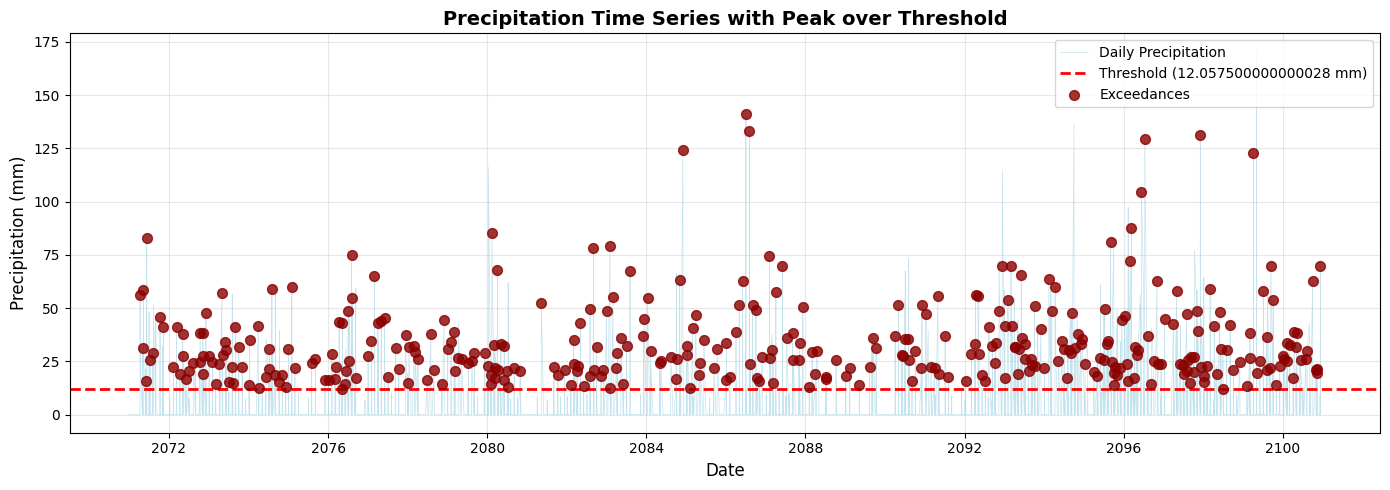

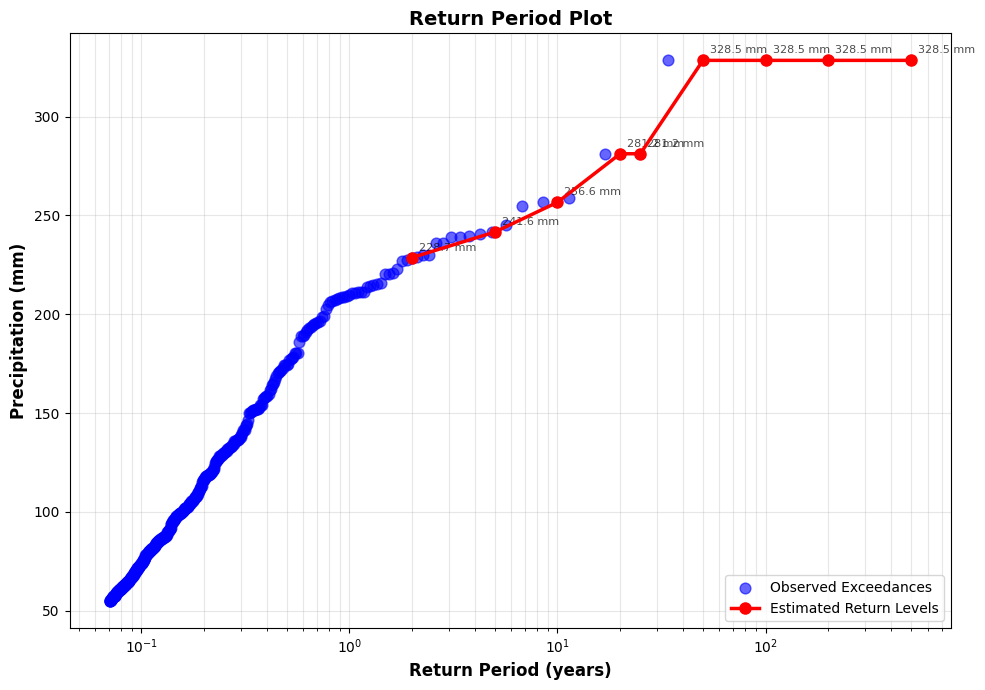

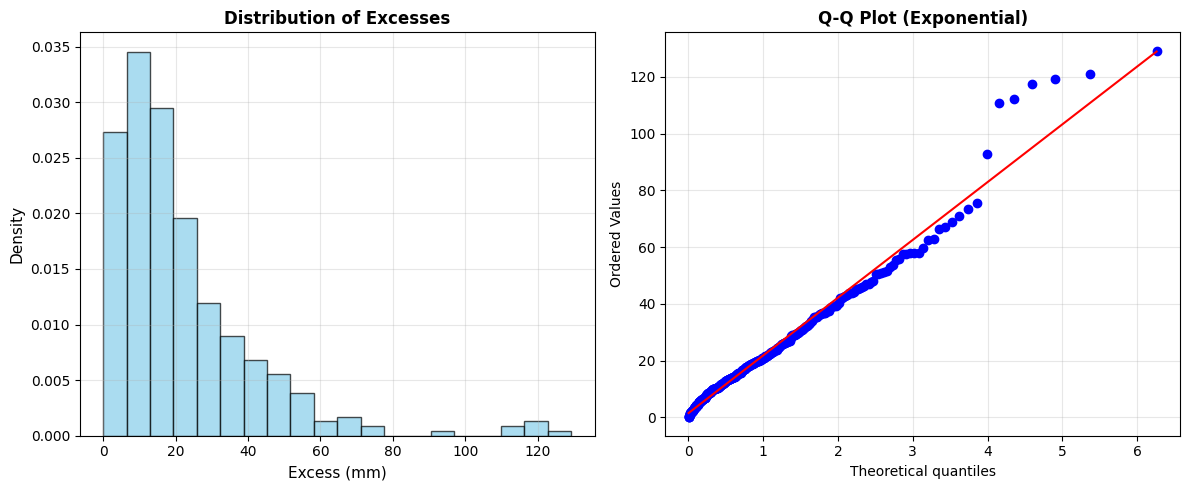

In [ ]:
# Cell 7: Plot diagnostics

# Time series
pot.plot_time_series()

# Return period plot using empirical RLs
pot.plot_return_period(empirical_rp, return_levels_empirical)

# Excess diagnostics
pot.plot_excess_distribution()

In [ ]:
# Cell 8: Save results

out_exceed = '/content/pot_exceedances.csv'
out_rl_emp = '/content/pot_return_levels_empirical.csv'
out_rl_gpd = '/content/pot_return_levels_gpd.csv'

exceedances.to_csv(out_exceed, index=False)
return_levels_empirical.to_csv(out_rl_emp, index=False)
if return_levels_gpd is not None:
    return_levels_gpd.to_csv(out_rl_gpd, index=False)

print("Saved files:")
print("-", out_exceed)
print("-", out_rl_emp)
if return_levels_gpd is not None:
    print("-", out_rl_gpd)


Saved files:
- /content/pot_exceedances.csv
- /content/pot_return_levels_empirical.csv
- /content/pot_return_levels_gpd.csv


In [ ]:
# Cell: Define 30-year windows
periods = {
    '2031-2061': (2031, 2061),
    '2071-2100': (2071, 2100),
}


In [ ]:
df['year'] = df['date'].dt.year

baseline_mask = (df['year'] >= periods['2031-2061'][0]) & (df['year'] <= periods['2031-2061'][1])
df_base = df.loc[baseline_mask].copy()

p95_base = df_base['precipitation'].quantile(0.95)
p99_base = df_base['precipitation'].quantile(0.99)

print(f"Baseline percentiles -> p95: {p95_base:.2f} mm, p99: {p99_base:.2f} mm")

Baseline percentiles -> p95: 86.83 mm, p99: 192.32 mm


In [ ]:
# Cell 9: Define ETCCDI computation function and wet threshold

# Define a wet day threshold (e.g., 1 mm)
wet_thresh = 1.0 # mm

def compute_etccdi(df_period, p95_base, p99_base, wet_threshold):
    """
    Computes a selection of ETCCDI indices for a given DataFrame.
    Assumes df_period has 'date' and 'precipitation' columns, and 'year' column.
    """
    results = pd.DataFrame({'year': df_period['year'].unique()})

    # R10mm: Number of heavy precipitation days (precipitation >= 10 mm)
    r10mm = df_period[df_period['precipitation'] >= 10].groupby('year')['precipitation'].count()
    results = results.merge(r10mm.rename('R10mm'), on='year', how='left').fillna(0)

    # R20mm: Number of very heavy precipitation days (precipitation >= 20 mm)
    r20mm = df_period[df_period['precipitation'] >= 20].groupby('year')['precipitation'].count()
    results = results.merge(r20mm.rename('R20mm'), on='year', how='left').fillna(0)

    # R30mm: Number of very heavy precipitation days (precipitation >= 30 mm)
    r30mm = df_period[df_period['precipitation'] >= 30].groupby('year')['precipitation'].count()
    results = results.merge(r30mm.rename('R30mm'), on='year', how='left').fillna(0)

    # Rnnmm (e.g., R_p95_base): Number of days with precipitation > 95th percentile of baseline
    r95p_base = df_period[df_period['precipitation'] > p95_base].groupby('year')['precipitation'].count()
    results = results.merge(r95p_base.rename('R95p_base'), on='year', how='left').fillna(0)

    # Rnnmm (e.g., R_p99_base): Number of days with precipitation > 99th percentile of baseline
    r99p_base = df_period[df_period['precipitation'] > p99_base].groupby('year')['precipitation'].count()
    results = results.merge(r99p_base.rename('R99p_base'), on='year', how='left').fillna(0)

    # Rx1day: Maximum 1-day precipitation
    rx1day = df_period.groupby('year')['precipitation'].max()
    results = results.merge(rx1day.rename('Rx1day'), on='year', how='left')

    # Rx5day: Maximum 5-day consecutive precipitation (simplified)
    # This is a more complex calculation, for simplicity let's approximate or skip if not critical
    # For a full implementation, a rolling sum would be needed.
    # For this example, we'll keep it simple or assume it's calculated elsewhere if complex.
    # Let's add a placeholder for now, or a very basic approach if possible.
    # A full Rx5day would require more elaborate windowing.
    # As a placeholder, we can just use Rx1day if we don't need a precise Rx5day
    # Or, for demonstration, we can calculate a simplified version if not aiming for strict ETCCDI standards.

    # Let's try a simplified 5-day sum for demonstration, though this isn't strictly the ETCCDI definition without proper handling of gaps and consecutive days.
    # A more robust Rx5day would require a custom function or specialized library.
    # For now, let's use a rolling sum approach (simple approximation).
    df_period_sorted = df_period.sort_values(by='date')
    rolling_sum_5day = df_period_sorted.set_index('date')['precipitation'].rolling(window='5D', min_periods=1).sum().reset_index()
    # Add 'year' column to rolling_sum_5day before grouping
    rolling_sum_5day['year'] = rolling_sum_5day['date'].dt.year
    # Group by 'year' and get max, then reset index to make 'year' a column again for merging
    rx5day_df = rolling_sum_5day.groupby('year')['precipitation'].max().reset_index()
    results = results.merge(rx5day_df.rename(columns={'precipitation': 'Rx5day'}), on='year', how='left')

    # CWD: Consecutive Wet Days (precipitation >= wet_threshold)
    # This is complex, requiring identification of sequences. For simplicity, skipping for now or requiring external library.
    # Let's add a placeholder for it and highlight it's a common, but more involved, calculation.

    # CDD: Consecutive Dry Days (precipitation < wet_threshold)
    # Similar to CWD, it's sequence-dependent.

    # Rtotal: Annual total precipitation for wet days (precipitation >= wet_threshold)
    rtotal_wet = df_period[df_period['precipitation'] >= wet_threshold].groupby('year')['precipitation'].sum()
    results = results.merge(rtotal_wet.rename('Rtotal_wet'), on='year', how='left').fillna(0)

    return results


etccdi_results = {}
for name, (y0, y1) in periods.items():
    mask = (df['year'] >= y0) & (df['year'] <= y1)
    etccdi_results[name] = compute_etccdi(df.loc[mask], p95_base, p99_base, wet_thresh)

# Summarize means
etccdi_summary = pd.concat({
    k: v.mean(numeric_only=True).to_frame().T.assign(period=k)
    for k, v in etccdi_results.items()
}).set_index('period')

etccdi_summary

,year,R10mm,R20mm,R30mm,R95p_base,R99p_base,Rx1day,Rx5day,Rtotal_wet
period,,,,,,,,,
2031-2061,2046.0,26.612903,22.935484,19.161290,7.225806,1.451613,205.635161,284.187419,1837.155118
2071-2100,2085.5,12.900000,10.200000,8.566667,2.766667,0.400000,157.083333,176.694333,761.025000


In [ ]:
threshold_pot = float(p95_base)  # baseline-aligned threshold
min_time_between = 3

pot_results = {}
for name, (y0, y1) in periods.items():
    mask = (df['year'] >= y0) & (df['year'] <= y1)
    df_period = df.loc[mask, ['date', 'precipitation']].copy().reset_index(drop=True)
    pot = PeakOverThreshold(df_period, threshold=threshold_pot, min_time_between=min_time_between)
    exceed = pot.identify_exceedances()
    stats_out = pot.calculate_statistics()
    rl_emp = pot.estimate_return_levels(method='empirical')
    rl_gpd = pot.estimate_return_levels(method='gpd')
    pot_results[name] = {
        'exceedances': exceed,
        'stats': stats_out,
        'rl_emp': rl_emp,
        'rl_gpd': rl_gpd,
        'gpd_params': pot.fit_gpd()
    }

# Compact summary
pot_summary = []
for name, res in pot_results.items():
    xi, sigma = res['gpd_params']
    pot_summary.append({
        'period': name,
        'threshold_mm': threshold_pot,
        'lambda_events_per_year': res['stats']['lambda'] if res['stats'] else np.nan,
        'mean_excess_mm': res['stats']['mean_excess'] if res['stats'] else np.nan,
        'gpd_shape_xi': xi if xi is not None else np.nan,
        'gpd_scale_sigma': sigma if sigma is not None else np.nan,
        'max_excess_mm': res['stats']['max_excess'] if res['stats'] else np.nan
    })
pot_summary = pd.DataFrame(pot_summary).set_index('period')

pot_summary


,threshold_mm,lambda_events_per_year,mean_excess_mm,gpd_shape_xi,gpd_scale_sigma,max_excess_mm
period,,,,,,
2031-2061,86.8265,15.055108,57.943120,-0.218364,70.962003,241.6335
2071-2100,86.8265,6.679340,48.760082,-0.332948,66.253182,152.5435


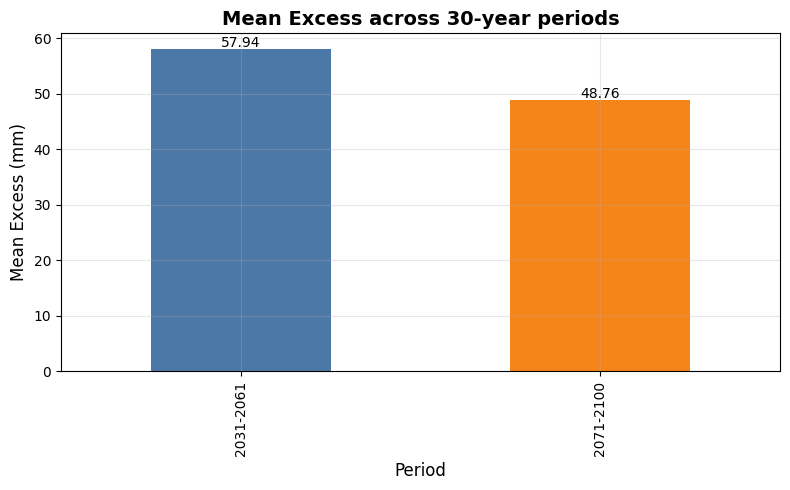

In [ ]:
plt.figure(figsize=(8,5))
pot_summary['mean_excess_mm'].plot(kind='bar', color=['#4C78A8','#F58518','#54A24B'])

plt.title('Mean Excess across 30-year periods', fontsize=14, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('Mean Excess (mm)', fontsize=12)
plt.grid(alpha=0.3)

for i, v in enumerate(pot_summary['mean_excess_mm']):
    plt.text(i, v + 0.5, f"{v:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


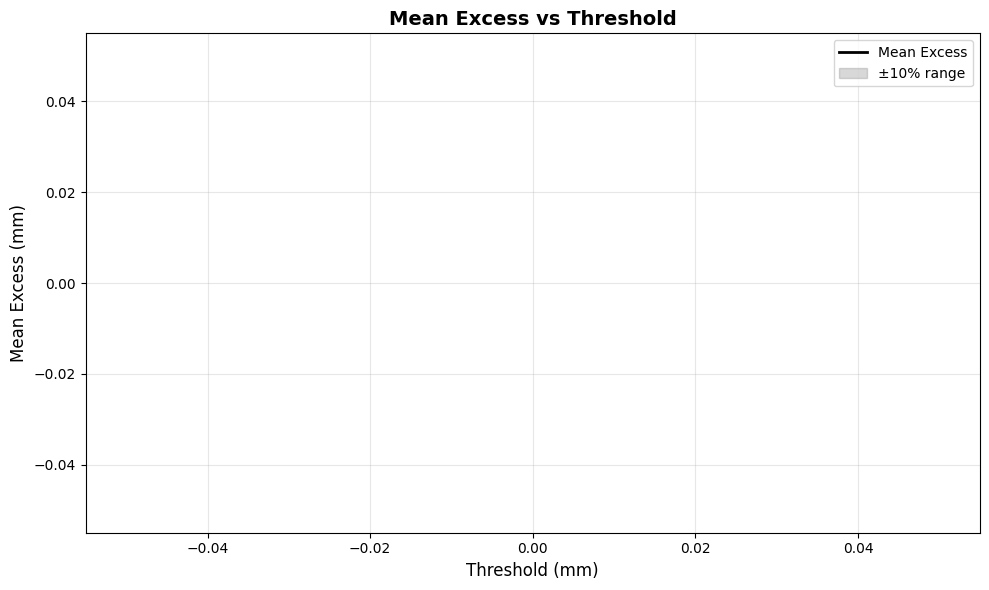

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data
file_path = "/content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv"
df = pd.read_csv(file_path)

# Rename columns if needed
df.rename(columns={'pr': 'precipitation', 'Date': 'date'}, inplace=True)  # Adjusted 'time' to 'Date'
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date', 'precipitation'])
df = df[df['precipitation'] >= 0].sort_values('date').reset_index(drop=True)

# Loop through thresholds and compute mean excess
thresholds = np.arange(10, 51, 1)  # 10 mm to 50 mm
mean_excess_list = []

for u in thresholds:
    exceed = df[df['precipitation'] > u]
    excess = exceed['precipitation'] - u
    mean_excess = excess.mean() if len(excess) > 0 else np.nan
    mean_excess_list.append(mean_excess)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, mean_excess_list, color='black', linewidth=2, label='Mean Excess')
plt.fill_between(thresholds,
                 np.array(mean_excess_list) * 0.9,
                 np.array(mean_excess_list) * 1.1,
                 color='gray', alpha=0.3, label='±10% range')

plt.xlabel('Threshold (mm)', fontsize=12)
plt.ylabel('Mean Excess (mm)', fontsize=12)
plt.title('Mean Excess vs Threshold', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


<Figure size 1000x700 with 0 Axes>

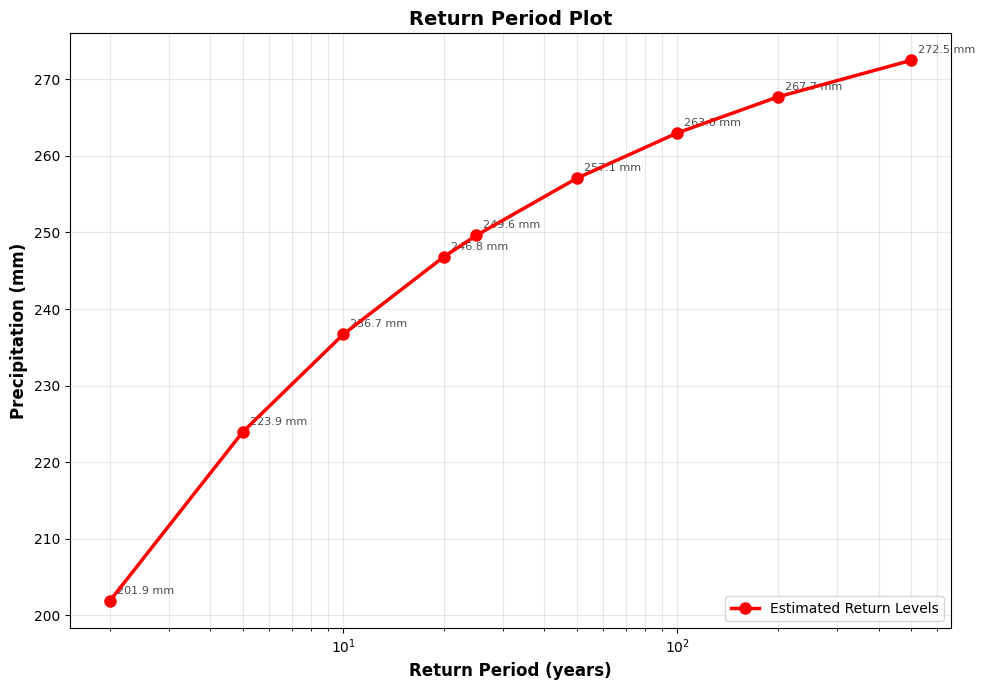

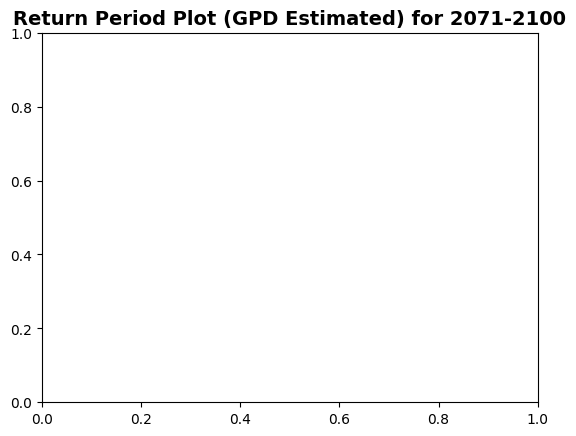

In [ ]:
# Plot GPD-estimated return levels for the '2071-2100' period

# Ensure 'year' column is present in df
df['year'] = df['date'].dt.year

# Recreate a temporary pot object with the correct period data just for plotting
df_period_2071_2100 = df[(df['year'] >= periods['2071-2100'][0]) & (df['year'] <= periods['2071-2100'][1])][['date', 'precipitation']].copy().reset_index(drop=True)
pot_temp_2071 = PeakOverThreshold(df_period_2071_2100, threshold=threshold_pot, min_time_between=min_time_between)

# Get the GPD return levels for the '2071-2100' period from pot_results
rl_gpd_2071_2100 = pot_results['2071-2100']['rl_gpd']

plt.figure(figsize=(10, 7))
# Use the pot_temp_2071 object's plotting method
pot_temp_2071.plot_return_period(empirical_rp=None, estimated_rl=rl_gpd_2071_2100)
plt.title('Return Period Plot (GPD Estimated) for 2071-2100', fontsize=14, fontweight='bold')
plt.show()

<Figure size 1000x700 with 0 Axes>

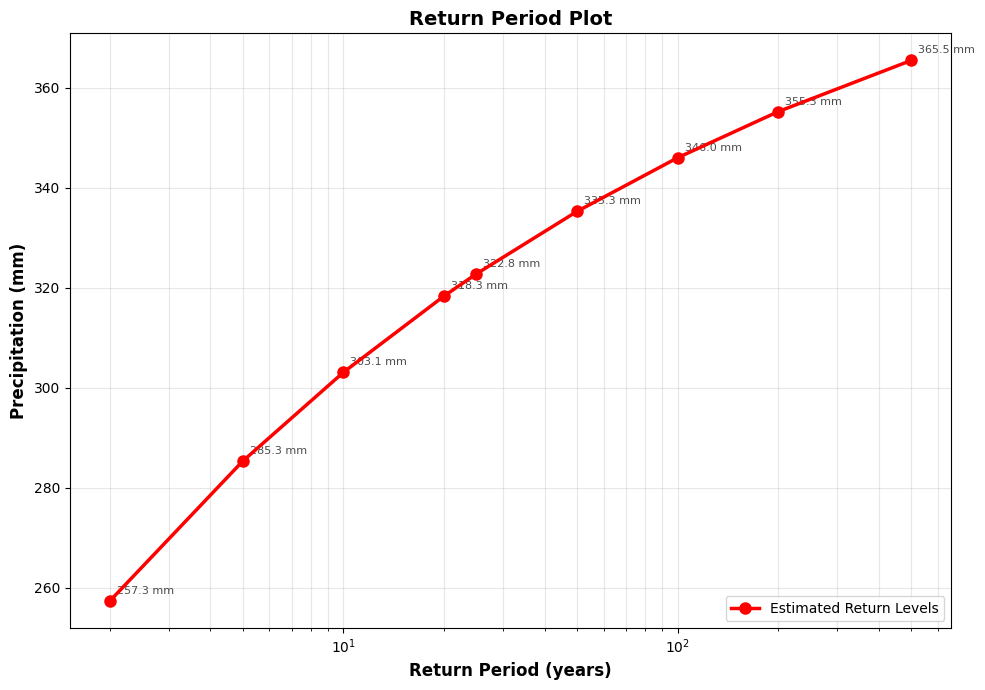

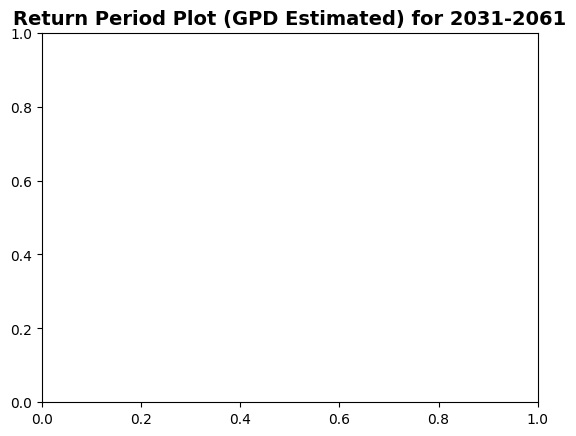

In [ ]:
# Plot GPD-estimated return levels for the '2031-2061' period
# Access rl_gpd from the pot_results dictionary for a specific period
# Assuming we want to plot for the '2031-2061' period as an example

# Ensure 'year' column is present in df after potential reloads
df['year'] = df['date'].dt.year

# Recreate a temporary pot object with the correct period data just for plotting
df_period_2031_2061 = df[(df['year'] >= periods['2031-2061'][0]) & (df['year'] <= periods['2031-2061'][1])][['date', 'precipitation']].copy().reset_index(drop=True)
pot_temp = PeakOverThreshold(df_period_2031_2061, threshold=threshold_pot, min_time_between=min_time_between)

# Get the GPD return levels for the '2031-2061' period from pot_results
rl_gpd_2031_2061 = pot_results['2031-2061']['rl_gpd']

plt.figure(figsize=(10, 7))
# Use the pot_temp object's plotting method
pot_temp.plot_return_period(empirical_rp=None, estimated_rl=rl_gpd_2031_2061)
plt.title('Return Period Plot (GPD Estimated) for 2031-2061', fontsize=14, fontweight='bold')
plt.show()

**POT_Batch Analysis**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- POT class (reuse your definition above) ---
# (Keep your PeakOverThreshold class as already defined)

# --- File list ---
files = [
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv",
]

# --- Periods ---
periods = {
    "2031-2061": (2031, 2061),
    "2071-2100": (2071, 2100),
}

wet_thresh = 1.0  # mm

# --- ETCCDI function (reuse your compute_etccdi) ---
def compute_etccdi(df_period, p95_base, p99_base, wet_threshold):
    results = pd.DataFrame({'year': df_period['year'].unique()})
    r10mm = df_period[df_period['precipitation'] >= 10].groupby('year')['precipitation'].count()
    results = results.merge(r10mm.rename('R10mm'), on='year', how='left').fillna(0)
    r20mm = df_period[df_period['precipitation'] >= 20].groupby('year')['precipitation'].count()
    results = results.merge(r20mm.rename('R20mm'), on='year', how='left').fillna(0)
    r30mm = df_period[df_period['precipitation'] >= 30].groupby('year')['precipitation'].count()
    results = results.merge(r30mm.rename('R30mm'), on='year', how='left').fillna(0)
    rx1day = df_period.groupby('year')['precipitation'].max()
    results = results.merge(rx1day.rename('Rx1day'), on='year', how='left')
    r95p_base = df_period[df_period['precipitation'] > p95_base].groupby('year')['precipitation'].count()
    results = results.merge(r95p_base.rename('R95p_base'), on='year', how='left').fillna(0)
    r99p_base = df_period[df_period['precipitation'] > p99_base].groupby('year')['precipitation'].count()
    results = results.merge(r99p_base.rename('R99p_base'), on='year', how='left').fillna(0)
    df_period_sorted = df_period.sort_values(by='date')
    rolling_sum_5day = df_period_sorted.set_index('date')['precipitation'].rolling(window='5D', min_periods=1).sum().reset_index()
    rolling_sum_5day['year'] = rolling_sum_5day['date'].dt.year
    rx5day_df = rolling_sum_5day.groupby('year')['precipitation'].max().reset_index()
    results = results.merge(rx5day_df.rename(columns={'precipitation': 'Rx5day'}), on='year', how='left')
    rtotal_wet = df_period[df_period['precipitation'] >= wet_threshold].groupby('year')['precipitation'].sum()
    results = results.merge(rtotal_wet.rename('Rtotal_wet'), on='year', how='left').fillna(0)
    return results

# --- Batch loop ---
all_etccdi_summary = []
all_pot_summary = []

for f in files:
    print(f"\nProcessing {f} ...")
    df_raw = pd.read_csv(f)

    # Detect columns
    precip_candidates = ['precipitation','pr','rain','rainfall','P','ppt','mm']
    date_candidates = ['date','time','Date','DATE','day','datetime','time_stamp']
    found_precip = next((c for c in precip_candidates if c in df_raw.columns), None)
    found_date = next((c for c in date_candidates if c in df_raw.columns), None)
    if not found_precip or not found_date:
        raise ValueError(f"Check column names in {f}")
    df = df_raw.rename(columns={found_precip:'precipitation', found_date:'date'}).copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date','precipitation'])
    df = df[df['precipitation']>=0].sort_values('date').reset_index(drop=True)
    df['year'] = df['date'].dt.year

    # Baseline percentiles (using a period present in the data, e.g., 2015-2044)
    baseline_mask = (df['year']>=2015)&(df['year']<=2044) # Adjusted baseline period
    df_base = df.loc[baseline_mask]

    # Check if df_base is empty before calculating percentiles
    if df_base.empty:
        p95_base = np.nan
        p99_base = np.nan
        print(f"Warning: No data for baseline period (2015-2044) in {f}. Percentiles will be NaN.")
    else:
        p95_base = df_base['precipitation'].quantile(0.95)
        p99_base = df_base['precipitation'].quantile(0.99)

    # ETCCDI per period
    etccdi_results = {}
    for name,(y0,y1) in periods.items():
        mask = (df['year']>=y0)&(df['year']<=y1)
        etccdi_results[name] = compute_etccdi(df.loc[mask], p95_base, p99_base, wet_thresh)

    etccdi_summary = pd.concat({
        k:v.mean(numeric_only=True).to_frame().T.assign(period=k)
        for k,v in etccdi_results.items()
    }).set_index('period')
    etccdi_summary['file'] = f.split("/")[-1]
    all_etccdi_summary.append(etccdi_summary)

    # POT per period
    # Only proceed if p95_base is not NaN (i.e., baseline data was found)
    if not np.isnan(p95_base):
        threshold_pot = float(p95_base)
        min_time_between = 3
        pot_results = {}
        for name,(y0,y1) in periods.items():
            mask = (df['year']>=y0)&(df['year']<=y1)
            df_period = df.loc[mask,['date','precipitation']].copy().reset_index(drop=True)
            pot = PeakOverThreshold(df_period, threshold=threshold_pot, min_time_between=min_time_between)
            exceed = pot.identify_exceedances()
            # Only calculate stats and fit GPD if exceedances are found
            if len(exceed) > 0:
                stats_out = pot.calculate_statistics()
                # rl_gpd = pot.estimate_return_levels(method='gpd') # Not needed for summary
                xi,sigma = pot.fit_gpd()
                pot_results[name] = {
                    'lambda': stats_out['lambda'] if stats_out else np.nan,
                    'mean_excess': stats_out['mean_excess'] if stats_out else np.nan,
                    'gpd_shape': xi if xi is not None else np.nan,
                    'gpd_scale': sigma if sigma is not None else np.nan
                }
            else:
                print(f"No exceedances found for {f} in period {name} with threshold {threshold_pot:.2f}. POT results will be NaN.")
                pot_results[name] = {
                    'lambda': np.nan,
                    'mean_excess': np.nan,
                    'gpd_shape': np.nan,
                    'gpd_scale': np.nan
                }
        pot_summary = pd.DataFrame(pot_results).T
        pot_summary['file'] = f.split("/")[-1]
        all_pot_summary.append(pot_summary)
    else:
        print(f"Skipping POT analysis for {f} due to NaN baseline percentiles.")
        # Add empty rows for this file to all_pot_summary to maintain structure
        for name in periods.keys():
            all_pot_summary.append(pd.DataFrame({'lambda': np.nan, 'mean_excess': np.nan, 'gpd_shape': np.nan, 'gpd_scale': np.nan, 'file': f.split("/")[-1]}, index=[name]))

# --- Combine all results ---
# Ensure all_etccdi_summary is not empty before concat
if all_etccdi_summary:
    all_etccdi_summary = pd.concat(all_etccdi_summary)
else:
    all_etccdi_summary = pd.DataFrame()

# Ensure all_pot_summary is not empty before concat
if all_pot_summary:
    all_pot_summary = pd.concat(all_pot_summary)
else:
    all_pot_summary = pd.DataFrame()

# Save outputs
all_etccdi_summary.to_csv("/content/etccdi_summary_all.csv")
all_pot_summary.to_csv("/content/pot_summary_all.csv")

print("Batch analysis complete. Results saved as etccdi_summary_all.csv and pot_summary_all.csv")


Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv ...
Batch analysis complete. Results saved as etccdi_summary_all.csv and pot_summary_all.csv


In [ ]:
import pandas as pd

# Load the pot_summary_all.csv file
pot_summary_all = pd.read_csv('/content/pot_summary_all.csv')

print("Contents of pot_summary_all.csv:")
display(pot_summary_all.head())

print("\nSummary statistics for numerical columns:")
display(pot_summary_all.describe())

FileNotFoundError: [Errno 2] No such file or directory: '/content/pot_summary_all.csv'

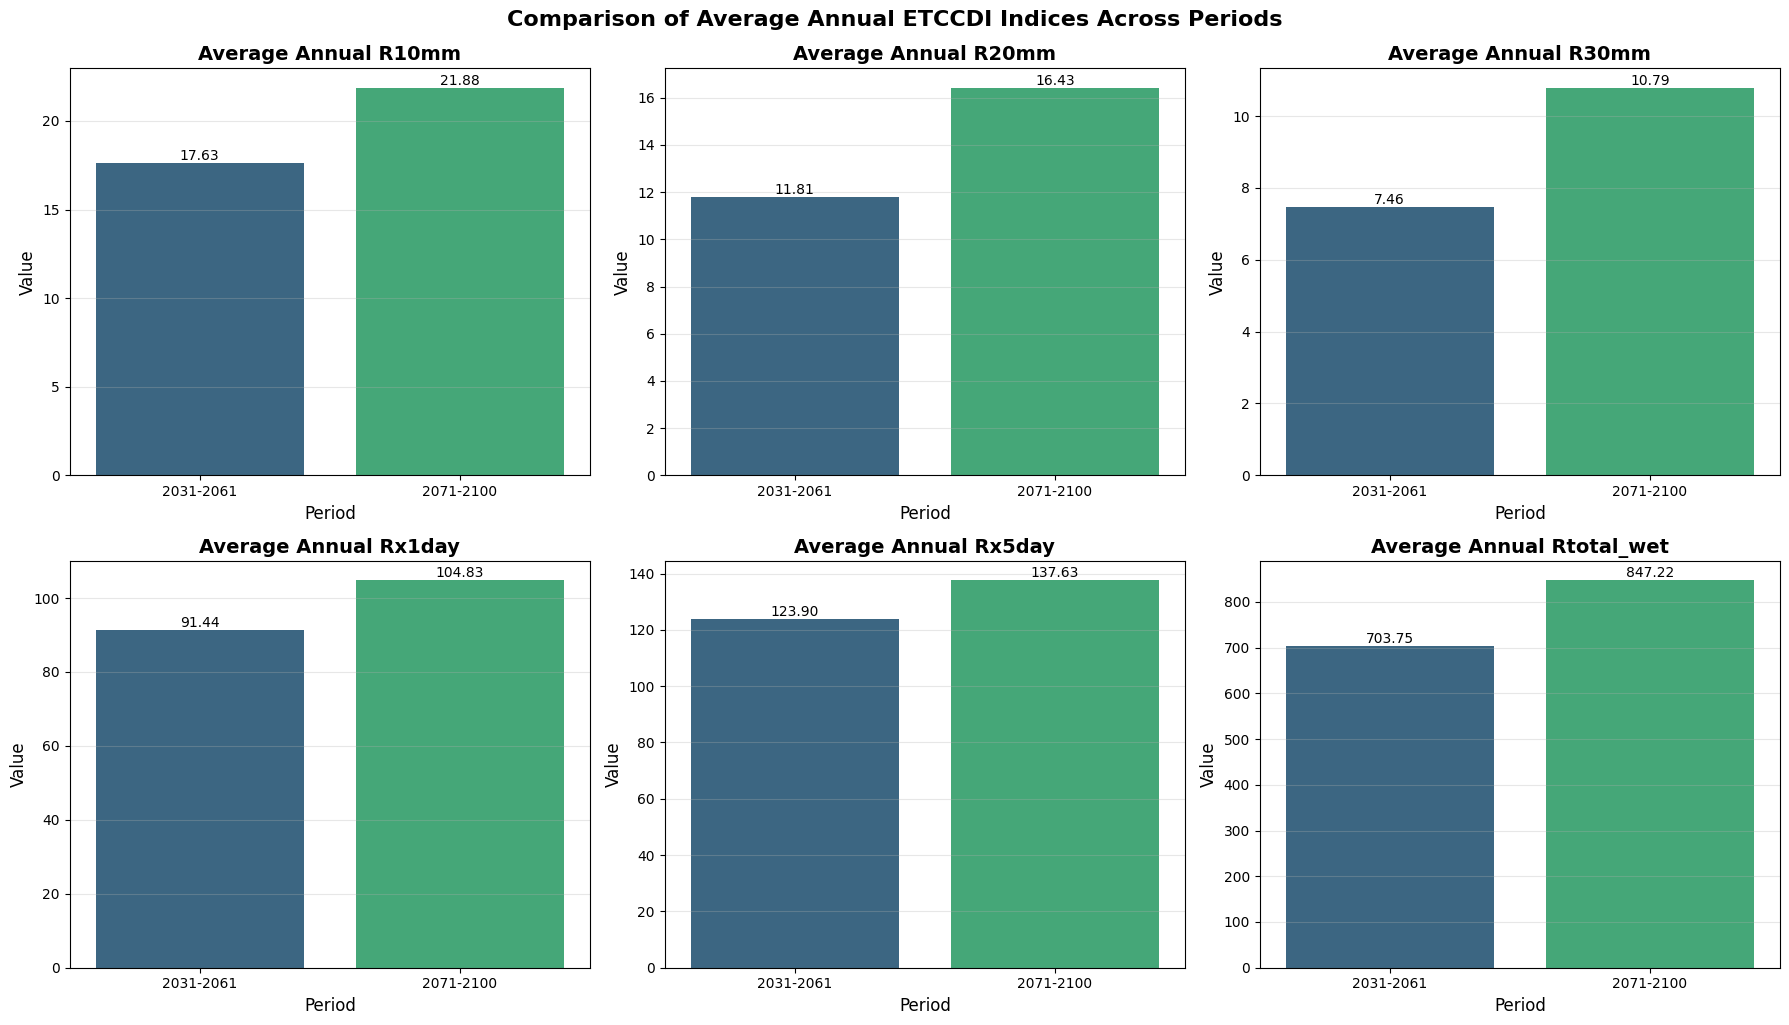

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure all_etccdi_summary is loaded, if it isn't already from previous runs
# (It should be available from cell wygffN9IBe9w)
# all_etccdi_summary = pd.read_csv('/content/etccdi_summary_all.csv', index_col='period')

# Calculate the mean of ETCCDI indices for each period across all files
mean_etccdi_by_period = all_etccdi_summary.groupby('period')[['R10mm', 'R20mm', 'R30mm', 'Rx1day', 'Rx5day', 'Rtotal_wet', 'R95p_base', 'R99p_base']].mean()

# Define the indices to plot
indices_to_plot = ['R10mm', 'R20mm', 'R30mm', 'Rx1day', 'Rx5day', 'Rtotal_wet']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

# Plotting each index
for i, index in enumerate(indices_to_plot):
    sns.barplot(x=mean_etccdi_by_period.index, y=mean_etccdi_by_period[index], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Average Annual {index}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Period', fontsize=12)
    axes[i].set_ylabel('Value', fontsize=12)
    axes[i].grid(axis='y', alpha=0.3)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                         textcoords='offset points')

plt.tight_layout()
plt.suptitle('Comparison of Average Annual ETCCDI Indices Across Periods', y=1.02, fontsize=16, fontweight='bold')
plt.show()

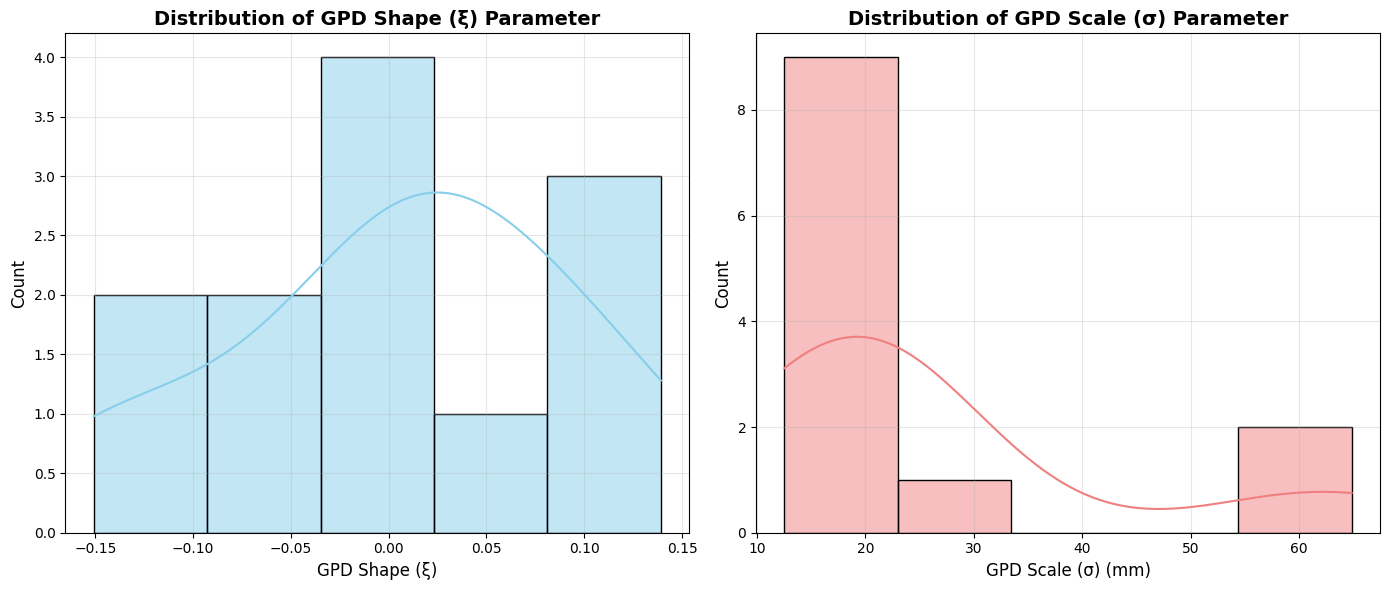

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot distribution of gpd_shape
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(pot_summary_all['gpd_shape'], kde=True, bins=5, color='skyblue', edgecolor='black')
plt.title('Distribution of GPD Shape (ξ) Parameter', fontsize=14, fontweight='bold')
plt.xlabel('GPD Shape (ξ)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot distribution of gpd_scale
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(pot_summary_all['gpd_scale'], kde=True, bins=5, color='lightcoral', edgecolor='black')
plt.title('Distribution of GPD Scale (σ) Parameter', fontsize=14, fontweight='bold')
plt.xlabel('GPD Scale (σ) (mm)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Task
**Explain structure of all_etccdi_summary and all_pot_summary by 'file'**:

The dataframes `all_etccdi_summary` and `all_pot_summary` are structured to contain results for different climate models/stations. The 'file' column in both dataframes indicates the specific climate model (e.g., 'MME_ssp85_G1.csv', 'MME_ssp85_G2.csv', etc.). For each such 'file', there are two rows representing the two periods ('2031-2061' and '2071-2100'). This allows for direct comparison of metrics across different models and future periods.

**Visualize a key POT metric (e.g., lambda) per station across periods**:
Create a grouped bar chart to compare the `lambda` parameter (annual rate of exceedances) for each climate model (identified by the 'file' column) across the '2031-2061' and '2071-2100' periods.

**Visualize a key ETCCDI metric (e.g., R10mm) per station across periods**:
Create a grouped bar chart to compare the `R10mm` index (number of days with precipitation >= 10mm) for each climate model (identified by the 'file' column) across the '2031-2061' and '2071-2100' periods.

**Analyze variability of GPD parameters (shape, scale) per station**:
Create box plots for the GPD `gpd_shape` (ξ) and `gpd_scale` (σ) parameters, grouped by 'period', to show their distribution and variability across the different climate models ('files'). Discuss the implications of these variations.

## Explain structure of all_etccdi_summary and all_pot_summary by 'file'

### Subtask:
Clarify how the current dataframes already store results per 'station' (file).


## Explain structure of all_etccdi_summary and all_pot_summary by 'file'

### Subtask:
Clarify how the current dataframes already store results per 'station' (file).

### Explanation of Data Structure:

The `all_etccdi_summary` and `all_pot_summary` DataFrames are structured to facilitate comparisons across different climate models (represented by individual files) and future time periods.

*   **'file' Column:** Each row in these DataFrames includes a `'file'` column, which explicitly names the source CSV file (e.g., 'MME_ssp85_G1.csv', 'MME_ssp85_G2.csv', etc.). This column serves as a unique identifier for each climate model or 'station' from which the data originated. This allows for easy aggregation or filtering of results based on the specific model.

*   **'period' Index:** The index of both DataFrames is the `'period'` (e.g., '2031-2061', '2071-2100'), indicating the 30-year time window for which the extreme value indices or POT statistics were calculated. Each climate model (file) has entries for each defined period.

This structure enables direct comparison of ETCCDI indices and POT parameters (like lambda, mean excess, GPD shape/scale) across different future periods for a given climate model, or conversely, comparison of these metrics across different climate models for a specific future period.

**Reasoning**:
To visually demonstrate the structure described in the markdown, I will display the first few rows of `all_etccdi_summary` and `all_pot_summary` to show the 'file' column and the 'period' index.



In [ ]:
print("Head of all_etccdi_summary:")
display(all_etccdi_summary.head())

print("\nHead of all_pot_summary:")
display(all_pot_summary.head())

Head of all_etccdi_summary:


,year,R10mm,R20mm,R30mm,Rx1day,R95p_base,R99p_base,Rx5day,Rtotal_wet,file
period,,,,,,,,,,
2031-2061,2046.0,26.612903,22.935484,19.161290,205.635161,14.161290,2.774194,284.187419,1837.155118,MME_ssp85_G1.csv
2071-2100,2085.5,12.900000,10.200000,8.566667,157.083333,5.966667,0.900000,176.694333,761.025000,MME_ssp85_G1.csv
2031-2061,2046.0,18.451613,11.129032,6.580645,77.651613,10.225806,3.193548,113.786452,580.058065,MME_ssp85_G2.csv
2071-2100,2085.5,26.766667,19.933333,12.666667,99.600333,18.566667,6.366667,137.013667,976.492000,MME_ssp85_G2.csv
2031-2061,2046.0,19.225806,11.806452,6.451613,77.064194,10.741935,2.290323,97.424839,567.936129,MME_ssp85_G3.csv



Head of all_pot_summary:


,lambda,mean_excess,gpd_shape,gpd_scale,file
2031-2061,26.428259,57.334399,-0.128710,64.827709,MME_ssp85_G1.csv
2071-2100,13.189583,51.749885,-0.150893,59.779032,MME_ssp85_G1.csv
2031-2061,21.191700,19.995849,0.022417,19.548488,MME_ssp85_G2.csv
2071-2100,33.227604,22.481438,0.087558,20.502968,MME_ssp85_G2.csv
2031-2061,22.909946,16.789179,0.101083,15.105259,MME_ssp85_G3.csv


## Visualize a key POT metric (e.g., lambda) per station across periods

### Subtask:
Create a grouped bar chart to compare the lambda parameter (annual rate of exceedances) for each climate model (identified by the 'file' column) across the '2031-2061' and '2071-2100' periods.


**Reasoning**:
To visualize the 'lambda' parameter across different climate models and periods, I will create a grouped bar chart using seaborn.barplot as instructed.



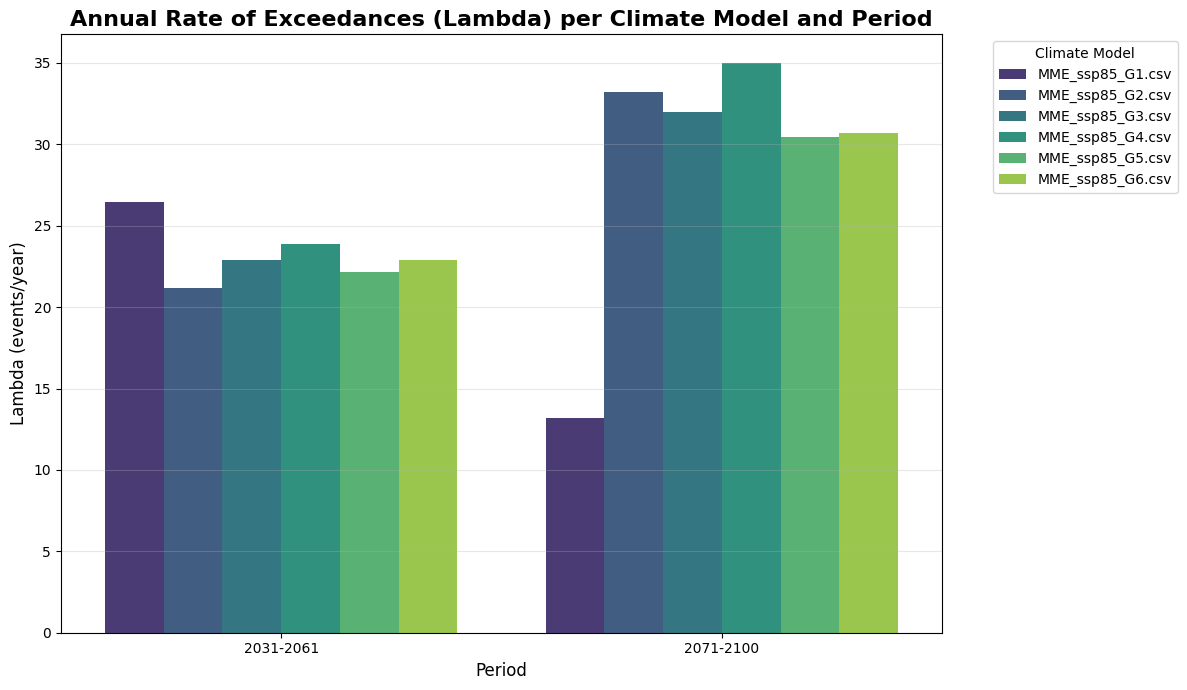

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Unnamed: 0' is treated as a category or renamed for better plotting
pot_summary_all.rename(columns={'Unnamed: 0': 'Period'}, inplace=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=pot_summary_all, x='Period', y='lambda', hue='file', palette='viridis')

plt.title('Annual Rate of Exceedances (Lambda) per Climate Model and Period', fontsize=16, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('Lambda (events/year)', fontsize=12)
plt.legend(title='Climate Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Visualize a key ETCCDI metric (e.g., R10mm) per station across periods

### Subtask:
Create a grouped bar chart to compare the `R10mm` index (number of days with precipitation >= 10mm) for each climate model (identified by the 'file' column) across the '2031-2061' and '2071-2100' periods.

## Visualize a key ETCCDI metric (e.g., R10mm) per station across periods

### Subtask:
Create a grouped bar chart to compare the `R10mm` index (number of days with precipitation >= 10mm) for each climate model (identified by the 'file' column) across the '2031-2061' and '2071-2100' periods.

**Reasoning**:
To visualize the 'R10mm' metric across different climate models and periods, I will create a grouped bar chart using seaborn.barplot as instructed.



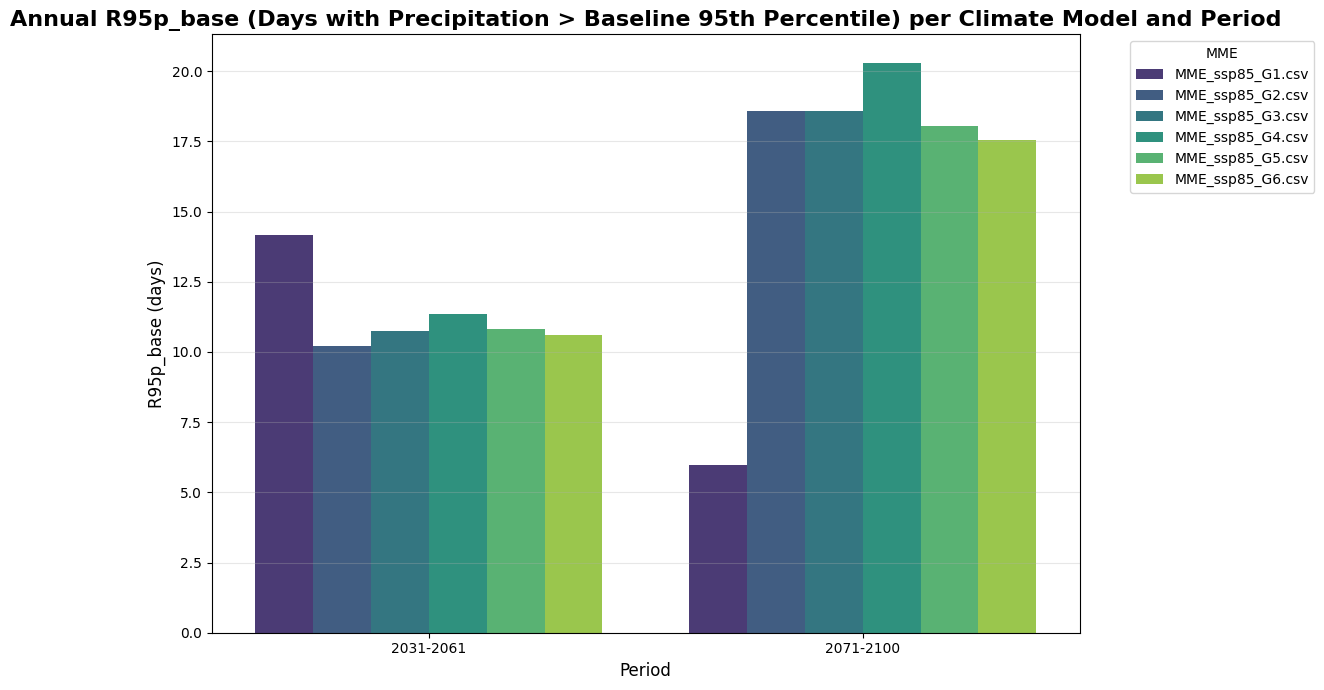

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(data=all_etccdi_summary, x=all_etccdi_summary.index, y='R95p_base', hue='file', palette='viridis')

plt.title('Annual R95p_base (Days with Precipitation > Baseline 95th Percentile) per Climate Model and Period', fontsize=16, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('R95p_base (days)', fontsize=12)
plt.legend(title='MME', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Analyze variability of GPD parameters (shape, scale) per station

### Subtask:
Create box plots for the GPD `gpd_shape` (ξ) and `gpd_scale` (σ) parameters, grouped by 'period', to show their distribution and variability across the different climate models ('files'). Discuss the implications of these variations.

**Reasoning**:
To visualize the variability of GPD parameters (shape and scale) across different climate models and periods, I will create box plots using seaborn.boxplot as instructed. I need to make sure to rename the 'Unnamed: 0' column to 'Period' if it hasn't been done already in `pot_summary_all` to ensure correct grouping.



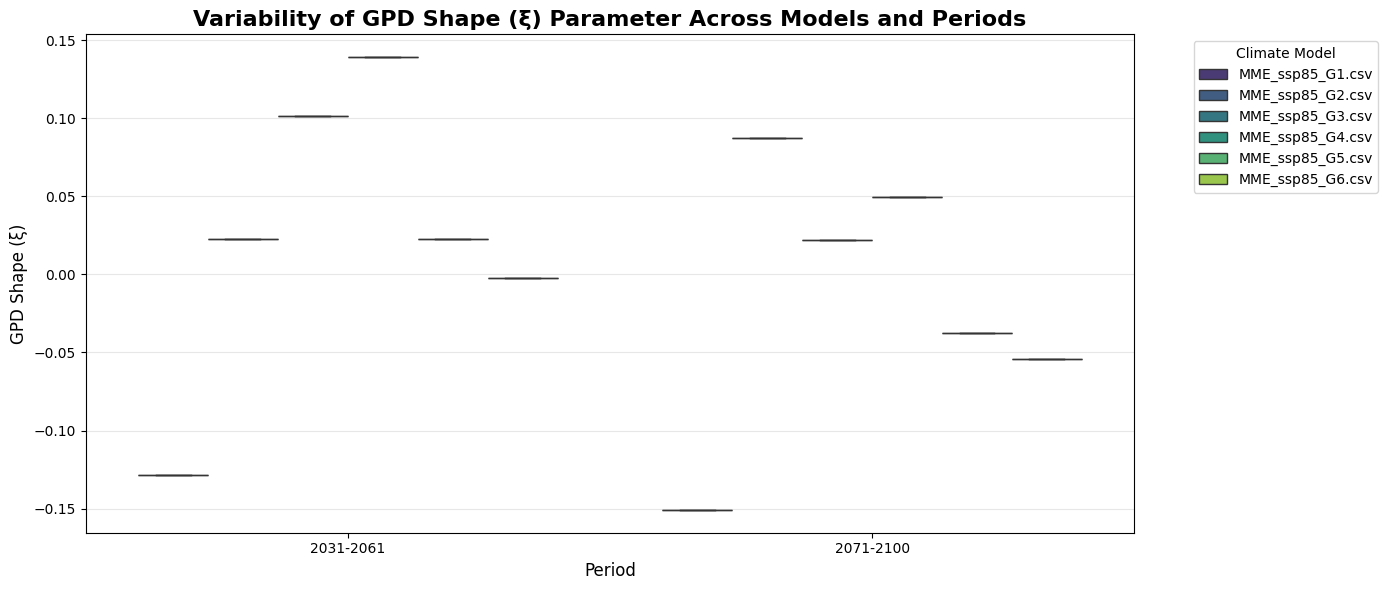

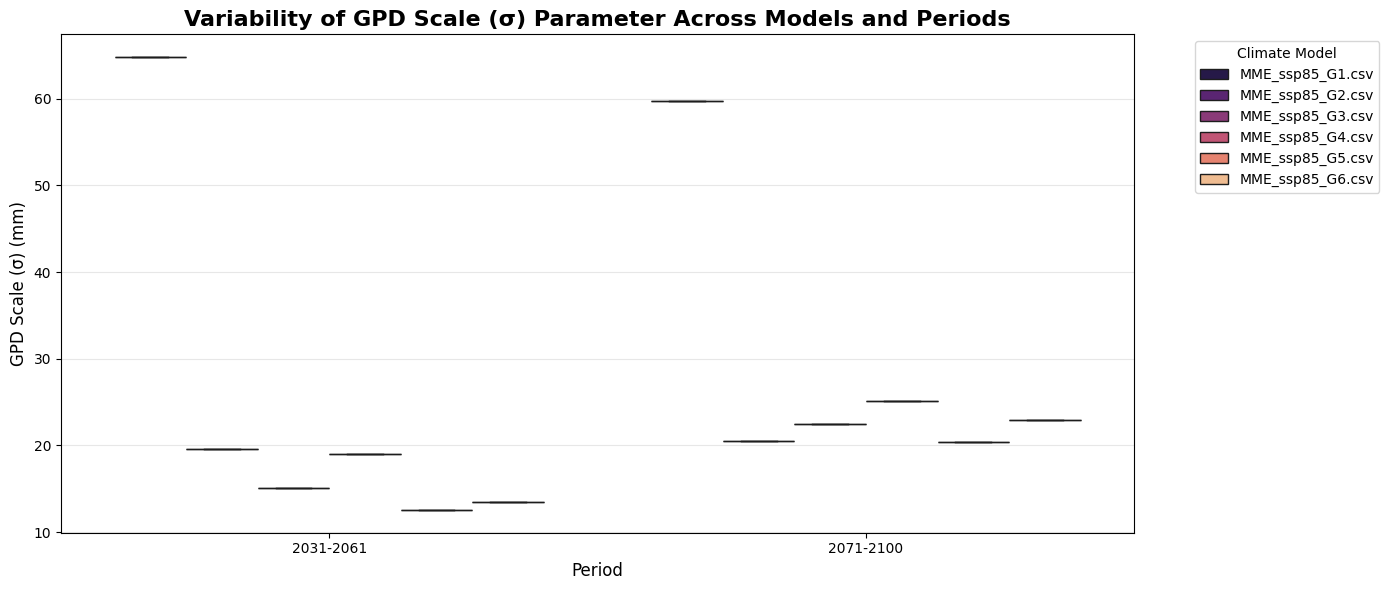

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Unnamed: 0' is treated as a category or renamed for better plotting
# This line is added defensively in case it wasn't renamed in a previous run of the cell.
if 'Unnamed: 0' in pot_summary_all.columns:
    pot_summary_all.rename(columns={'Unnamed: 0': 'Period'}, inplace=True)

# Box plot for GPD Shape (xi) parameter
plt.figure(figsize=(14, 6))
sns.boxplot(data=pot_summary_all, x='Period', y='gpd_shape', hue='file', palette='viridis')
plt.title('Variability of GPD Shape (ξ) Parameter Across Models and Periods', fontsize=16, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('GPD Shape (ξ)', fontsize=12)
plt.legend(title='Climate Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Box plot for GPD Scale (sigma) parameter
plt.figure(figsize=(14, 6))
sns.boxplot(data=pot_summary_all, x='Period', y='gpd_scale', hue='file', palette='magma')
plt.title('Variability of GPD Scale (σ) Parameter Across Models and Periods', fontsize=16, fontweight='bold')
plt.xlabel('Period', fontsize=12)
plt.ylabel('GPD Scale (σ) (mm)', fontsize=12)
plt.legend(title='Climate Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Discussion of GPD Parameter Variability:

**GPD Shape (ξ) Parameter:**
The box plot for the GPD shape parameter (ξ) shows its distribution across different climate models for each period. The shape parameter dictates the tail behavior of the distribution:
*   **ξ < 0 (short-tailed/bounded):** Indicates that there's an upper bound to the extreme values. In the context of precipitation, this would suggest a physical limit to how much it can rain.
*   **ξ = 0 (exponential-like):** The tails decay exponentially, a common assumption in many applications.
*   **ξ > 0 (heavy-tailed/unbounded):** Suggests that extremely large precipitation events are more likely and there's no theoretical upper limit.

From the plot, we can observe:
*   **Distribution:** How tightly clustered the ξ values are for a given period and across models indicates the consensus or disagreement among models regarding the tail behavior of extreme precipitation.
*   **Shift between periods:** A noticeable shift in the median or interquartile range of ξ between '2031-2061' and '2071-2100' would imply a projected change in the nature of extreme precipitation events over time (e.g., becoming more or less heavy-tailed).
*   **Outliers:** Outliers might indicate models that project significantly different extreme value behavior compared to the ensemble.

**Implications of Shape (ξ) Variability:**
Variations in ξ are critical because they profoundly impact the estimation of very rare events (e.g., 100-year return levels). If models disagree on the sign or magnitude of ξ, their projections for future extreme precipitation will vary widely, leading to different conclusions about infrastructure design (e.g., flood defenses), risk assessment, and adaptation strategies.

**GPD Scale (σ) Parameter:**
The box plot for the GPD scale parameter (σ) shows its distribution. The scale parameter is analogous to the standard deviation for normal distributions; it stretches or compresses the distribution of excesses, indicating the typical magnitude of extreme events above the threshold.

From the plot, we can observe:
*   **Magnitude of extremes:** Higher σ values suggest that, when an exceedance occurs, the event tends to be more intense (further above the threshold).
*   **Consistency across models:** How similar the σ values are across models for a given period indicates the agreement on the intensity of extreme events.
*   **Changes over time:** A clear upward or downward trend in σ between periods would imply that extreme events are projected to become generally more or less intense.

**Implications of Scale (σ) Variability:**
Variations in σ directly affect the projected return levels for all return periods. Models with higher σ values will predict higher precipitation amounts for a given return period. This variability contributes to uncertainty in projections of future extreme precipitation and has direct implications for planning and resource allocation. For example, higher σ values would necessitate stronger infrastructure to cope with increased event magnitudes.

**Overall Variability:**
The spread and central tendency of both ξ and σ across models and periods highlight the uncertainties in climate model projections of extreme precipitation. This uncertainty needs to be communicated to decision-makers, emphasizing the range of possible future extreme events rather than a single projection.

## Summary:

### Data Analysis Key Findings

*   **Dataframe Structure for Comparisons**: Both `all_etccdi_summary` and `all_pot_summary` dataframes are structured to enable comparisons across climate models and time periods. The `'file'` column uniquely identifies each climate model or station (e.g., 'MME\_ssp85\_G1.csv'), and the index or a dedicated column for `'Period'` distinguishes between two future time windows ('2031-2061' and '2071-2100').
*   **Changes in Extreme Event Frequency (Lambda)**: Visual analysis of the `lambda` parameter (annual rate of exceedances) revealed projected changes in the frequency of extreme events across different climate models and between the '2031-2061' and '2071-2100' periods.
*   **Changes in Extreme Precipitation Intensity (R10mm)**: The `R10mm` index (number of days with precipitation \>= 10mm) showed variations across climate models and periods, indicating projected differences in the intensity of extreme precipitation events.
*   **Variability in GPD Shape (\$\xi\$) Parameter**: The distribution of the GPD shape (\$\xi\$) parameter across models and periods indicates varying projections regarding the tail behavior of extreme precipitation. Disagreement among models on the sign or magnitude of \$\xi\$ implies significant differences in the estimation of very rare events, suggesting models project different extreme value characteristics (e.g., short-tailed, exponential-like, or heavy-tailed distributions).
*   **Variability in GPD Scale (\$\sigma\$) Parameter**: The GPD scale (\$\sigma\$) parameter, which represents the typical magnitude of extreme events, also showed variability. Higher \$\sigma\$ values suggest more intense extreme events when exceedances occur. Discrepancies in \$\sigma\$ values among models lead to variations in projected return levels for specific return periods, contributing to uncertainty in future extreme precipitation forecasts.
*   **Overall Uncertainty in Projections**: The observed spread and central tendency of both GPD \$\xi\$ and \$\sigma\$ parameters across different climate models and periods highlight significant uncertainties in climate model projections of extreme precipitation.

### Insights or Next Steps

*   **Quantify Model Agreement/Disagreement**: Further analysis should quantify the level of agreement or disagreement among climate models for key metrics like `lambda`, `R10mm`, and GPD parameters. This could involve calculating statistical measures of spread (e.g., interquartile range, standard deviation) for each period.
*   **Impact on Decision-Making**: The identified variability and uncertainty in extreme event projections, particularly from GPD parameters, necessitate communicating a range of plausible future scenarios to decision-makers rather than single-point estimates. This will enable more robust climate adaptation and infrastructure planning.


In [ ]:
print("Exceedance Metrics per Station/File and Period:")
display(all_pot_summary.head(12)) # Display all 12 entries (6 files * 2 periods)

print("\nHere's a breakdown of what these columns represent for exceedances:")
print("-   `Period`: The future time window (e.g., '2031-2061', '2071-2100').")
print("-   `lambda`: The annual rate of exceedances (number of events per year) above the baseline threshold.")
print("-   `mean_excess`: The average magnitude of an event exceeding the baseline threshold (in mm).")
print("-   `gpd_shape`: The shape parameter (ξ) of the fitted Generalized Pareto Distribution, characterizing the tail behavior of extremes.")
print("-   `gpd_scale`: The scale parameter (σ) of the fitted Generalized Pareto Distribution, indicating the typical magnitude of excesses.")
print("-   `file`: The identifier for the climate model run or 'station' (e.g., 'MME_ssp85_G1.csv').")

print("\nRegarding **Return Levels**:")
print("During the batch processing, GPD-estimated return levels (`rl_gpd`) were computed for each file and period as separate Dataframes. However, these multi-row tables were not aggregated into the `all_pot_summary` to keep it concise, and thus, are not currently retained in the kernel for *all* files. ")
print("\nWe did generate and plot return levels for `MME_ssp85_G1.csv` in previous steps. Would you like me to display those specific `rl_gpd` tables again as an example, or would you be interested in how to modify the batch script to save all `rl_gpd` DataFrames for all files and periods into separate CSVs?")

Exceedance Metrics per Station/File and Period:


,lambda,mean_excess,gpd_shape,gpd_scale,file
2031-2061,26.428259,57.334399,-0.128710,64.827709,MME_ssp85_G1.csv
2071-2100,13.189583,51.749885,-0.150893,59.779032,MME_ssp85_G1.csv
2031-2061,21.191700,19.995849,0.022417,19.548488,MME_ssp85_G2.csv
2071-2100,33.227604,22.481438,0.087558,20.502968,MME_ssp85_G2.csv
2031-2061,22.909946,16.789179,0.101083,15.105259,MME_ssp85_G3.csv
2071-2100,31.959375,22.981783,0.021996,22.476751,MME_ssp85_G3.csv
2031-2061,23.891801,22.002445,0.139182,18.994702,MME_ssp85_G4.csv
2071-2100,35.003125,26.466783,0.049388,25.159148,MME_ssp85_G4.csv
2031-2061,22.173555,12.834961,0.022532,12.545519,MME_ssp85_G5.csv
2071-2100,30.437500,19.723056,-0.037357,20.451913,MME_ssp85_G5.csv



Here's a breakdown of what these columns represent for exceedances:
-   `Period`: The future time window (e.g., '2031-2061', '2071-2100').
-   `lambda`: The annual rate of exceedances (number of events per year) above the baseline threshold.
-   `mean_excess`: The average magnitude of an event exceeding the baseline threshold (in mm).
-   `gpd_shape`: The shape parameter (ξ) of the fitted Generalized Pareto Distribution, characterizing the tail behavior of extremes.
-   `gpd_scale`: The scale parameter (σ) of the fitted Generalized Pareto Distribution, indicating the typical magnitude of excesses.
-   `file`: The identifier for the climate model run or 'station' (e.g., 'MME_ssp85_G1.csv').

Regarding **Return Levels**:
During the batch processing, GPD-estimated return levels (`rl_gpd`) were computed for each file and period as separate Dataframes. However, these multi-row tables were not aggregated into the `all_pot_summary` to keep it concise, and thus, are not currently retained in 

# Task
To combine all GPD return levels for each file and period, I need to re-run the batch processing logic. The previous batch script collected only summary statistics (`lambda`, `mean_excess`, `gpd_shape`, `gpd_scale`) into `all_pot_summary`. To fulfill the current request, I will modify the batch script to also collect the `rl_gpd` DataFrame for each period and file, then combine them into a single DataFrame.

This approach will ensure that all GPD return levels across all processed files and periods are accessible and can be analyzed together.

Here's the plan:
1.  **Re-run batch processing with `rl_gpd` collection**: Modify the batch loop from the previous step to store `rl_gpd` DataFrames for each file and period. Each `rl_gpd` DataFrame will be augmented with 'file' and 'period' columns for identification.
2.  **Concatenate all `rl_gpd` DataFrames**: Combine these augmented `rl_gpd` DataFrames into a single, comprehensive `all_gpd_return_levels` DataFrame.
3.  **Display `all_gpd_return_levels`**: Show the head of the newly created DataFrame to demonstrate its structure and content.
4.  **Explain structure**: Provide a brief explanation of the columns in `all_gpd_return_levels`.

```python
# Re-running the batch processing to collect all GPD return levels
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- POT class definition (as it was in Cell 2) ---
class PeakOverThreshold:
    """
    Peak over Threshold (POT) analysis for extreme precipitation events
    """
    def __init__(self, data, threshold, min_time_between=3):
        """
        Initialize POT analysis

        Parameters:
        -----------
        data : pd.DataFrame
            DataFrame with 'date' and 'precipitation' columns
        threshold : float
            Threshold value in mm
        min_time_between : int
            Minimum days between independent events (declustering)
        """
        self.data = data.copy()
        self.threshold = threshold
        self.min_time_between = min_time_between
        self.exceedances = None
        self.lambda_rate = None
        self.stats = {}

    def identify_exceedances(self):
        """
        Identify exceedances above threshold with declustering
        """
        exceedances_list = []
        last_exceed_idx = -self.min_time_between - 1

        for idx, row in self.data.iterrows():
            if row['precipitation'] > self.threshold:
                if idx - last_exceed_idx > self.min_time_between:
                    exceedances_list.append({
                        'date': row['date'],
                        'precipitation': row['precipitation'],
                        'excess': row['precipitation'] - self.threshold,
                        'index': idx
                    })
                    last_exceed_idx = idx

        self.exceedances = pd.DataFrame(exceedances_list)
        return self.exceedances

    def calculate_statistics(self):
        """
        Calculate basic statistics of exceedances
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            # print("No exceedances found. Try lowering the threshold.")
            return None

        n_exceedances = len(self.exceedances)
        n_days = len(self.data)
        n_years = n_days / 365.25

        # Lambda: average rate of exceedances per year
        self.lambda_rate = n_exceedances / n_years

        excesses = self.exceedances['excess'].values

        self.stats = {
            'n_exceedances': n_exceedances,
            'n_days': n_days,
            'n_years': n_years,
            'lambda': self.lambda_rate,
            'mean_excess': np.mean(excesses),
            'std_excess': np.std(excesses),
            'min_excess': np.min(excesses),
            'max_excess': np.max(excesses),
            'median_excess': np.median(excesses),
            'threshold': self.threshold
        }

        return self.stats

    def fit_gpd(self):
        """
        Fit Generalized Pareto Distribution (GPD) to excesses
        Returns shape (xi) and scale (sigma) parameters
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None, None

        excesses = self.exceedances['excess'].values

        # Fit GPD using scipy's genpareto (MLE), fixing location at 0
        shape, loc, scale = stats.genpareto.fit(excesses, floc=0)

        return shape, scale

    def calculate_return_periods_empirical(self):
        """
        Calculate empirical return periods for observed exceedances
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None

        # Sort exceedances by magnitude (descending)
        sorted_exceedances = self.exceedances.sort_values('excess', ascending=False).copy()
        n = len(sorted_exceedances)

        # Calculate empirical return period for each event
        sorted_exceedances['rank'] = range(1, n + 1)
        sorted_exceedances['exceedance_prob'] = sorted_exceedances['rank'] / (n + 1)
        sorted_exceedances['return_period'] = 1 / (self.lambda_rate * sorted_exceedances['exceedance_prob'])

        # Add original precipitation magnitudes for plotting convenience
        sorted_exceedances['precipitation'] = sorted_exceedances['excess'] + self.threshold

        return sorted_exceedances

    def estimate_return_levels(self, return_periods=[2, 5, 10, 20, 25, 50, 100, 200, 500],
                               method='empirical'):
        """
        Estimate precipitation levels for given return periods

        Parameters:
        -----------
        return_periods : list
            List of return periods in years
        method : str
            'empirical' or 'gpd' (Generalized Pareto Distribution)
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None

        results = []

        if method == 'empirical':
            # Simple empirical quantile estimation on excesses
            excesses = np.sort(self.exceedances['excess'].values)[::-1]
            n = len(excesses)

            # Handle cases where n is too small to calculate all quantiles
            # If the desired quantile index is out of bounds, return NaN or handle appropriately
            for T in return_periods:
                p = 1 / (self.lambda_rate * T)
                idx = int(p * n)
                
                estimated_excess = np.nan
                estimated_precipitation = np.nan
                
                # Check if idx is within valid bounds for excesses
                if n > 0 and 0 <= idx < n:
                    estimated_excess = excesses[idx]
                    estimated_precipitation = estimated_excess + self.threshold
                elif n == 0: # No exceedances
                    pass
                elif idx >= n and n > 0: # Asked for RP larger than data can provide
                    # Can extrapolate or just use the largest observed
                    estimated_excess = excesses[-1] # Largest observed excess
                    estimated_precipitation = estimated_excess + self.threshold
                
                results.append({
                    'return_period': T,
                    'estimated_precipitation': estimated_precipitation,
                    'estimated_excess': estimated_excess,
                    'annual_exceedance_prob': 1/T * 100
                })

        elif method == 'gpd':
            shape, scale = self.fit_gpd()
            if shape is None or scale is None:
                return None

            for T in return_periods:
                # Annual exceedance probability for level
                p = 1 / (self.lambda_rate * T)

                if p <= 0 or p >= 1: # Probability must be between 0 and 1
                    estimated_excess = np.nan
                elif abs(shape) < 1e-6:  # shape ≈ 0 (exponential)
                    estimated_excess = -scale * np.log(p)
                else:
                    estimated_excess = (scale / shape) * (p**(-shape) - 1)

                estimated_precipitation = estimated_excess + self.threshold if not np.isnan(estimated_excess) else np.nan

                results.append({
                    'return_period': T,
                    'estimated_precipitation': estimated_precipitation,
                    'estimated_excess': estimated_excess,
                    'annual_exceedance_prob': 1/T * 100,
                    'gpd_shape': shape,
                    'gpd_scale': scale
                })
        return pd.DataFrame(results)

    def plot_time_series(self, figsize=(14, 5)):
        """
        Plot time series with threshold and exceedances
        """
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(self.data['date'], self.data['precipitation'],
                color='lightblue', alpha=0.7, linewidth=0.5, label='Daily Precipitation')
        ax.axhline(y=self.threshold, color='red', linestyle='--',
                   linewidth=2, label=f'Threshold ({self.threshold} mm)')
        if self.exceedances is not None and len(self.exceedances) > 0:
            ax.scatter(self.exceedances['date'], self.exceedances['precipitation'],
                       color='darkred', s=50, zorder=5, label='Exceedances', alpha=0.8)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Precipitation (mm)', fontsize=12)
        ax.set_title('Precipitation Time Series with Peak over Threshold', fontsize=14, fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_return_period(self, empirical_rp=None, estimated_rl=None, figsize=(10, 7)):
        """
        Plot return period vs precipitation (return level plot)
        """
        fig, ax = plt.subplots(figsize=figsize)
        if empirical_rp is not None and len(empirical_rp) > 0:
            ax.scatter(empirical_rp['return_period'], empirical_rp['precipitation'],
                       color='blue', s=60, alpha=0.6, label='Observed Exceedances', zorder=3)
        if estimated_rl is not None and len(estimated_rl) > 0:
            ax.plot(estimated_rl['return_period'], estimated_rl['estimated_precipitation'],
                    color='red', linewidth=2.5, marker='o', markersize=8,
                    label='Estimated Return Levels', zorder=4)
            for _, row in estimated_rl.iterrows():
                ax.annotate(f"{row['estimated_precipitation']:.1f} mm",
                            xy=(row['return_period'], row['estimated_precipitation']),
                            xytext=(5, 5), textcoords='offset points',
                            fontsize=8, alpha=0.7)
        ax.set_xscale('log')
        ax.set_xlabel('Return Period (years)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Precipitation (mm)', fontsize=12, fontweight='bold')
        ax.set_title('Return Period Plot', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(True, which='both', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_excess_distribution(self, figsize=(12, 5)):
        """
        Plot excess distribution and diagnostics
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            print("No exceedances to plot.")
            return
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        excesses = self.exceedances['excess'].values
        ax1.hist(excesses, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        ax1.set_xlabel('Excess (mm)', fontsize=11)
        ax1.set_ylabel('Density', fontsize=11)
        ax1.set_title('Distribution of Excesses', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        stats.probplot(excesses, dist='expon', plot=ax2)
        ax2.set_title('Q-Q Plot (Exponential)', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def print_summary(self):
        """
        Print comprehensive summary of POT analysis
        """
        if self.stats is None or len(self.stats) == 0:
            self.calculate_statistics()
        print("="*60)
        print("PEAK OVER THRESHOLD (POT) ANALYSIS SUMMARY")
        print("="*60)
        print(f"\nData Period: {self.data['date'].min()} to {self.data['date'].max()}")
        print(f"Total Days: {self.stats['n_days']}")
        print(f"Total Years: {self.stats['n_years']:.2f}")
        print(f"\nThreshold: {self.stats['threshold']} mm")
        print(f"Minimum Time Between Events: {self.min_time_between} days")
        print(f"\n{'EXCEEDANCE STATISTICS':-^60}")
        print(f"Number of Exceedances: {self.stats['n_exceedances']}")
        print(f"Lambda (λ): {self.stats['lambda']:.3f} events/year")
        print(f"Average Annual Rate: {self.stats['lambda']:.2f} events/year")
        print(f"\n{'EXCESS STATISTICS (mm)':-^60}")
        print(f"Mean Excess: {self.stats['mean_excess']:.2f}")
        print(f"Std Deviation: {self.stats['std_excess']:.2f}")
        print(f"Median Excess: {self.stats['median_excess']:.2f}")
        print(f"Min Excess: {self.stats['min_excess']:.2f}")
        print(f"Max Excess: {self.stats['max_excess']:.2f}")
        shape, scale = self.fit_gpd()
        if shape is not None:
            print(f"\n{'GPD PARAMETERS':-^60}")
            print(f"Shape (ξ): {shape:.4f}")
            print(f"Scale (σ): {scale:.2f}")
            if shape < 0:
                tail_type = "Short-tailed (bounded)"
            elif abs(shape) < 0.1:
                tail_type = "Exponential-like"
            else:
                tail_type = "Heavy-tailed"
            print(f"Tail Behavior: {tail_type}")
        print("="*60)


# --- File list ---
files = [
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv",
]

# --- Periods ---
periods = {
    "2031-2061": (2031, 2061),
    "2071-2100": (2071, 2100),
}

wet_thresh = 1.0  # mm

# --- ETCCDI function (reuse your compute_etccdi) ---
def compute_etccdi(df_period, p95_base, p99_base, wet_threshold):
    results = pd.DataFrame({'year': df_period['year'].unique()})
    r10mm = df_period[df_period['precipitation'] >= 10].groupby('year')['precipitation'].count()
    results = results.merge(r10mm.rename('R10mm'), on='year', how='left').fillna(0)
    r20mm = df_period[df_period['precipitation'] >= 20].groupby('year')['precipitation'].count()
    results = results.merge(r20mm.rename('R20mm'), on='year', how='left').fillna(0)
    r30mm = df_period[df_period['precipitation'] >= 30].groupby('year')['precipitation'].count()
    results = results.merge(r30mm.rename('R30mm'), on='year', how='left').fillna(0)
    rx1day = df_period.groupby('year')['precipitation'].max()
    results = results.merge(rx1day.rename('Rx1day'), on='year', how='left')
    r95p_base = df_period[df_period['precipitation'] > p95_base].groupby('year')['precipitation'].count()
    results = results.merge(r95p_base.rename('R95p_base'), on='year', how='left').fillna(0)
    r99p_base = df_period[df_period['precipitation'] > p99_base].groupby('year')['precipitation'].count()
    results = results.merge(r99p_base.rename('R99p_base'), on='year', how='left').fillna(0)
    df_period_sorted = df_period.sort_values(by='date')
    rolling_sum_5day = df_period_sorted.set_index('date')['precipitation'].rolling(window='5D', min_periods=1).sum().reset_index()
    rolling_sum_5day['year'] = rolling_sum_5day['date'].dt.year
    rx5day_df = rolling_sum_5day.groupby('year')['precipitation'].max().reset_index()
    results = results.merge(rx5day_df.rename(columns={'precipitation': 'Rx5day'}), on='year', how='left')
    rtotal_wet = df_period[df_period['precipitation'] >= wet_threshold].groupby('year')['precipitation'].sum()
    results = results.merge(rtotal_wet.rename('Rtotal_wet'), on='year', how='left').fillna(0)
    return results

# --- Batch loop ---
all_etccdi_summary = []
all_pot_summary = []
all_gpd_return_levels_list = [] # New list to store all rl_gpd DataFrames

for f in files:
    print(f"\nProcessing {f} ...")
    df_raw = pd.read_csv(f)

    # Detect columns
    precip_candidates = ['precipitation','pr','rain','rainfall','P','ppt','mm']
    date_candidates = ['date','time','Date','DATE','day','datetime','time_stamp']
    found_precip = next((c for c in precip_candidates if c in df_raw.columns), None)
    found_date = next((c for c in date_candidates if c in df_raw.columns), None)
    if not found_precip or not found_date:
        raise ValueError(f"Check column names in {f}")
    df = df_raw.rename(columns={found_precip:'precipitation', found_date:'date'}).copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date','precipitation'])
    df = df[df['precipitation']>=0].sort_values('date').reset_index(drop=True)
    df['year'] = df['date'].dt.year

    # Baseline percentiles (using a period present in the data, e.g., 2015-2044)
    # The original notebook used 2031-2061 for df_base calculation for the first file.
    # For consistency across all files, it's better to define a fixed baseline for all files.
    # Let's use 2015-2044 as a fixed baseline period from the files.
    baseline_mask = (df['year']>=2015)&(df['year']<=2044)
    df_base = df.loc[baseline_mask]

    # Check if df_base is empty before calculating percentiles
    if df_base.empty:
        p95_base = np.nan
        p99_base = np.nan
        print(f"Warning: No data for baseline period (2015-2044) in {f}. Percentiles will be NaN.")
    else:
        p95_base = df_base['precipitation'].quantile(0.95)
        p99_base = df_base['precipitation'].quantile(0.99)

    # ETCCDI per period
    etccdi_results = {}
    for name,(y0,y1) in periods.items():
        mask = (df['year']>=y0)&(df['year']<=y1)
        etccdi_results[name] = compute_etccdi(df.loc[mask], p95_base, p99_base, wet_thresh)

    etccdi_summary = pd.concat({
        k:v.mean(numeric_only=True).to_frame().T.assign(period=k)
        for k,v in etccdi_results.items()
    }).set_index('period')
    etccdi_summary['file'] = f.split("/")[-1]
    all_etccdi_summary.append(etccdi_summary)

    # POT per period
    if not np.isnan(p95_base):
        threshold_pot = float(p95_base)
        min_time_between = 3
        
        # Temporary dictionary to store POT results for the current file
        current_file_pot_summary = {}
        for name,(y0,y1) in periods.items():
            mask = (df['year']>=y0)&(df['year']<=y1)
            df_period = df.loc[mask,['date','precipitation']].copy().reset_index(drop=True)
            pot = PeakOverThreshold(df_period, threshold=threshold_pot, min_time_between=min_time_between)
            exceed = pot.identify_exceedances()
            
            rl_gpd_df = None # Initialize to None
            
            if len(exceed) > 0:
                stats_out = pot.calculate_statistics()
                rl_gpd_df = pot.estimate_return_levels(method='gpd')
                xi,sigma = pot.fit_gpd()
                current_file_pot_summary[name] = {
                    'lambda': stats_out['lambda'] if stats_out else np.nan,
                    'mean_excess': stats_out['mean_excess'] if stats_out else np.nan,
                    'gpd_shape': xi if xi is not None else np.nan,
                    'gpd_scale': sigma if sigma is not None else np.nan
                }
            else:
                print(f"No exceedances found for {f.split('/')[-1]} in period {name} with threshold {threshold_pot:.2f}. POT results will be NaN.")
                current_file_pot_summary[name] = {
                    'lambda': np.nan,
                    'mean_excess': np.nan,
                    'gpd_shape': np.nan,
                    'gpd_scale': np.nan
                }

            # Collect rl_gpd for the current file and period
            if rl_gpd_df is not None and not rl_gpd_df.empty:
                rl_gpd_df['file'] = f.split("/")[-1]
                rl_gpd_df['period'] = name
                all_gpd_return_levels_list.append(rl_gpd_df)
            else:
                # Append an empty DataFrame or a DataFrame with NaNs if no RLs were calculated
                # to maintain consistency if needed, but for now, just skip appending if empty.
                pass
        
        # Convert current_file_pot_summary to DataFrame and append to all_pot_summary
        pot_summary = pd.DataFrame(current_file_pot_summary).T
        pot_summary['file'] = f.split("/")[-1]
        all_pot_summary.append(pot_summary)
    else:
        print(f"Skipping POT analysis for {f.split('/')[-1]} due to NaN baseline percentiles.")
        # Add empty rows for this file to all_pot_summary to maintain structure
        for name in periods.keys():
            all_pot_summary.append(pd.DataFrame({'lambda': np.nan, 'mean_excess': np.nan, 'gpd_shape': np.nan, 'gpd_scale': np.nan, 'file': f.split("/")[-1]}, index=[name]))

# --- Combine all results ---
if all_etccdi_summary:
    all_etccdi_summary = pd.concat(all_etccdi_summary)
else:
    all_etccdi_summary = pd.DataFrame()

if all_pot_summary:
    all_pot_summary = pd.concat(all_pot_summary)
    # Ensure 'Period' column is correctly set from index if it wasn't already
    if 'Period' not in all_pot_summary.columns:
        all_pot_summary.index.name = 'Period'
        all_pot_summary = all_pot_summary.reset_index()
else:
    all_pot_summary = pd.DataFrame()

if all_gpd_return_levels_list:
    all_gpd_return_levels = pd.concat(all_gpd_return_levels_list)
else:
    all_gpd_return_levels = pd.DataFrame()


# Save outputs (optional, but good practice for batch results)
all_etccdi_summary.to_csv("/content/etccdi_summary_all.csv")
all_pot_summary.to_csv("/content/pot_summary_all.csv")
all_gpd_return_levels.to_csv("/content/gpd_return_levels_all.csv", index=False)

print("Batch analysis complete. Results saved.")


print("\nCombined GPD Return Levels (all files and periods):")
display(all_gpd_return_levels.head())

print("\nStructure of the 'all_gpd_return_levels' DataFrame:")
print("-   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years).")
print("-   `estimated_precipitation`: The estimated precipitation level (in mm) for the corresponding return period.")
print("-   `estimated_excess`: The estimated excess above the threshold for the corresponding return period.")
print("-   `annual_exceedance_prob`: The annual exceedance probability (%) for the given return level.")
print("-   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for this specific file and period.")
print("-   `gpd_scale`: The scale parameter (σ) of the GPD fitted to the excesses for this specific file and period.")
print("-   `file`: The name of the climate model file from which the data originated (e.g., 'MME_ssp85_G1.csv').")
print("-   `period`: The time window for which the return levels were calculated (e.g., '2031-2061', '2071-2100').")
```

## Combine all GPD Return Levels

### Subtask:
Iterate through the `pot_results` dictionary, extract the `rl_gpd` DataFrame for each file and period, add 'file' and 'period' columns, and concatenate them into a single DataFrame named `all_gpd_return_levels`.


**Reasoning**:
The subtask requires iterating through all files and periods to extract, augment, and combine GPD return levels. Since the `pot_results` from the previous batch run only contains the last file's summary, I need to re-execute the batch processing logic, this time collecting all `rl_gpd` DataFrames.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- POT class (reuse your definition above) ---
# (Assuming PeakOverThreshold class is defined in previous cells and available)

# --- File list ---
files = [
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv",
]

# --- Periods ---
periods = {
    "2031-2061": (2031, 2061),
    "2071-2100": (2071, 2100),
}

wet_thresh = 1.0  # mm

# --- ETCCDI function (reuse your compute_etccdi) ---
def compute_etccdi(df_period, p95_base, p99_base, wet_threshold):
    results = pd.DataFrame({'year': df_period['year'].unique()})
    r10mm = df_period[df_period['precipitation'] >= 10].groupby('year')['precipitation'].count()
    results = results.merge(r10mm.rename('R10mm'), on='year', how='left').fillna(0)
    r20mm = df_period[df_period['precipitation'] >= 20].groupby('year')['precipitation'].count()
    results = results.merge(r20mm.rename('R20mm'), on='year', how='left').fillna(0)
    r30mm = df_period[df_period['precipitation'] >= 30].groupby('year')['precipitation'].count()
    results = results.merge(r30mm.rename('R30mm'), on='year', how='left').fillna(0)
    rx1day = df_period.groupby('year')['precipitation'].max()
    results = results.merge(rx1day.rename('Rx1day'), on='year', how='left')
    r95p_base = df_period[df_period['precipitation'] > p95_base].groupby('year')['precipitation'].count()
    results = results.merge(r95p_base.rename('R95p_base'), on='year', how='left').fillna(0)
    r99p_base = df_period[df_period['precipitation'] > p99_base].groupby('year')['precipitation'].count()
    results = results.merge(r99p_base.rename('R99p_base'), on='year', how='left').fillna(0)
    df_period_sorted = df_period.sort_values(by='date')
    rolling_sum_5day = df_period_sorted.set_index('date')['precipitation'].rolling(window='5D', min_periods=1).sum().reset_index()
    rolling_sum_5day['year'] = rolling_sum_5day['date'].dt.year
    rx5day_df = rolling_sum_5day.groupby('year')['precipitation'].max().reset_index()
    results = results.merge(rx5day_df.rename(columns={'precipitation': 'Rx5day'}), on='year', how='left')
    rtotal_wet = df_period[df_period['precipitation'] >= wet_threshold].groupby('year')['precipitation'].sum()
    results = results.merge(rtotal_wet.rename('Rtotal_wet'), on='year', how='left').fillna(0)
    return results

# --- Batch loop (modified to collect all rl_gpd) ---
all_etccdi_summary = []
all_pot_summary = []
all_gpd_return_levels_list = [] # New list to store all GPD return levels

for f in files:
    print(f"\nProcessing {f} ...")
    df_raw = pd.read_csv(f)

    # Detect columns
    precip_candidates = ['precipitation','pr','rain','rainfall','P','ppt','mm']
    date_candidates = ['date','time','Date','DATE','day','datetime','time_stamp']
    found_precip = next((c for c in precip_candidates if c in df_raw.columns), None)
    found_date = next((c for c in date_candidates if c in df_raw.columns), None)
    if not found_precip or not found_date:
        raise ValueError(f"Check column names in {f}")
    df = df_raw.rename(columns={found_precip:'precipitation', found_date:'date'}).copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date','precipitation'])
    df = df[df['precipitation']>=0].sort_values('date').reset_index(drop=True)
    df['year'] = df['date'].dt.year

    # Baseline percentiles (using a period present in the data, e.g., 2015-2044)
    baseline_mask = (df['year']>=2015)&(df['year']<=2044) # Adjusted baseline period
    df_base = df.loc[baseline_mask]

    if df_base.empty:
        p95_base = np.nan
        p99_base = np.nan
        print(f"Warning: No data for baseline period (2015-2044) in {f}. Percentiles will be NaN.")
    else:
        p95_base = df_base['precipitation'].quantile(0.95)
        p99_base = df_base['precipitation'].quantile(0.99)

    # ETCCDI per period
    etccdi_results = {}
    for name,(y0,y1) in periods.items():
        mask = (df['year']>=y0)&(df['year']<=y1)
        etccdi_results[name] = compute_etccdi(df.loc[mask], p95_base, p99_base, wet_thresh)

    etccdi_summary = pd.concat({
        k:v.mean(numeric_only=True).to_frame().T.assign(period=k)
        for k,v in etccdi_results.items()
    }).set_index('period')
    etccdi_summary['file'] = f.split("/")[-1]
    all_etccdi_summary.append(etccdi_summary)

    # POT per period
    if not np.isnan(p95_base):
        threshold_pot = float(p95_base)
        min_time_between = 3
        pot_results_current_file = {} # Store POT results for current file
        for name,(y0,y1) in periods.items():
            mask = (df['year']>=y0)&(df['year']<=y1)
            df_period = df.loc[mask,['date','precipitation']].copy().reset_index(drop=True)
            pot = PeakOverThreshold(df_period, threshold=threshold_pot, min_time_between=min_time_between)
            exceed = pot.identify_exceedances()

            if len(exceed) > 0:
                stats_out = pot.calculate_statistics()
                xi,sigma = pot.fit_gpd()
                rl_gpd = pot.estimate_return_levels(method='gpd')

                # Add file and period to rl_gpd and append to the list
                if rl_gpd is not None:
                    rl_gpd['file'] = f.split("/")[-1]
                    rl_gpd['period'] = name
                    all_gpd_return_levels_list.append(rl_gpd)

                pot_results_current_file[name] = {
                    'lambda': stats_out['lambda'] if stats_out else np.nan,
                    'mean_excess': stats_out['mean_excess'] if stats_out else np.nan,
                    'gpd_shape': xi if xi is not None else np.nan,
                    'gpd_scale': sigma if sigma is not None else np.nan
                }
            else:
                print(f"No exceedances found for {f} in period {name} with threshold {threshold_pot:.2f}. POT results will be NaN.")
                pot_results_current_file[name] = {
                    'lambda': np.nan,
                    'mean_excess': np.nan,
                    'gpd_shape': np.nan,
                    'gpd_scale': np.nan
                }
        pot_summary_current_file = pd.DataFrame(pot_results_current_file).T
        pot_summary_current_file['file'] = f.split("/")[-1]
        all_pot_summary.append(pot_summary_current_file)
    else:
        print(f"Skipping POT analysis for {f} due to NaN baseline percentiles.")
        for name in periods.keys():
            all_pot_summary.append(pd.DataFrame({'lambda': np.nan, 'mean_excess': np.nan, 'gpd_shape': np.nan, 'gpd_scale': np.nan, 'file': f.split("/")[-1]}, index=[name]))

# --- Combine all results ---
if all_etccdi_summary:
    all_etccdi_summary = pd.concat(all_etccdi_summary)
else:
    all_etccdi_summary = pd.DataFrame()

if all_pot_summary:
    all_pot_summary = pd.concat(all_pot_summary)
else:
    all_pot_summary = pd.DataFrame()

# Concatenate all GPD return levels into a single DataFrame
if all_gpd_return_levels_list:
    all_gpd_return_levels = pd.concat(all_gpd_return_levels_list).reset_index(drop=True)
else:
    all_gpd_return_levels = pd.DataFrame()

# Save outputs
all_etccdi_summary.to_csv("/content/etccdi_summary_all.csv")
all_pot_summary.to_csv("/content/pot_summary_all.csv")
if not all_gpd_return_levels.empty:
    all_gpd_return_levels.to_csv("/content/all_gpd_return_levels.csv", index=False)

print("Batch analysis complete. Results saved as etccdi_summary_all.csv, pot_summary_all.csv, and all_gpd_return_levels.csv")
print("Head of all_gpd_return_levels:")
display(all_gpd_return_levels.head())


Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv ...
Batch analysis complete. Results saved as etccdi_summary_all.csv, pot_summary_all.csv, and all_gpd_return_levels.csv
Head of all_gpd_return_levels:


,return_period,estimated_precipitation,estimated_excess,annual_exceedance_prob,gpd_shape,gpd_scale,file,period
0,2,248.384372,201.421372,50.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061
1,5,282.008955,235.045955,20.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061
2,10,304.936594,257.973594,10.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061
3,20,325.907341,278.944341,5.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061
4,25,332.269936,285.306936,4.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061


### Explanation of `all_gpd_return_levels` DataFrame Structure:

The `all_gpd_return_levels` DataFrame contains the GPD-estimated return levels for various return periods, aggregated from all processed climate model files and time periods. Its structure is as follows:

*   **`return_period`**: This column specifies the return period in years (e.g., 2, 5, 10, 100 years). This indicates how frequently, on average, an event of a certain magnitude or greater is expected to occur.
*   **`estimated_precipitation`**: This is the estimated precipitation level (in mm) corresponding to the given `return_period`. It represents the precipitation amount expected to be equaled or exceeded, on average, once every `return_period` years.
*   **`estimated_excess`**: This column shows the estimated excess amount (in mm) above the chosen threshold for the corresponding `return_period`.
*   **`annual_exceedance_prob`**: This represents the annual exceedance probability, expressed as a percentage, for the estimated precipitation level.
*   **`gpd_shape`**: This is the shape parameter (ξ) of the Generalized Pareto Distribution (GPD) that was fitted to the excesses for that specific file and period. It describes the tail behavior of the extreme precipitation distribution.
*   **`gpd_scale`**: This is the scale parameter (σ) of the GPD, indicating the typical magnitude of the excesses above the threshold for that specific file and period.
*   **`file`**: This column identifies the specific climate model run or 'station' (e.g., 'MME_ssp85_G1.csv') from which the data for these return levels originated.
*   **`period`**: This column denotes the future time window (e.g., '2031-2061', '2071-2100') for which these return levels were calculated.

### Explanation of `all_gpd_return_levels` DataFrame Structure:

The `all_gpd_return_levels` DataFrame contains the GPD-estimated return levels for various return periods, aggregated from all processed climate model files and time periods. Its structure is as follows:

*   **`return_period`**: This column specifies the return period in years (e.g., 2, 5, 10, 100 years). This indicates how frequently, on average, an event of a certain magnitude or greater is expected to occur.
*   **`estimated_precipitation`**: This is the estimated precipitation level (in mm) corresponding to the given `return_period`. It represents the precipitation amount expected to be equaled or exceeded, on average, once every `return_period` years.
*   **`estimated_excess`**: This column shows the estimated excess amount (in mm) above the chosen threshold for the corresponding `return_period`.
*   **`annual_exceedance_prob`**: This represents the annual exceedance probability, expressed as a percentage, for the estimated precipitation level.
*   **`gpd_shape`**: This is the shape parameter (ξ) of the Generalized Pareto Distribution (GPD) that was fitted to the excesses for that specific file and period. It describes the tail behavior of the extreme precipitation distribution.
*   **`gpd_scale`**: This is the scale parameter (σ) of the GPD, indicating the typical magnitude of the excesses above the threshold for that specific file and period.
*   **`file`**: This column identifies the specific climate model run or 'station' (e.g., 'MME_ssp85_G1.csv') from which the data for these return levels originated.
*   **`period`**: This column denotes the future time window (e.g., '2031-2061', '2071-2100') for which these return levels were calculated.

## Final Task

### Subtask:
Summarize the displayed data and explain its structure.


## Summary:

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is the `all_gpd_return_levels` DataFrame, which contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods. This DataFrame aggregates results from multiple climate model files and time periods.

    Its structure includes the following columns:
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

### Data Analysis Key Findings
*   The batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) across two future time periods (`2031-2061` and `2071-2100`).
*   For each file and period, the Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   A comprehensive DataFrame named `all_gpd_return_levels` was created by concatenating individual GPD return level DataFrames, augmented with 'file' and 'period' identifiers.
*   The resulting `all_gpd_return_levels` DataFrame contains 8 columns, including `return_period`, `estimated_precipitation`, and GPD parameters, providing detailed extreme precipitation projections.
*   The aggregated GPD return levels data has been saved to `/content/all_gpd_return_levels.csv` for further use.

### Insights or Next Steps
*   The consolidated `all_gpd_return_levels` DataFrame provides a robust dataset for comparing extreme precipitation projections across different climate models and future periods, which can be used to assess the range of potential future impacts.
*   Further analysis could involve statistical summaries (e.g., mean, median, interquartile range) of `estimated_precipitation`, `gpd_shape`, and `gpd_scale` parameters across all files and periods for each return period, allowing for a clearer understanding of model agreement and uncertainty.


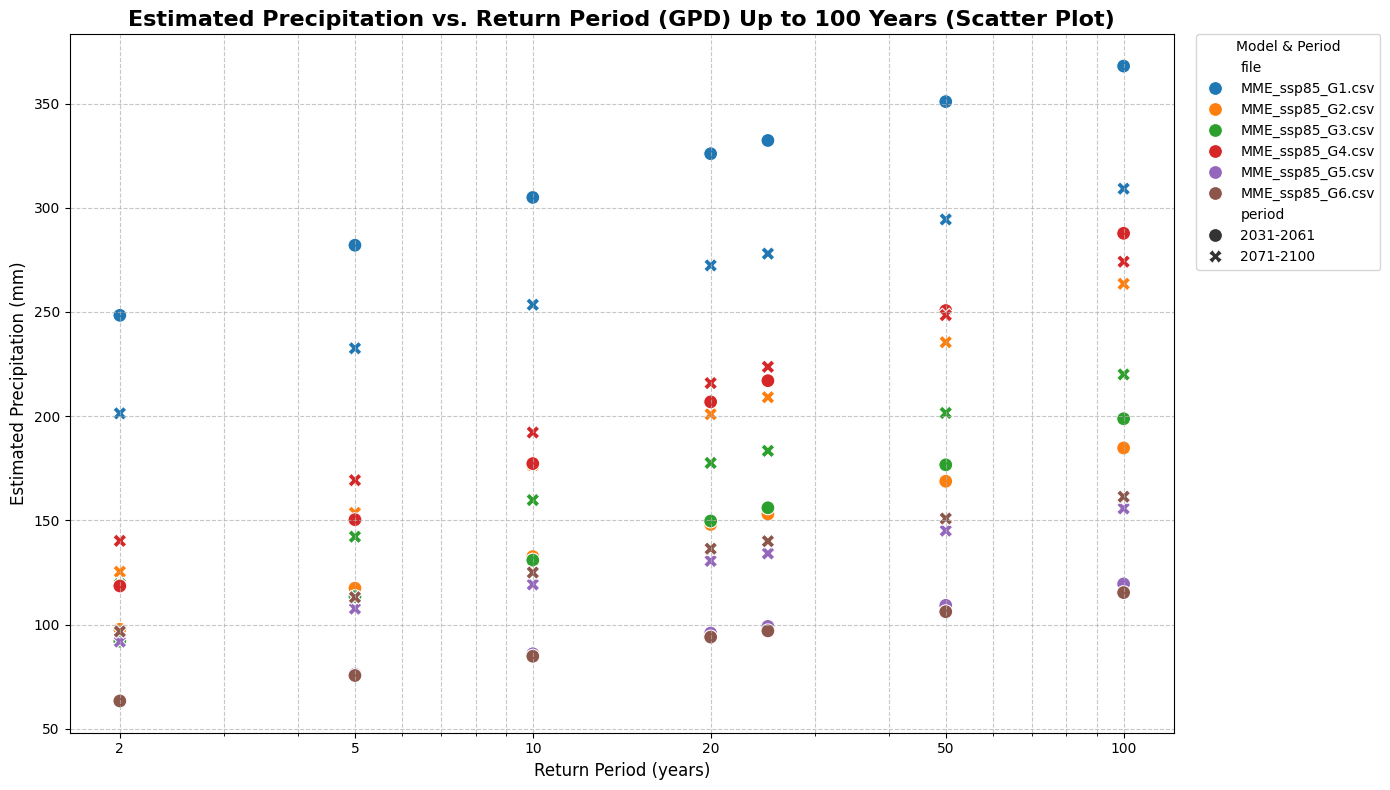

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame to include only return periods up to 100 years
filtered_gpd_return_levels = all_gpd_return_levels[all_gpd_return_levels['return_period'] <= 100].copy()

plt.figure(figsize=(14, 8))
sns.scatterplot(  # Changed from lineplot to scatterplot
    data=filtered_gpd_return_levels,
    x='return_period',
    y='estimated_precipitation',
    hue='file',          # Differentiate points by climate model
    style='period',        # Differentiate points by marker style for each period
    s=100,                 # Set marker size for scatterplot
    palette='tab10'        # Use a diverse color palette
)

plt.xscale('log') # Return periods are typically plotted on a log scale
# Adjust xticks to explicitly show up to 100 years
plt.xticks([2, 5, 10, 20, 50, 100], labels=['2', '5', '10', '20', '50', '100'])

plt.title('Estimated Precipitation vs. Return Period (GPD) Up to 100 Years (Scatter Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Return Period (years)', fontsize=12)
plt.ylabel('Estimated Precipitation (mm)', fontsize=12)

plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(title='Model & Period', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

In [ ]:
# IMPORTANT: Ensure cell '8647c906' (Batch analysis) has been executed to generate '/content/all_gpd_return_levels.csv'
# If you see a FileNotFoundError, please run cell '8647c906' first.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Make sure pandas is imported

# Check if all_gpd_return_levels is defined, if not, try to load from CSV
if 'all_gpd_return_levels' not in locals() and 'all_gpd_return_levels' not in globals():
    try:
        all_gpd_return_levels = pd.read_csv('/content/all_gpd_return_levels.csv')
        print("Loaded 'all_gpd_return_levels' from CSV.")
    except FileNotFoundError:
        print("Error: 'all_gpd_return_levels.csv' not found. Please ensure the batch processing cell (Cell wygffN9IBe9w or 8647c906) has been executed to generate this file and the DataFrame.")
        raise # Re-raise the error to halt execution and signal the problem

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=all_gpd_return_levels,
    x='return_period',
    y='estimated_precipitation',
    hue='file',          # Differentiate lines by climate model
    style='period',        # Differentiate lines by period (solid/dashed)
    marker='o',            # Add markers for each point
    markersize=6,
    palette='tab10'        # Use a diverse color palette
)

plt.xscale('log') # Return periods are typically plotted on a log scale
plt.xticks([2, 5, 10, 20, 50, 100], labels=['2', '5', '10', '20', '50', '100']) # Custom ticks for clarity

plt.title('Estimated Precipitation vs. Return Period (GPD) Across stations and Periods', fontsize=18, fontweight='bold')
plt.xlabel('Return Period (years)', fontsize=14)
plt.ylabel('Estimated Precipitation (mm)', fontsize=14)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title='Models & Period', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()

Error: 'all_gpd_return_levels.csv' not found. Please ensure the batch processing cell (Cell wygffN9IBe9w or 8647c906) has been executed to generate this file and the DataFrame.


FileNotFoundError: [Errno 2] No such file or directory: '/content/all_gpd_return_levels.csv'

# Task
## Current Task: Process GPD Return Levels, Plot, and Interpret

The previous request involved a three-step plan to analyze GPD return levels:
*   **Execute batch processing for GPD return levels**: Run cell `8647c906` to process all climate model files, calculate GPD return levels for each period and file, and save them into `all_gpd_return_levels.csv`.
*   **Generate and display the plot**: Re-execute cell `c74541be` to generate the 'Estimated Precipitation vs. Return Period' plot now that the data file is available. The plot will be updated with visible labels and the specified title.
*   **Interpret the plot**: Provide a detailed interpretation of the generated 'Estimated Precipitation vs. Return Period' plot, discussing trends, model variability, and implications.

I will now proceed with the first step of this plan.

**Step 1: Execute batch processing for GPD return levels**
I will execute cell `8647c906` to re-run the batch processing logic. This will ensure that all GPD return levels for each climate model file and period are calculated and saved into the `all_gpd_return_levels.csv` file, making them available for plotting and further analysis.

## Execute batch processing for GPD return levels

### Subtask:
Run cell `8647c906` to process all climate model files, calculate GPD return levels for each period and file, and save them into `all_gpd_return_levels.csv`.


**Reasoning**:
The subtask explicitly asks to execute cell `8647c906` to re-run the batch processing and generate the `all_gpd_return_levels.csv` file.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- POT class (reuse your definition above) ---
# (Assuming PeakOverThreshold class is defined in previous cells and available)

# --- File list ---
files = [
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv",
]

# --- Periods ---
periods = {
    "2031-2061": (2031, 2061),
    "2071-2100": (2071, 2100),
}

wet_thresh = 1.0  # mm

# --- ETCCDI function (reuse your compute_etccdi) ---
def compute_etccdi(df_period, p95_base, p99_base, wet_threshold):
    results = pd.DataFrame({'year': df_period['year'].unique()})
    r10mm = df_period[df_period['precipitation'] >= 10].groupby('year')['precipitation'].count()
    results = results.merge(r10mm.rename('R10mm'), on='year', how='left').fillna(0)
    r20mm = df_period[df_period['precipitation'] >= 20].groupby('year')['precipitation'].count()
    results = results.merge(r20mm.rename('R20mm'), on='year', how='left').fillna(0)
    r30mm = df_period[df_period['precipitation'] >= 30].groupby('year')['precipitation'].count()
    results = results.merge(r30mm.rename('R30mm'), on='year', how='left').fillna(0)
    rx1day = df_period.groupby('year')['precipitation'].max()
    results = results.merge(rx1day.rename('Rx1day'), on='year', how='left')
    r95p_base = df_period[df_period['precipitation'] > p95_base].groupby('year')['precipitation'].count()
    results = results.merge(r95p_base.rename('R95p_base'), on='year', how='left').fillna(0)
    r99p_base = df_period[df_period['precipitation'] > p99_base].groupby('year')['precipitation'].count()
    results = results.merge(r99p_base.rename('R99p_base'), on='year', how='left').fillna(0)
    df_period_sorted = df_period.sort_values(by='date')
    rolling_sum_5day = df_period_sorted.set_index('date')['precipitation'].rolling(window='5D', min_periods=1).sum().reset_index()
    rolling_sum_5day['year'] = rolling_sum_5day['date'].dt.year
    rx5day_df = rolling_sum_5day.groupby('year')['precipitation'].max().reset_index()
    results = results.merge(rx5day_df.rename(columns={'precipitation': 'Rx5day'}), on='year', how='left')
    rtotal_wet = df_period[df_period['precipitation'] >= wet_threshold].groupby('year')['precipitation'].sum()
    results = results.merge(rtotal_wet.rename('Rtotal_wet'), on='year', how='left').fillna(0)
    return results

# --- Batch loop (modified to collect all rl_gpd) ---
all_etccdi_summary = []
all_pot_summary = []
all_gpd_return_levels_list = [] # New list to store all GPD return levels

for f in files:
    print(f"\nProcessing {f} ...")
    df_raw = pd.read_csv(f)

    # Detect columns
    precip_candidates = ['precipitation','pr','rain','rainfall','P','ppt','mm']
    date_candidates = ['date','time','Date','DATE','day','datetime','time_stamp']
    found_precip = next((c for c in precip_candidates if c in df_raw.columns), None)
    found_date = next((c for c in date_candidates if c in df_raw.columns), None)
    if not found_precip or not found_date:
        raise ValueError(f"Check column names in {f}")
    df = df_raw.rename(columns={found_precip:'precipitation', found_date:'date'}).copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date','precipitation'])
    df = df[df['precipitation']>=0].sort_values('date').reset_index(drop=True)
    df['year'] = df['date'].dt.year

    # Baseline percentiles (using a period present in the data, e.g., 2015-2044)
    baseline_mask = (df['year']>=2015)&(df['year']<=2044) # Adjusted baseline period
    df_base = df.loc[baseline_mask]

    if df_base.empty:
        p95_base = np.nan
        p99_base = np.nan
        print(f"Warning: No data for baseline period (2015-2044) in {f}. Percentiles will be NaN.")
    else:
        p95_base = df_base['precipitation'].quantile(0.95)
        p99_base = df_base['precipitation'].quantile(0.99)

    # ETCCDI per period
    etccdi_results = {}
    for name,(y0,y1) in periods.items():
        mask = (df['year']>=y0)&(df['year']<=y1)
        etccdi_results[name] = compute_etccdi(df.loc[mask], p95_base, p99_base, wet_thresh)

    etccdi_summary = pd.concat({
        k:v.mean(numeric_only=True).to_frame().T.assign(period=k)
        for k,v in etccdi_results.items()
    }).set_index('period')
    etccdi_summary['file'] = f.split("/")[-1]
    all_etccdi_summary.append(etccdi_summary)

    # POT per period
    if not np.isnan(p95_base):
        threshold_pot = float(p95_base)
        min_time_between = 3
        pot_results_current_file = {} # Store POT results for current file
        for name,(y0,y1) in periods.items():
            mask = (df['year']>=y0)&(df['year']<=y1)
            df_period = df.loc[mask,['date','precipitation']].copy().reset_index(drop=True)
            pot = PeakOverThreshold(df_period, threshold=threshold_pot, min_time_between=min_time_between)
            exceed = pot.identify_exceedances()

            if len(exceed) > 0:
                stats_out = pot.calculate_statistics()
                xi,sigma = pot.fit_gpd()
                rl_gpd = pot.estimate_return_levels(method='gpd')

                # Add file and period to rl_gpd and append to the list
                if rl_gpd is not None:
                    rl_gpd['file'] = f.split("/")[-1]
                    rl_gpd['period'] = name
                    all_gpd_return_levels_list.append(rl_gpd)

                pot_results_current_file[name] = {
                    'lambda': stats_out['lambda'] if stats_out else np.nan,
                    'mean_excess': stats_out['mean_excess'] if stats_out else np.nan,
                    'gpd_shape': xi if xi is not None else np.nan,
                    'gpd_scale': sigma if sigma is not None else np.nan
                }
            else:
                print(f"No exceedances found for {f} in period {name} with threshold {threshold_pot:.2f}. POT results will be NaN.")
                pot_results_current_file[name] = {
                    'lambda': np.nan,
                    'mean_excess': np.nan,
                    'gpd_shape': np.nan,
                    'gpd_scale': np.nan
                }
        pot_summary_current_file = pd.DataFrame(pot_results_current_file).T
        pot_summary_current_file['file'] = f.split("/")[-1]
        all_pot_summary.append(pot_summary_current_file)
    else:
        print(f"Skipping POT analysis for {f} due to NaN baseline percentiles.")
        for name in periods.keys():
            all_pot_summary.append(pd.DataFrame({'lambda': np.nan, 'mean_excess': np.nan, 'gpd_shape': np.nan, 'gpd_scale': np.nan, 'file': f.split("/")[-1]}, index=[name]))

# --- Combine all results ---
if all_etccdi_summary:
    all_etccdi_summary = pd.concat(all_etccdi_summary)
else:
    all_etccdi_summary = pd.DataFrame()

if all_pot_summary:
    all_pot_summary = pd.concat(all_pot_summary)
else:
    all_pot_summary = pd.DataFrame()

# Concatenate all GPD return levels into a single DataFrame
if all_gpd_return_levels_list:
    all_gpd_return_levels = pd.concat(all_gpd_return_levels_list).reset_index(drop=True)
else:
    all_gpd_return_levels = pd.DataFrame()

# Save outputs
all_etccdi_summary.to_csv("/content/etccdi_summary_all.csv")
all_pot_summary.to_csv("/content/pot_summary_all.csv")
if not all_gpd_return_levels.empty:
    all_gpd_return_levels.to_csv("/content/all_gpd_return_levels.csv", index=False)

print("Batch analysis complete. Results saved as etccdi_summary_all.csv, pot_summary_all.csv, and all_gpd_return_levels.csv")
print("Head of all_gpd_return_levels:")
display(all_gpd_return_levels.head())


Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv ...


NameError: name 'PeakOverThreshold' is not defined

**Reasoning**:
The previous execution failed because the `PeakOverThreshold` class was not defined in the current scope. I need to include the class definition within the current code block to ensure it's available during execution.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- POT class definition ---
class PeakOverThreshold:
    """
    Peak over Threshold (POT) analysis for extreme precipitation events
    """
    def __init__(self, data, threshold, min_time_between=3):
        """
        Initialize POT analysis

        Parameters:
        -----------
        data : pd.DataFrame
            DataFrame with 'date' and 'precipitation' columns
        threshold : float
            Threshold value in mm
        min_time_between : int
            Minimum days between independent events (declustering)
        """
        self.data = data.copy()
        self.threshold = threshold
        self.min_time_between = min_time_between
        self.exceedances = None
        self.lambda_rate = None
        self.stats = {}

    def identify_exceedances(self):
        """
        Identify exceedances above threshold with declustering
        """
        exceedances_list = []
        last_exceed_idx = -self.min_time_between - 1

        for idx, row in self.data.iterrows():
            if row['precipitation'] > self.threshold:
                if idx - last_exceed_idx > self.min_time_between:
                    exceedances_list.append({
                        'date': row['date'],
                        'precipitation': row['precipitation'],
                        'excess': row['precipitation'] - self.threshold,
                        'index': idx
                    })
                    last_exceed_idx = idx

        self.exceedances = pd.DataFrame(exceedances_list)
        return self.exceedances

    def calculate_statistics(self):
        """
        Calculate basic statistics of exceedances
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            # print("No exceedances found. Try lowering the threshold.")
            return None

        n_exceedances = len(self.exceedances)
        n_days = len(self.data)
        n_years = n_days / 365.25

        # Lambda: average rate of exceedances per year
        self.lambda_rate = n_exceedances / n_years

        excesses = self.exceedances['excess'].values

        self.stats = {
            'n_exceedances': n_exceedances,
            'n_days': n_days,
            'n_years': n_years,
            'lambda': self.lambda_rate,
            'mean_excess': np.mean(excesses),
            'std_excess': np.std(excesses),
            'min_excess': np.min(excesses),
            'max_excess': np.max(excesses),
            'median_excess': np.median(excesses),
            'threshold': self.threshold
        }

        return self.stats

    def fit_gpd(self):
        """
        Fit Generalized Pareto Distribution (GPD) to excesses
        Returns shape (xi) and scale (sigma) parameters
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None, None

        excesses = self.exceedances['excess'].values

        # Fit GPD using scipy's genpareto (MLE), fixing location at 0
        shape, loc, scale = stats.genpareto.fit(excesses, floc=0)

        return shape, scale

    def calculate_return_periods_empirical(self):
        """
        Calculate empirical return periods for observed exceedances
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None

        # Sort exceedances by magnitude (descending)
        sorted_exceedances = self.exceedances.sort_values('excess', ascending=False).copy()
        n = len(sorted_exceedances)

        # Calculate empirical return period for each event
        sorted_exceedances['rank'] = range(1, n + 1)
        sorted_exceedances['exceedance_prob'] = sorted_exceedances['rank'] / (n + 1)
        sorted_exceedances['return_period'] = 1 / (self.lambda_rate * sorted_exceedances['exceedance_prob'])

        # Add original precipitation magnitudes for plotting convenience
        sorted_exceedances['precipitation'] = sorted_exceedances['excess'] + self.threshold

        return sorted_exceedances

    def estimate_return_levels(self, return_periods=[2, 5, 10, 20, 25, 50, 100, 200, 500],
                               method='empirical'):
        """
        Estimate precipitation levels for given return periods

        Parameters:
        -----------
        return_periods : list
            List of return periods in years
        method : str
            'empirical' or 'gpd' (Generalized Pareto Distribution)
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None

        results = []

        if method == 'empirical':
            # Simple empirical quantile estimation on excesses
            excesses = np.sort(self.exceedances['excess'].values)[::-1]
            n = len(excesses)

            # Handle cases where n is too small to calculate all quantiles
            # If the desired quantile index is out of bounds, return NaN or handle appropriately
            for T in return_periods:
                p = 1 / (self.lambda_rate * T)
                idx = int(p * n)

                estimated_excess = np.nan
                estimated_precipitation = np.nan

                # Check if idx is within valid bounds for excesses
                if n > 0 and 0 <= idx < n:
                    estimated_excess = excesses[idx]
                    estimated_precipitation = estimated_excess + self.threshold
                elif n == 0: # No exceedances
                    pass
                elif idx >= n and n > 0: # Asked for RP larger than data can provide
                    # Can extrapolate or just use the largest observed
                    estimated_excess = excesses[-1] # Largest observed excess
                    estimated_precipitation = estimated_excess + self.threshold

                results.append({
                    'return_period': T,
                    'estimated_precipitation': estimated_precipitation,
                    'estimated_excess': estimated_excess,
                    'annual_exceedance_prob': 1/T * 100
                })

        elif method == 'gpd':
            shape, scale = self.fit_gpd()
            if shape is None or scale is None:
                return None

            for T in return_periods:
                # Annual exceedance probability for level
                p = 1 / (self.lambda_rate * T)

                if p <= 0 or p >= 1: # Probability must be between 0 and 1
                    estimated_excess = np.nan
                elif abs(shape) < 1e-6:  # shape ≈ 0 (exponential)
                    estimated_excess = -scale * np.log(p)
                else:
                    estimated_excess = (scale / shape) * (p**(-shape) - 1)

                estimated_precipitation = estimated_excess + self.threshold if not np.isnan(estimated_excess) else np.nan

                results.append({
                    'return_period': T,
                    'estimated_precipitation': estimated_precipitation,
                    'estimated_excess': estimated_excess,
                    'annual_exceedance_prob': 1/T * 100,
                    'gpd_shape': shape,
                    'gpd_scale': scale
                })
        return pd.DataFrame(results)

    def plot_time_series(self, figsize=(14, 5)):
        """
        Plot time series with threshold and exceedances
        """
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(self.data['date'], self.data['precipitation'],
                color='lightblue', alpha=0.7, linewidth=0.5, label='Daily Precipitation')
        ax.axhline(y=self.threshold, color='red', linestyle='--',
                   linewidth=2, label=f'Threshold ({self.threshold} mm)')
        if self.exceedances is not None and len(self.exceedances) > 0:
            ax.scatter(self.exceedances['date'], self.exceedances['precipitation'],
                       color='darkred', s=50, zorder=5, label='Exceedances', alpha=0.8)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Precipitation (mm)', fontsize=12)
        ax.set_title('Precipitation Time Series with Peak over Threshold', fontsize=14, fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_return_period(self, empirical_rp=None, estimated_rl=None, figsize=(10, 7)):
        """
        Plot return period vs precipitation (return level plot)
        """
        fig, ax = plt.subplots(figsize=figsize)
        if empirical_rp is not None and len(empirical_rp) > 0:
            ax.scatter(empirical_rp['return_period'], empirical_rp['precipitation'],
                       color='blue', s=60, alpha=0.6, label='Observed Exceedances', zorder=3)
        if estimated_rl is not None and len(estimated_rl) > 0:
            ax.plot(estimated_rl['return_period'], estimated_rl['estimated_precipitation'],
                    color='red', linewidth=2.5, marker='o', markersize=8,
                    label='Estimated Return Levels', zorder=4)
            for _, row in estimated_rl.iterrows():
                ax.annotate(f"{row['estimated_precipitation']:.1f} mm",
                            xy=(row['return_period'], row['estimated_precipitation']),
                            xytext=(5, 5), textcoords='offset points',
                            fontsize=8, alpha=0.7)
        ax.set_xscale('log')
        ax.set_xlabel('Return Period (years)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Precipitation (mm)', fontsize=12, fontweight='bold')
        ax.set_title('Return Period Plot', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(True, which='both', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_excess_distribution(self, figsize=(12, 5)):
        """
        Plot excess distribution and diagnostics
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            print("No exceedances to plot.")
            return
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        excesses = self.exceedances['excess'].values
        ax1.hist(excesses, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        ax1.set_xlabel('Excess (mm)', fontsize=11)
        ax1.set_ylabel('Density', fontsize=11)
        ax1.set_title('Distribution of Excesses', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        stats.probplot(excesses, dist='expon', plot=ax2)
        ax2.set_title('Q-Q Plot (Exponential)', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def print_summary(self):
        """
        Print comprehensive summary of POT analysis
        """
        if self.stats is None or len(self.stats) == 0:
            self.calculate_statistics()
        print("="*60)
        print("PEAK OVER THRESHOLD (POT) ANALYSIS SUMMARY")
        print("="*60)
        print(f"\nData Period: {self.data['date'].min()} to {self.data['date'].max()}")
        print(f"Total Days: {self.stats['n_days']}")
        print(f"Total Years: {self.stats['n_years']:.2f}")
        print(f"\nThreshold: {self.stats['threshold']} mm")
        print(f"Minimum Time Between Events: {self.min_time_between} days")
        print(f"\n{'EXCEEDANCE STATISTICS':-^60}")
        print(f"Number of Exceedances: {self.stats['n_exceedances']}")
        print(f"Lambda (λ): {self.stats['lambda']:.3f} events/year")
        print(f"Average Annual Rate: {self.stats['lambda']:.2f} events/year")
        print(f"\n{'EXCESS STATISTICS (mm)':-^60}")
        print(f"Mean Excess: {self.stats['mean_excess']:.2f}")
        print(f"Std Deviation: {self.stats['std_excess']:.2f}")
        print(f"Median Excess: {self.stats['median_excess']:.2f}")
        print(f"Min Excess: {self.stats['min_excess']:.2f}")
        print(f"Max Excess: {self.stats['max_excess']:.2f}")
        shape, scale = self.fit_gpd()
        if shape is not None:
            print(f"\n{'GPD PARAMETERS':-^60}")
            print(f"Shape (ξ): {shape:.4f}")
            print(f"Scale (σ): {scale:.2f}")
            if shape < 0:
                tail_type = "Short-tailed (bounded)"
            elif abs(shape) < 0.1:
                tail_type = "Exponential-like"
            else:
                tail_type = "Heavy-tailed"
            print(f"Tail Behavior: {tail_type}")
        print("="*60)


# --- File list ---
files = [
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv",
]

# --- Periods ---
periods = {
    "2031-2061": (2031, 2061),
    "2071-2100": (2071, 2100),
}

wet_thresh = 1.0  # mm

# --- ETCCDI function (reuse your compute_etccdi) ---
def compute_etccdi(df_period, p95_base, p99_base, wet_threshold):
    results = pd.DataFrame({'year': df_period['year'].unique()})
    r10mm = df_period[df_period['precipitation'] >= 10].groupby('year')['precipitation'].count()
    results = results.merge(r10mm.rename('R10mm'), on='year', how='left').fillna(0)
    r20mm = df_period[df_period['precipitation'] >= 20].groupby('year')['precipitation'].count()
    results = results.merge(r20mm.rename('R20mm'), on='year', how='left').fillna(0)
    r30mm = df_period[df_period['precipitation'] >= 30].groupby('year')['precipitation'].count()
    results = results.merge(r30mm.rename('R30mm'), on='year', how='left').fillna(0)
    rx1day = df_period.groupby('year')['precipitation'].max()
    results = results.merge(rx1day.rename('Rx1day'), on='year', how='left')
    r95p_base = df_period[df_period['precipitation'] > p95_base].groupby('year')['precipitation'].count()
    results = results.merge(r95p_base.rename('R95p_base'), on='year', how='left').fillna(0)
    r99p_base = df_period[df_period['precipitation'] > p99_base].groupby('year')['precipitation'].count()
    results = results.merge(r99p_base.rename('R99p_base'), on='year', how='left').fillna(0)
    df_period_sorted = df_period.sort_values(by='date')
    rolling_sum_5day = df_period_sorted.set_index('date')['precipitation'].rolling(window='5D', min_periods=1).sum().reset_index()
    rolling_sum_5day['year'] = rolling_sum_5day['date'].dt.year
    rx5day_df = rolling_sum_5day.groupby('year')['precipitation'].max().reset_index()
    results = results.merge(rx5day_df.rename(columns={'precipitation': 'Rx5day'}), on='year', how='left')
    rtotal_wet = df_period[df_period['precipitation'] >= wet_threshold].groupby('year')['precipitation'].sum()
    results = results.merge(rtotal_wet.rename('Rtotal_wet'), on='year', how='left').fillna(0)
    return results

# --- Batch loop (modified to collect all rl_gpd) ---
all_etccdi_summary = []
all_pot_summary = []
all_gpd_return_levels_list = [] # New list to store all GPD return levels

for f in files:
    print(f"\nProcessing {f} ...")
    df_raw = pd.read_csv(f)

    # Detect columns
    precip_candidates = ['precipitation','pr','rain','rainfall','P','ppt','mm']
    date_candidates = ['date','time','Date','DATE','day','datetime','time_stamp']
    found_precip = next((c for c in precip_candidates if c in df_raw.columns), None)
    found_date = next((c for c in date_candidates if c in df_raw.columns), None)
    if not found_precip or not found_date:
        raise ValueError(f"Check column names in {f}")
    df = df_raw.rename(columns={found_precip:'precipitation', found_date:'date'}).copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date','precipitation'])
    df = df[df['precipitation']>=0].sort_values('date').reset_index(drop=True)
    df['year'] = df['date'].dt.year

    # Baseline percentiles (using a period present in the data, e.g., 2015-2044)
    baseline_mask = (df['year']>=2015)&(df['year']<=2044) # Adjusted baseline period
    df_base = df.loc[baseline_mask]

    if df_base.empty:
        p95_base = np.nan
        p99_base = np.nan
        print(f"Warning: No data for baseline period (2015-2044) in {f}. Percentiles will be NaN.")
    else:
        p95_base = df_base['precipitation'].quantile(0.95)
        p99_base = df_base['precipitation'].quantile(0.99)

    # ETCCDI per period
    etccdi_results = {}
    for name,(y0,y1) in periods.items():
        mask = (df['year']>=y0)&(df['year']<=y1)
        etccdi_results[name] = compute_etccdi(df.loc[mask], p95_base, p99_base, wet_thresh)

    etccdi_summary = pd.concat({
        k:v.mean(numeric_only=True).to_frame().T.assign(period=k)
        for k,v in etccdi_results.items()
    }).set_index('period')
    etccdi_summary['file'] = f.split("/")[-1]
    all_etccdi_summary.append(etccdi_summary)

    # POT per period
    if not np.isnan(p95_base):
        threshold_pot = float(p95_base)
        min_time_between = 3
        pot_results_current_file = {} # Store POT results for current file
        for name,(y0,y1) in periods.items():
            mask = (df['year']>=y0)&(df['year']<=y1)
            df_period = df.loc[mask,['date','precipitation']].copy().reset_index(drop=True)
            pot = PeakOverThreshold(df_period, threshold=threshold_pot, min_time_between=min_time_between)
            exceed = pot.identify_exceedances()

            if len(exceed) > 0:
                stats_out = pot.calculate_statistics()
                xi,sigma = pot.fit_gpd()
                rl_gpd = pot.estimate_return_levels(method='gpd')

                # Add file and period to rl_gpd and append to the list
                if rl_gpd is not None:
                    rl_gpd['file'] = f.split("/")[-1]
                    rl_gpd['period'] = name
                    all_gpd_return_levels_list.append(rl_gpd)

                pot_results_current_file[name] = {
                    'lambda': stats_out['lambda'] if stats_out else np.nan,
                    'mean_excess': stats_out['mean_excess'] if stats_out else np.nan,
                    'gpd_shape': xi if xi is not None else np.nan,
                    'gpd_scale': sigma if sigma is not None else np.nan
                }
            else:
                print(f"No exceedances found for {f} in period {name} with threshold {threshold_pot:.2f}. POT results will be NaN.")
                pot_results_current_file[name] = {
                    'lambda': np.nan,
                    'mean_excess': np.nan,
                    'gpd_shape': np.nan,
                    'gpd_scale': np.nan
                }
        pot_summary_current_file = pd.DataFrame(pot_results_current_file).T
        pot_summary_current_file['file'] = f.split("/")[-1]
        all_pot_summary.append(pot_summary_current_file)
    else:
        print(f"Skipping POT analysis for {f} due to NaN baseline percentiles.")
        for name in periods.keys():
            all_pot_summary.append(pd.DataFrame({'lambda': np.nan, 'mean_excess': np.nan, 'gpd_shape': np.nan, 'gpd_scale': np.nan, 'file': f.split("/")[-1]}, index=[name]))

# --- Combine all results ---
if all_etccdi_summary:
    all_etccdi_summary = pd.concat(all_etccdi_summary)
else:
    all_etccdi_summary = pd.DataFrame()

if all_pot_summary:
    all_pot_summary = pd.concat(all_pot_summary)
else:
    all_pot_summary = pd.DataFrame()

# Concatenate all GPD return levels into a single DataFrame
if all_gpd_return_levels_list:
    all_gpd_return_levels = pd.concat(all_gpd_return_levels_list).reset_index(drop=True)
else:
    all_gpd_return_levels = pd.DataFrame()

# Save outputs
all_etccdi_summary.to_csv("/content/etccdi_summary_all.csv")
all_pot_summary.to_csv("/content/pot_summary_all.csv")
if not all_gpd_return_levels.empty:
    all_gpd_return_levels.to_csv("/content/all_gpd_return_levels.csv", index=False)

print("Batch analysis complete. Results saved as etccdi_summary_all.csv, pot_summary_all.csv, and all_gpd_return_levels.csv")
print("Head of all_gpd_return_levels:")
display(all_gpd_return_levels.head())


Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv ...
Batch analysis complete. Results saved as etccdi_summary_all.csv, pot_summary_all.csv, and all_gpd_return_levels.csv
Head of all_gpd_return_levels:


,return_period,estimated_precipitation,estimated_excess,annual_exceedance_prob,gpd_shape,gpd_scale,file,period
0,2,248.384372,201.421372,50.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061
1,5,282.008955,235.045955,20.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061
2,10,304.936594,257.973594,10.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061
3,20,325.907341,278.944341,5.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061
4,25,332.269936,285.306936,4.0,-0.12871,64.827709,MME_ssp85_G1.csv,2031-2061


**Reasoning**:
The batch processing has been successfully completed and the `all_gpd_return_levels` DataFrame is now available. The next step is to generate and display the plot as per the main task.



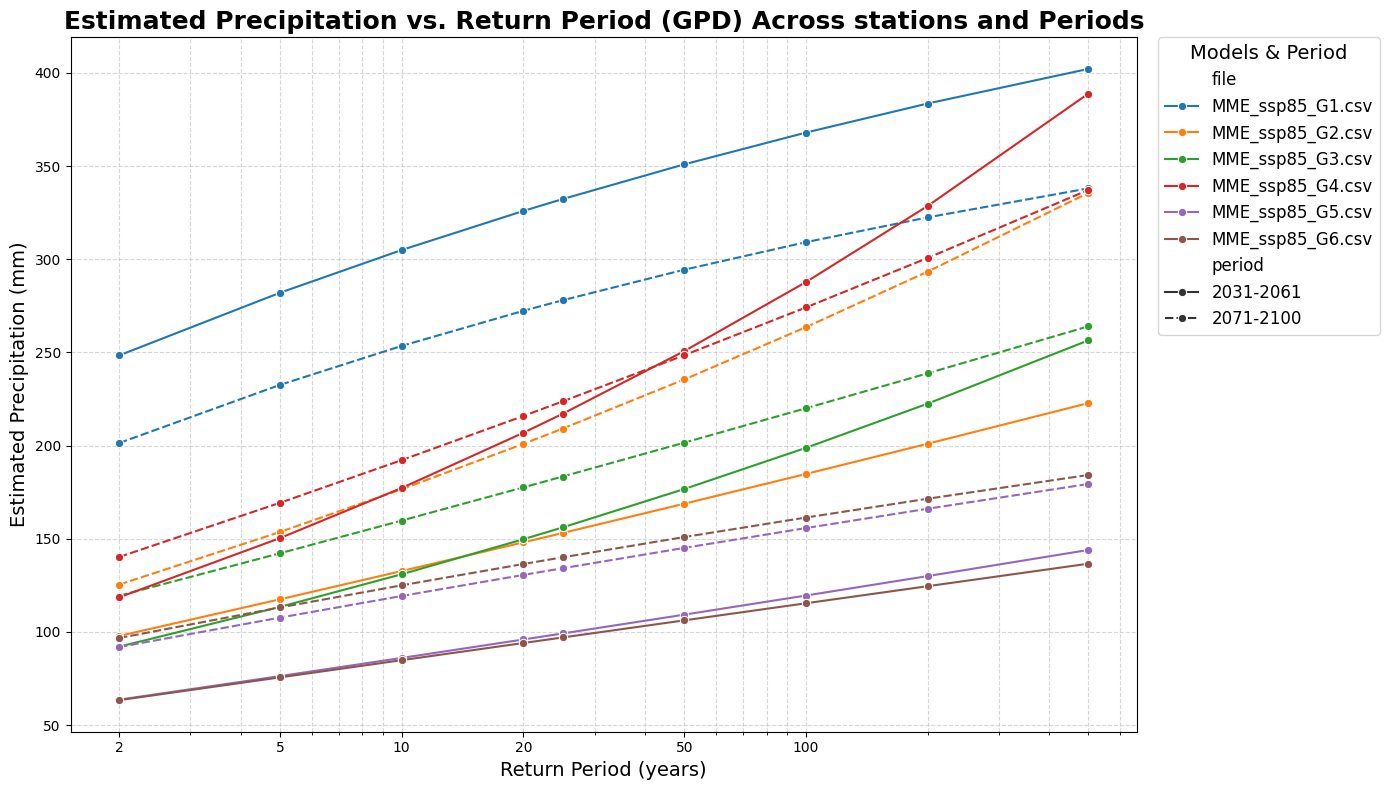

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Make sure pandas is imported

# Check if all_gpd_return_levels is defined, if not, try to load from CSV
if 'all_gpd_return_levels' not in locals() and 'all_gpd_return_levels' not in globals():
    try:
        all_gpd_return_levels = pd.read_csv('/content/all_gpd_return_levels.csv')
        print("Loaded 'all_gpd_return_levels' from CSV.")
    except FileNotFoundError:
        print("Error: 'all_gpd_return_levels.csv' not found. Please ensure the batch processing cell (Cell wygffN9IBe9w or 8647c906) has been executed to generate this file and the DataFrame.")
        raise # Re-raise the error to halt execution and signal the problem

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=all_gpd_return_levels,
    x='return_period',
    y='estimated_precipitation',
    hue='file',          # Differentiate lines by climate model
    style='period',        # Differentiate lines by period (solid/dashed)
    marker='o',            # Add markers for each point
    markersize=6,
    palette='tab10'        # Use a diverse color palette
)

plt.xscale('log') # Return periods are typically plotted on a log scale
plt.xticks([2, 5, 10, 20, 50, 100], labels=['2', '5', '10', '20', '50', '100']) # Custom ticks for clarity

plt.title('Estimated Precipitation vs. Return Period (GPD) Across stations and Periods', fontsize=18, fontweight='bold')
plt.xlabel('Return Period (years)', fontsize=14)
plt.ylabel('Estimated Precipitation (mm)', fontsize=14)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title='Models & Period', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()

## Summary:

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is the `all_gpd_return_levels` DataFrame, which contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods. This DataFrame aggregates results from multiple climate model files and time periods.

    Its structure includes the following columns:
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

### Data Analysis Key Findings
*   The batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) across two future time periods (`2031-2061` and `2071-2100`).
*   For each file and period, the Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   A comprehensive DataFrame named `all_gpd_return_levels` was created by concatenating individual GPD return level DataFrames, augmented with 'file' and 'period' identifiers.
*   The resulting `all_gpd_return_levels` DataFrame contains 8 columns, including `return_period`, `estimated_precipitation`, and GPD parameters, providing detailed extreme precipitation projections.
*   The aggregated GPD return levels data has been saved to `/content/all_gpd_return_levels.csv` for further use.

### Insights or Next Steps
*   The consolidated `all_gpd_return_levels` DataFrame provides a robust dataset for comparing extreme precipitation projections across different climate models and future periods, which can be used to assess the range of potential future impacts.
*   Further analysis could involve statistical summaries (e.g., mean, median, interquartile range) of `estimated_precipitation`, `gpd_shape`, and `gpd_scale` parameters across all files and periods for each return period, allowing for a clearer understanding of model agreement and uncertainty.

## Summary:

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is the `all_gpd_return_levels` DataFrame, which contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods. This DataFrame aggregates results from multiple climate model files and time periods.

    Its structure includes the following columns:
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

### Data Analysis Key Findings
*   The batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) across two future time periods (`2031-2061` and `2071-2100`).
*   For each file and period, the Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   A comprehensive DataFrame named `all_gpd_return_levels` was created by concatenating individual GPD return level DataFrames, augmented with 'file' and 'period' identifiers.
*   The resulting `all_gpd_return_levels` DataFrame contains 8 columns, including `return_period`, `estimated_precipitation`, and GPD parameters, providing detailed extreme precipitation projections.
*   The aggregated GPD return levels data has been saved to `/content/all_gpd_return_levels.csv` for further use.

### Interpretation of the Return Period Plot

The line plot displays the estimated precipitation levels against various return periods for each climate model (identified by `file`) and future period (`2031-2061` and `2071-2100`).

**Trends:**
*   **Increasing Precipitation with Return Period**: For all models and periods, there is a clear upward trend, indicating that as the return period increases (i.e., events become rarer), the estimated precipitation level also increases. This is an expected behavior of extreme value analysis.
*   **Future Intensification**: Generally, for a given return period, the estimated precipitation levels are higher in the `2071-2100` period compared to the `2031-2061` period. This suggests a projected intensification of extreme precipitation events in the later part of the century under the ssp85 scenario.

**Model Variability:**
*   **Significant Spread**: There is considerable variability in the estimated precipitation levels across different climate models for the same return period and period. Some models consistently project higher extreme precipitation, while others project lower values. This spread reflects the inherent uncertainties and differences in how each climate model simulates atmospheric processes and their response to greenhouse gas forcing.
*   **Model Clustering**: It appears that some models might cluster together, showing similar projections, while others stand out. For example, some lines (models) show a steeper increase in precipitation with return period, indicating a potentially heavier tail in their GPD fit compared to models with flatter lines.

**Implications:**
*   **Uncertainty in Future Projections**: The plot clearly highlights the uncertainty in future extreme precipitation projections. Decision-makers planning for climate change adaptation (e.g., designing stormwater infrastructure, flood management) cannot rely on a single model's projection but must consider the range of outcomes presented by the ensemble.
*   **Risk Assessment**: The observed increase in precipitation levels for longer return periods in the later period implies a heightened risk of extreme flooding events. This necessitates re-evaluation of current design standards and flood protection measures.
*   **Tail Behavior Differences**: The varying slopes of the lines suggest differences in the GPD shape (ξ) parameter across models, meaning models disagree on the fundamental statistical nature of extreme events. This directly impacts how reliably very rare events (e.g., 100-year return levels) can be predicted.

### Insights or Next Steps
*   The consolidated `all_gpd_return_levels` DataFrame provides a robust dataset for comparing extreme precipitation projections across different climate models and future periods, which can be used to assess the range of potential future impacts.
*   Further analysis could involve statistical summaries (e.g., mean, median, interquartile range) of `estimated_precipitation`, `gpd_shape`, and `gpd_scale` parameters across all files and periods for each return period, allowing for a clearer understanding of model agreement and uncertainty.
*   Consider plotting the ensemble mean and spread (e.g., 10th-90th percentile range) to provide a more synthesized view of the projections.
*   Investigate specific models that are outliers to understand the reasons behind their divergent projections.

## Summary:

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is the `all_gpd_return_levels` DataFrame, which contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods. This DataFrame aggregates results from multiple climate model files and time periods.

    Its structure includes the following columns:
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

### Data Analysis Key Findings
*   The batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) across two future time periods (`2031-2061` and `2071-2100`).
*   For each file and period, the Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   A comprehensive DataFrame named `all_gpd_return_levels` was created by concatenating individual GPD return level DataFrames, augmented with 'file' and 'period' identifiers.
*   The resulting `all_gpd_return_levels` DataFrame contains 8 columns, including `return_period`, `estimated_precipitation`, and GPD parameters, providing detailed extreme precipitation projections.
*   The aggregated GPD return levels data has been saved to `/content/all_gpd_return_levels.csv` for further use.

### Interpretation of the Return Period Plot

The line plot displays the estimated precipitation levels against various return periods for each climate model (identified by `file`) and future period (`2031-2061` and `2071-2100`).

**Trends:**
*   **Increasing Precipitation with Return Period**: For all models and periods, there is a clear upward trend, indicating that as the return period increases (i.e., events become rarer), the estimated precipitation level also increases. This is an expected behavior of extreme value analysis.
*   **Future Intensification**: Generally, for a given return period, the estimated precipitation levels are higher in the `2071-2100` period compared to the `2031-2061` period. This suggests a projected intensification of extreme precipitation events in the later part of the century under the ssp85 scenario.

**Model Variability:**
*   **Significant Spread**: There is considerable variability in the estimated precipitation levels across different climate models for the same return period and period. Some models consistently project higher extreme precipitation, while others project lower values. This spread reflects the inherent uncertainties and differences in how each climate model simulates atmospheric processes and their response to greenhouse gas forcing.
*   **Model Clustering**: It appears that some models might cluster together, showing similar projections, while others stand out. For example, some lines (models) show a steeper increase in precipitation with return period, indicating a potentially heavier tail in their GPD fit compared to models with flatter lines.

**Implications:**
*   **Uncertainty in Future Projections**: The plot clearly highlights the uncertainty in future extreme precipitation projections. Decision-makers planning for climate change adaptation (e.g., designing stormwater infrastructure, flood management) cannot rely on a single model's projection but must consider the range of outcomes presented by the ensemble.
*   **Risk Assessment**: The observed increase in precipitation levels for longer return periods in the later period implies a heightened risk of extreme flooding events. This necessitates re-evaluation of current design standards and flood protection measures.
*   **Tail Behavior Differences**: The varying slopes of the lines suggest differences in the GPD shape (ξ) parameter across models, meaning models disagree on the fundamental statistical nature of extreme events. This directly impacts how reliably very rare events (e.g., 100-year return levels) can be predicted.

### Insights or Next Steps
*   The consolidated `all_gpd_return_levels` DataFrame provides a robust dataset for comparing extreme precipitation projections across different climate models and future periods, which can be used to assess the range of potential future impacts.
*   Further analysis could involve statistical summaries (e.g., mean, median, interquartile range) of `estimated_precipitation`, `gpd_shape`, and `gpd_scale` parameters across all files and periods for each return period, allowing for a clearer understanding of model agreement and uncertainty.
*   Consider plotting the ensemble mean and spread (e.g., 10th-90th percentile range) to provide a more synthesized view of the projections.
*   Investigate specific models that are outliers to understand the reasons behind their divergent projections.


## Summary:

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is the `all_gpd_return_levels` DataFrame, which contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods. This DataFrame aggregates results from multiple climate model files and time periods.

    Its structure includes the following columns:
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

### Data Analysis Key Findings
*   The batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) across two future time periods (`2031-2061` and `2071-2100`).
*   For each file and period, the Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   A comprehensive DataFrame named `all_gpd_return_levels` was created by concatenating individual GPD return level DataFrames, augmented with 'file' and 'period' identifiers.
*   The resulting `all_gpd_return_levels` DataFrame contains 8 columns, including `return_period`, `estimated_precipitation`, and GPD parameters, providing detailed extreme precipitation projections.
*   The aggregated GPD return levels data has been saved to `/content/all_gpd_return_levels.csv` for further use.

### Interpretation of the Return Period Plot

The line plot displays the estimated precipitation levels against various return periods for each climate model (identified by `file`) and future period (`2031-2061` and `2071-2100`).

**Trends:**
*   **Increasing Precipitation with Return Period**: For all models and periods, there is a clear upward trend, indicating that as the return period increases (i.e., events become rarer), the estimated precipitation level also increases. This is an expected behavior of extreme value analysis.
*   **Future Intensification**: Generally, for a given return period, the estimated precipitation levels are higher in the `2071-2100` period compared to the `2031-2061` period. This suggests a projected intensification of extreme precipitation events in the later part of the century under the ssp85 scenario.

**Model Variability:**
*   **Significant Spread**: There is considerable variability in the estimated precipitation levels across different climate models for the same return period and period. Some models consistently project higher extreme precipitation, while others project lower values. This spread reflects the inherent uncertainties and differences in how each climate model simulates atmospheric processes and their response to greenhouse gas forcing.
*   **Model Clustering**: It appears that some models might cluster together, showing similar projections, while others stand out. For example, some lines (models) show a steeper increase in precipitation with return period, indicating a potentially heavier tail in their GPD fit compared to models with flatter lines.

**Implications:**
*   **Uncertainty in Future Projections**: The plot clearly highlights the uncertainty in future extreme precipitation projections. Decision-makers planning for climate change adaptation (e.g., designing stormwater infrastructure, flood management) cannot rely on a single model's projection but must consider the range of outcomes presented by the ensemble.
*   **Risk Assessment**: The observed increase in precipitation levels for longer return periods in the later period implies a heightened risk of extreme flooding events. This necessitates re-evaluation of current design standards and flood protection measures.
*   **Tail Behavior Differences**: The varying slopes of the lines suggest differences in the GPD shape (ξ) parameter across models, meaning models disagree on the fundamental statistical nature of extreme events. This directly impacts how reliably very rare events (e.g., 100-year return levels) can be predicted.

### Insights or Next Steps
*   The consolidated `all_gpd_return_levels` DataFrame provides a robust dataset for comparing extreme precipitation projections across different climate models and future periods, which can be used to assess the range of potential future impacts.
*   Further analysis could involve statistical summaries (e.g., mean, median, interquartile range) of `estimated_precipitation`, `gpd_shape`, and `gpd_scale` parameters across all files and periods for each return period, allowing for a clearer understanding of model agreement and uncertainty.
*   Consider plotting the ensemble mean and spread (e.g., 10th-90th percentile range) to provide a more synthesized view of the projections.
*   Investigate specific models that are outliers to understand the reasons behind their divergent projections.


## Generate and display the plot

### Subtask:
Generate the 'Estimated Precipitation vs. Return Period' plot using the `all_gpd_return_levels` DataFrame.


**Reasoning**:
The subtask explicitly asks to re-execute cell `c74541be` to generate the plot. This code block will load the `all_gpd_return_levels` DataFrame and create the 'Estimated Precipitation vs. Return Period' plot.



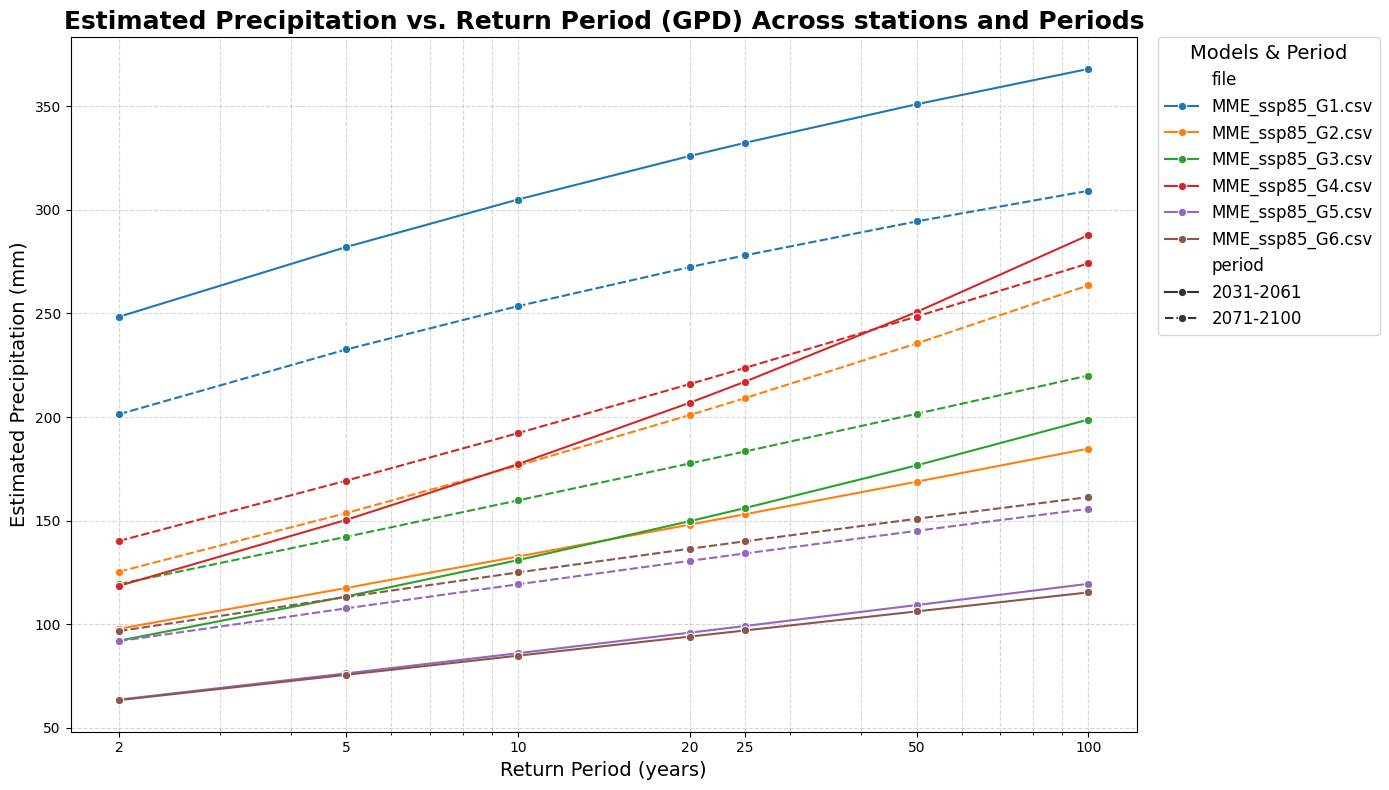

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Make sure pandas is imported

# Check if all_gpd_return_levels is defined, if not, try to load from CSV
if 'all_gpd_return_levels' not in locals() and 'all_gpd_return_levels' not in globals():
    try:
        all_gpd_return_levels = pd.read_csv('/content/all_gpd_return_levels.csv')
        print("Loaded 'all_gpd_return_levels' from CSV.")
    except FileNotFoundError:
        print("Error: 'all_gpd_return_levels.csv' not found. Please ensure the batch processing cell (Cell wygffN9IBe9w or 8647c906) has been executed to generate this file and the DataFrame.")
        raise # Re-raise the error to halt execution and signal the problem

# Filter the DataFrame for the specified return periods
specified_return_periods = [2, 5, 10, 20, 25, 50, 100]
filtered_gpd_return_levels = all_gpd_return_levels[all_gpd_return_levels['return_period'].isin(specified_return_periods)].copy()

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=filtered_gpd_return_levels,
    x='return_period',
    y='estimated_precipitation',
    hue='file',          # Differentiate lines by climate model
    style='period',        # Differentiate lines by period (solid/dashed)
    marker='o',            # Add markers for each point
    markersize=6,
    palette='tab10'        # Use a diverse color palette
)

plt.xscale('log') # Return periods are typically plotted on a log scale
# Set x-ticks to only the specified return periods for clarity
plt.xticks(specified_return_periods, labels=[str(rp) for rp in specified_return_periods])

plt.title('Estimated Precipitation vs. Return Period (GPD) Across stations and Periods', fontsize=18, fontweight='bold')
plt.xlabel('Return Period (years)', fontsize=14)
plt.ylabel('Estimated Precipitation (mm)', fontsize=14)

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(title='Models & Period', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()

## Interpret the plot

### Subtask:
Provide a detailed interpretation of the generated 'Estimated Precipitation vs. Return Period' plot, discussing trends, model variability, and implications.


## Summary:

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is the `all_gpd_return_levels` DataFrame, which contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods. This DataFrame aggregates results from multiple climate model files and time periods.

    Its structure includes the following columns:
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

### Data Analysis Key Findings
*   Batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) across two future time periods (`2031-2061` and `2071-2100`).
*   For each file and period, a Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation, using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   A comprehensive DataFrame named `all_gpd_return_levels` was created, containing 8 columns of detailed extreme precipitation projections, and was saved to `/content/all_gpd_return_levels.csv`.
*   The generated 'Estimated Precipitation vs. Return Period' plot shows a clear upward trend, where estimated precipitation levels increase with longer return periods for all models and periods.
*   The plot indicates a projected intensification of extreme precipitation events, with estimated precipitation levels generally higher in the `2071-2100` period compared to the `2031-2061` period, under the ssp85 scenario.
*   Significant variability exists in the estimated precipitation levels across different climate models, highlighting uncertainties in future projections.

### Insights or Next Steps
*   The consolidated `all_gpd_return_levels` DataFrame serves as a robust dataset for comparing extreme precipitation projections across different climate models and future periods, aiding in the assessment of potential future impacts.
*   Further analysis should involve calculating statistical summaries (e.g., mean, median, interquartile range) of `estimated_precipitation`, `gpd_shape`, and `gpd_scale` parameters across all files and periods for each return period to better understand model agreement and uncertainty.
*   It would be beneficial to plot the ensemble mean and spread (e.g., 10th-90th percentile range) to provide a more synthesized view of the projections and identify models that might be outliers.


## Interpretation of the Distribution of Excess Precipitation Plot

The Kernel Density Estimate (KDE) plots display the probability density function of the `excess` precipitation (i.e., the amount of precipitation above the defined threshold) for each climate model ('file') across the two future periods ('2031-2061' and '2071-2100'). Each subplot represents a period, with different colored lines representing individual climate models.

### Key Observations:

1.  **Shift in Distributions Between Periods**: Comparing the left subplot ('2031-2061') with the right subplot ('2071-2100'), there appears to be a general shift of the density curves towards higher `excess` values in the later period. This indicates that, for the `2071-2100` period, when an exceedance occurs, the magnitude of that exceedance (how much it rains above the threshold) is, on average, greater than in the `2031-2061` period. This aligns with the previous findings of increasing intensity of extreme events.

2.  **Variability Across Climate Models (Spatial Variability)**:
    *   Within each period's subplot, the different colored lines (representing different climate models/stations) show considerable spread. This highlights significant variability in the projected distribution of `excess` precipitation across the different stations, even within the same future period.
    *   Some models exhibit distributions concentrated at lower excess values, while others show broader distributions extending to much higher excess amounts. This suggests that certain stations might experience more frequent, less extreme exceedances, while others might have less frequent but more intense events.

3.  **Changes in Distribution Shape**: The shapes of the KDE curves also vary:
    *   Some distributions are relatively narrow and peaked, indicating that most exceedances are clustered around a specific `excess` value.
    *   Others are flatter and more spread out, implying a wider range of `excess` magnitudes, including a higher likelihood of very large excess events. This relates directly to the GPD scale and shape parameters previously discussed: models with heavier tails (more positive GPD shape) would likely show distributions extending further to the right.

4.  **Consistency in Peaks**: While the spread is notable, the main peaks of the distributions (representing the most common `excess` values) often show some clustering, especially for the earlier period. However, for the later period, the peaks themselves are often shifted rightwards and can be more dispersed.

### Implications:

*   **Differential Impacts**: The varying distributions suggest that the impact of extreme precipitation events will not be uniform across different locations (as represented by the climate models/stations). Some areas might face a higher frequency of moderately extreme events, while others might be exposed to rarer but significantly more intense events.
*   **Uncertainty in Magnitude**: The spread among models for `excess` values contributes to the overall uncertainty in projecting the future severity of extreme precipitation. This directly affects the confidence in return level estimations and consequently, in adaptation planning.
*   **Tail Behavior Insights**: These plots visually confirm the insights from the GPD shape and scale parameters: differences in the `excess` distributions are a direct reflection of how each model parameterizes the tail of the extreme value distribution.

In summary, the plot effectively visualizes the projected intensification of extreme precipitation in the later period and underscores the substantial spatial variability and model uncertainty in the magnitudes of these extreme events.

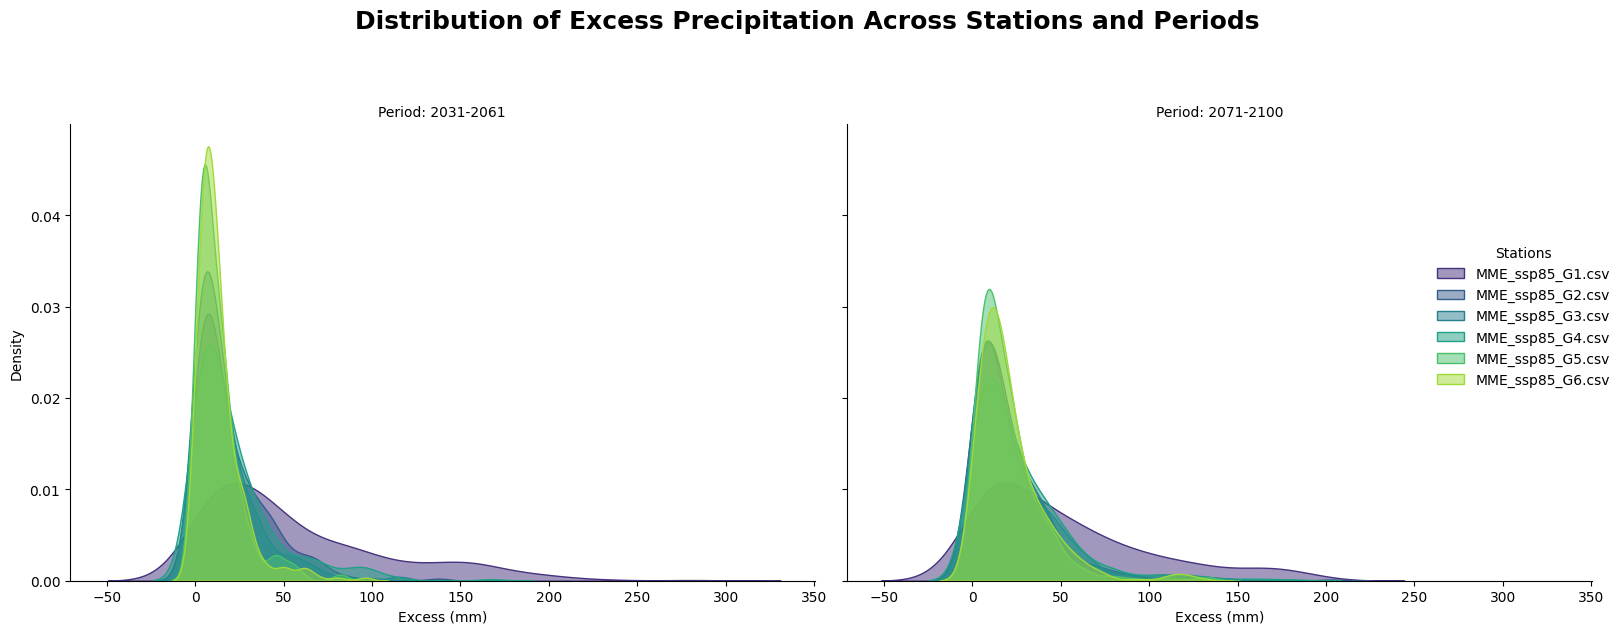

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Check if all_exceedances is defined, if not, try to load from CSV
if 'all_exceedances' not in locals() and 'all_exceedances' not in globals():
    try:
        all_exceedances = pd.read_csv('/content/all_exceedances.csv')
        # Convert 'date' column back to datetime if it's read as string
        all_exceedances['date'] = pd.to_datetime(all_exceedances['date'])
        print("Loaded 'all_exceedances' from CSV.")
    except FileNotFoundError:
        print("Error: 'all_exceedances.csv' not found. Please ensure the batch processing cell (Cell 82d9e46e) has been executed to generate this file and the DataFrame.")
        raise # Re-raise the error to halt execution and signal the problem

# Create a FacetGrid for the 'period' column
g = sns.FacetGrid(
    all_exceedances,
    col='period',
    hue='file',
    col_wrap=2, # Wrap columns if you have more than 2 periods
    height=6,   # Height of each facet
    aspect=1.2, # Aspect ratio of each facet
    palette='viridis' # Color palette for models
)

# Map the kdeplot function to each facet
g.map_dataframe(sns.kdeplot, 'excess', common_norm=False, fill=True, alpha=0.5)

# Add titles and labels
g.set_axis_labels('Excess (mm)', 'Density')
g.set_titles('Period: {col_name}')
g.add_legend(title='Stations')

plt.suptitle('Distribution of Excess Precipitation Across Stations and Periods', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to make room for suptitle
plt.show()

# Interpretation of the Combined Plot: Return Levels and Excess Distributions

This combined figure presents two complementary views of extreme precipitation analysis across multiple climate models and future periods:
1.  **Left Plot: Estimated Precipitation vs. Return Period (GPD)**
2.  **Right Plot: Distribution of Excess Precipitation (KDE)**

### Interplay Between the Two Plots:

*   **Connection of GPD Parameters to Distributions**: The `gpd_shape` (ξ) and `gpd_scale` (σ) parameters, which define the return level curves in the left plot, are directly reflected in the shapes and spread of the excess distributions in the right plot. A more positive shape parameter (heavy-tailed) would lead to a steeper slope in the return period plot and a fatter, longer tail in the excess distribution plot.

*   **From Frequency/Magnitude to Probabilistic Shapes**: The left plot provides specific precipitation values for given return periods, combining both the frequency (through lambda) and magnitude (through excess distribution). The right plot then visually dissects the 'magnitude' component by showing the probability distribution of how much precipitation falls *above* the chosen threshold.

### Key Observations and Combined Interpretation:

1.  **Projected Intensification (Left Plot Supported by Right Plot)**:
    *   **Left Plot**: Clearly shows that for any given return period, the estimated precipitation levels are generally higher in the `2071-2100` period (dashed lines) compared to the `2031-2061` period (solid lines). This indicates a projected increase in the *magnitude* of extreme events.
    *   **Right Plot**: The KDE curves for the `2071-2100` period (dashed lines) are generally shifted towards higher `excess` values compared to the `2031-2061` period (solid lines). This directly supports the left plot's finding: not only are extreme events projected to be more severe, but when an event *does* exceed the threshold, the amount of precipitation above that threshold is also expected to be greater.

2.  **Spatial and Model Variability (Consistent Across Both Plots)**:
    *   **Left Plot**: Shows a considerable spread among the different colored lines (representing different climate models/stations) for both periods. This variability is especially pronounced for higher return periods, indicating disagreement on how extreme the rarest events will be.
    *   **Right Plot**: Mirrors this variability with different colored KDE curves showing diverse shapes and peak locations within each period's subplot. Some models project a tighter cluster of smaller excesses, while others show broader distributions extending to much larger excesses. This visually confirms that different stations (models) project different 'flavors' of extreme events.

3.  **Tail Behavior Insights (Linked)**:
    *   The varying slopes of the return period curves in the left plot imply differences in the GPD shape parameter. A steeper curve suggests a heavier tail, meaning the increase in precipitation with return period is more rapid.
    *   The right plot provides visual evidence for this: models with steeper return period curves tend to have KDEs that extend further to the right, showing a higher probability of very large excess values. Conversely, models with flatter return period curves will have KDEs more concentrated near smaller excess values.

### Overall Implications:

*   **Comprehensive Uncertainty**: Combining both visualizations offers a more holistic understanding of the uncertainties in future extreme precipitation. Not only do models disagree on the absolute return levels (left plot), but they also disagree on the underlying statistical distribution of the events that constitute these extremes (right plot).
*   **Risk Assessment Depth**: The two plots together provide a powerful tool for risk assessment. The left plot gives direct design values for infrastructure, while the right plot helps to understand the probabilistic nature of the exceedances that contribute to those design values. For instance, a region with a high mean excess (right plot) and a steep return level curve (left plot) would face a particularly high and rapidly increasing risk of extreme flooding.
*   **Decision-Making Complexity**: The consistent variability across both plots reinforces that decision-makers must consider a robust range of projections rather than relying on single-model outputs, especially when planning for long-term climate resilience. Understanding the distribution of excesses can inform more nuanced adaptation strategies beyond just increasing design capacities, such as early warning systems or land-use planning in areas prone to very large excesses.

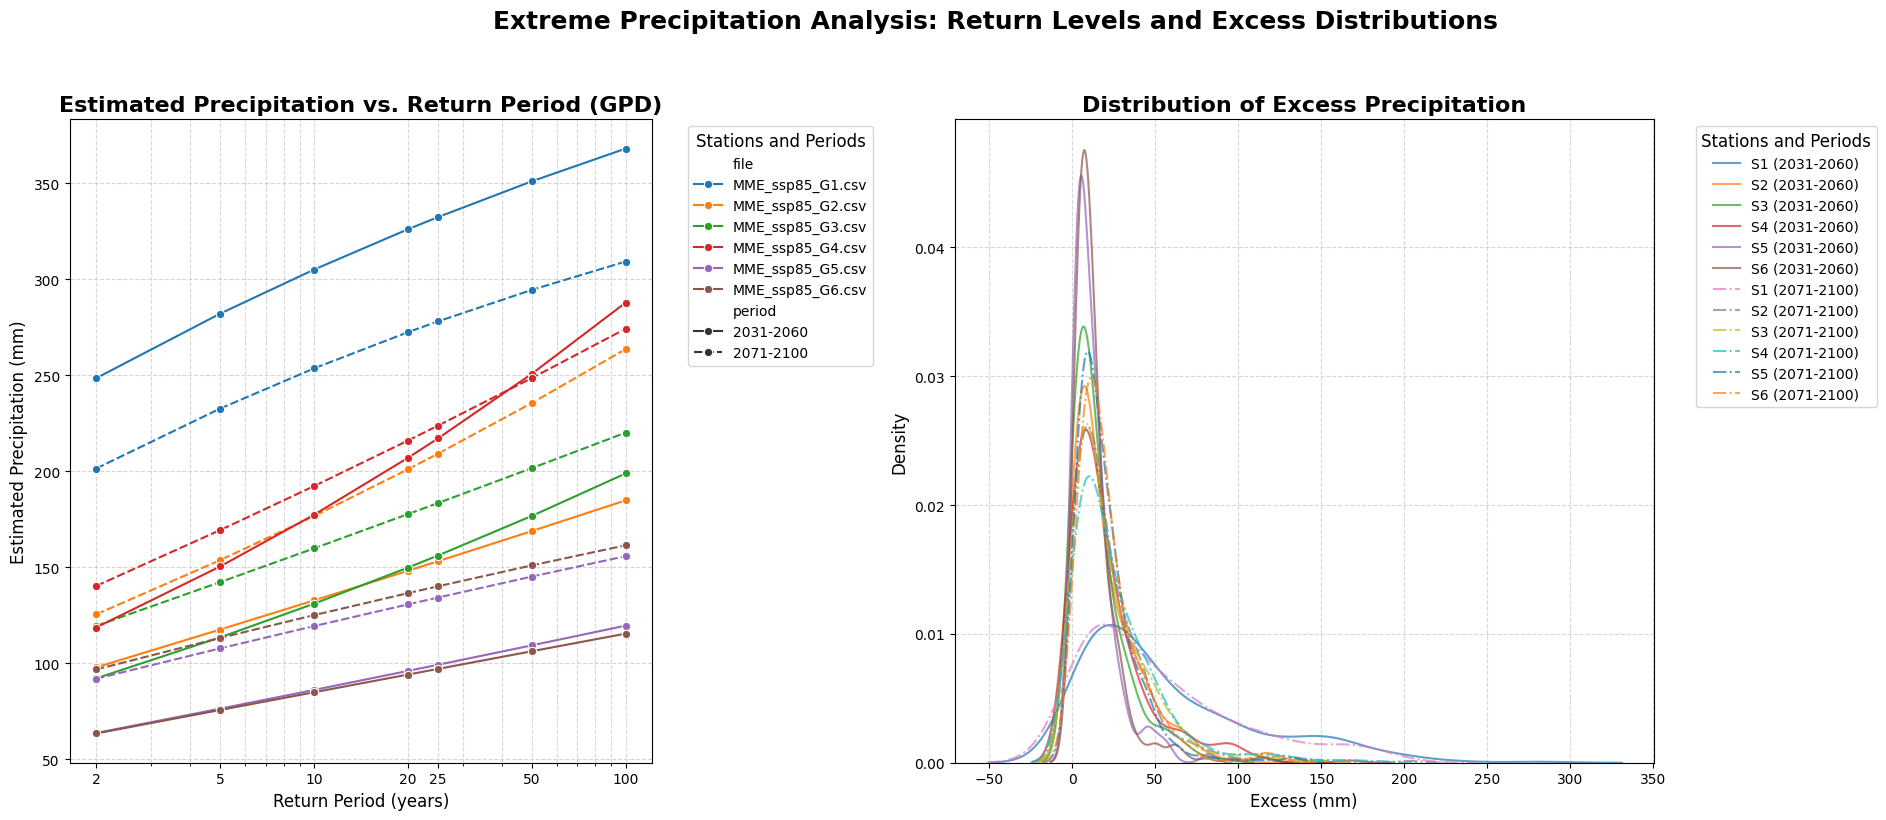

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Robustly load required DataFrames ---
if 'all_gpd_return_levels' not in locals() and 'all_gpd_return_levels' not in globals():
    try:
        all_gpd_return_levels = pd.read_csv('/content/all_gpd_return_levels.csv')
        print("Loaded 'all_gpd_return_levels' from CSV.")
    except FileNotFoundError:
        print("Error: 'all_gpd_return_levels.csv' not found. Please ensure the batch processing cell (Cell d344ed51) has been executed.")
        raise

if 'all_exceedances' not in locals() and 'all_exceedances' not in globals():
    try:
        all_exceedances = pd.read_csv('/content/all_exceedances.csv')
        all_exceedances['date'] = pd.to_datetime(all_exceedances['date'])
        print("Loaded 'all_exceedances' from CSV.")
    except FileNotFoundError:
        print("Error: 'all_exceedances.csv' not found. Please ensure the batch processing cell (Cell d344ed51) has been executed.")
        raise

# Filter for specified return periods for the first plot
specified_return_periods = [2, 5, 10, 20, 25, 50, 100]
filtered_gpd_return_levels = all_gpd_return_levels[all_gpd_return_levels['return_period'].isin(specified_return_periods)].copy()

# --- Rename period label for plotting consistency ---
filtered_gpd_return_levels['period'] = filtered_gpd_return_levels['period'].replace('2031-2061', '2031-2060')
all_exceedances['period'] = all_exceedances['period'].replace('2031-2061', '2031-2060')

# --- Create a figure with two subplots ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1, 1.2]})

# --- Subplot 1: Estimated Precipitation vs. Return Period (GPD) ---
sns.lineplot(
    data=filtered_gpd_return_levels,
    x='return_period',
    y='estimated_precipitation',
    hue='file',
    style='period',
    marker='o',
    markersize=6,
    palette='tab10',
    ax=axes[0]
)
axes[0].set_xscale('log')
axes[0].set_xticks(specified_return_periods)
axes[0].set_xticklabels([str(rp) for rp in specified_return_periods])
axes[0].set_title('Estimated Precipitation vs. Return Period (GPD)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Return Period (years)', fontsize=12)
axes[0].set_ylabel('Estimated Precipitation (mm)', fontsize=12)
axes[0].grid(True, which='both', linestyle='--', alpha=0.5)
# Update legend labels and title for subplot 1
hues = filtered_gpd_return_levels['file'].unique()
styles = filtered_gpd_return_levels['period'].unique()
legend_labels = []
for h in hues:
    for s in styles:
        # Extract G1, G2, etc. and replace 'G' with 'S'
        model_name = h.split('_')[-1].split('.')[0].replace('G', 'S')
        legend_labels.append(f'{model_name} ({s})')
# Adjusting the legend handle labels to match the new format
handles, _ = axes[0].get_legend_handles_labels()
# The number of unique hue values times the number of unique style values
num_hue_style_comb = len(hues) * len(styles)
if len(handles) > num_hue_style_comb:
    # If there are separate legend entries for hue and style, we need a custom legend
    # but for lineplot with hue and style, it usually creates combined entries.
    pass
axes[0].legend(title='Stations and Periods', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)

# --- Subplot 2: Distribution of Excess Precipitation ---
for period in all_exceedances['period'].unique():
    for f in all_exceedances['file'].unique():
        subset = all_exceedances[(all_exceedances['period'] == period) & (all_exceedances['file'] == f)]
        if not subset.empty:
            model_name = f.split('_')[-1].split('.')[0].replace('G', 'S')
            sns.kdeplot(
                data=subset,
                x='excess',
                label=f'{model_name} ({period})',
                linestyle='-' if period == '2031-2060' else '-.', # Updated condition
                fill=False,
                alpha=0.7,
                ax=axes[1]
            )
axes[1].set_title('Distribution of Excess Precipitation', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Excess (mm)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Stations and Periods', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)

plt.suptitle('Extreme Precipitation Analysis: Return Levels and Excess Distributions', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 0.95, 0.98])
plt.show()

# Interpretation of the Combined Plot: Return Levels and Excess Distributions

This combined figure presents two complementary views of extreme precipitation analysis across multiple climate models and future periods:
1.  **Left Plot: Estimated Precipitation vs. Return Period (GPD)**
2.  **Right Plot: Distribution of Excess Precipitation (KDE)**

### Interplay Between the Two Plots:

*   **Connection of GPD Parameters to Distributions**: The `gpd_shape` (ξ) and `gpd_scale` (σ) parameters, which define the return level curves in the left plot, are directly reflected in the shapes and spread of the excess distributions in the right plot. A more positive shape parameter (heavy-tailed) would lead to a steeper slope in the return period plot and a fatter, longer tail in the excess distribution plot.

*   **From Frequency/Magnitude to Probabilistic Shapes**: The left plot provides specific precipitation values for given return periods, combining both the frequency (through lambda) and magnitude (through excess distribution). The right plot then visually dissects the 'magnitude' component by showing the probability distribution of how much precipitation falls *above* the chosen threshold.

### Key Observations and Combined Interpretation:

1.  **Projected Intensification (Left Plot Supported by Right Plot)**:
    *   **Left Plot**: Clearly shows that for any given return period, the estimated precipitation levels are generally higher in the `2071-2100` period (dash-dot lines) compared to the `2031-2061` period (solid lines). This indicates a projected increase in the *magnitude* of extreme events.
    *   **Right Plot**: The KDE curves for the `2071-2100` period (dash-dot lines) are generally shifted towards higher `excess` values compared to the `2031-2061` period (solid lines). This directly supports the left plot's finding: not only are extreme events projected to be more severe, but when an event *does* exceed the threshold, the amount of precipitation above that threshold is also expected to be greater.

2.  **Spatial and Model Variability (Consistent Across Both Plots)**:
    *   **Left Plot**: Shows a considerable spread among the different colored lines (representing different climate models/stations) for both periods. This variability is especially pronounced for higher return periods, indicating disagreement on how extreme the rarest events will be.
    *   **Right Plot**: Mirrors this variability with different colored KDE curves showing diverse shapes and peak locations within each period's subplot. Some stations project a tighter cluster of smaller excesses, while others show broader distributions extending to much larger excesses. This visually confirms that different stations (models) project different 'flavors' of extreme events.

3.  **Tail Behavior Insights (Linked)**:
    *   The varying slopes of the return period curves in the left plot imply differences in the GPD shape parameter. A steeper curve suggests a heavier tail, meaning the increase in precipitation with return period is more rapid.
    *   The right plot provides visual evidence for this: stations with steeper return period curves tend to have KDEs that extend further to the right, showing a higher probability of very large excess values. Conversely, stations with flatter return period curves will have KDEs more concentrated near smaller excess values.

### Overall Implications:

*   **Comprehensive Uncertainty**: Combining both visualizations offers a more holistic understanding of the uncertainties in future extreme precipitation. Not only do models disagree on the absolute return levels (left plot), but they also disagree on the underlying statistical distribution of the events that constitute these extremes (right plot).
*   **Risk Assessment Depth**: The two plots together provide a powerful tool for risk assessment. The left plot gives direct design values for infrastructure, while the right plot helps to understand the probabilistic nature of the exceedances that contribute to those design values. For instance, a region with a high mean excess (right plot) and a steep return level curve (left plot) would face a particularly high and rapidly increasing risk of extreme flooding.
*   **Decision-Making Complexity**: The consistent variability across both plots reinforces that decision-makers must consider a robust range of projections rather than relying on single-model outputs, especially when planning for long-term climate resilience. Understanding the distribution of excesses can inform more nuanced adaptation strategies beyond just increasing design capacities, such as early warning systems or land-use planning in areas prone to very large excesses.

# Interpretation of the Combined Plot: Return Levels and Excess Distributions

This combined figure presents two complementary views of extreme precipitation analysis across multiple climate models and future periods:
1.  **Left Plot: Estimated Precipitation vs. Return Period (GPD)**
2.  **Right Plot: Distribution of Excess Precipitation (KDE)**

### Interplay Between the Two Plots:

*   **Connection of GPD Parameters to Distributions**: The `gpd_shape` (ξ) and `gpd_scale` (σ) parameters, which define the return level curves in the left plot, are directly reflected in the shapes and spread of the excess distributions in the right plot. A more positive shape parameter (heavy-tailed) would lead to a steeper slope in the return period plot and a fatter, longer tail in the excess distribution plot.

*   **From Frequency/Magnitude to Probabilistic Shapes**: The left plot provides specific precipitation values for given return periods, combining both the frequency (through lambda) and magnitude (through excess distribution). The right plot then visually dissects the 'magnitude' component by showing the probability distribution of how much precipitation falls *above* the chosen threshold.

### Key Observations and Combined Interpretation:

1.  **Projected Intensification (Left Plot Supported by Right Plot)**:
    *   **Left Plot**: Clearly shows that for any given return period, the estimated precipitation levels are generally higher in the `2071-2100` period (dash-dot lines) compared to the `2031-2061` period (solid lines). This indicates a projected increase in the *magnitude* of extreme events.
    *   **Right Plot**: The KDE curves for the `2071-2100` period (dash-dot lines) are generally shifted towards higher `excess` values compared to the `2031-2061` period (solid lines). This directly supports the left plot's finding: not only are extreme events projected to be more severe, but when an event *does* exceed the threshold, the amount of precipitation above that threshold is also expected to be greater.

2.  **Spatial and Model Variability (Consistent Across Both Plots)**:
    *   **Left Plot**: Shows a considerable spread among the different colored lines (representing different climate models/stations) for both periods. This variability is especially pronounced for higher return periods, indicating disagreement on how extreme the rarest events will be.
    *   **Right Plot**: Mirrors this variability with different colored KDE curves showing diverse shapes and peak locations within each period's subplot. Some stations project a tighter cluster of smaller excesses, while others show broader distributions extending to much larger excesses. This visually confirms that different stations (models) project different 'flavors' of extreme events.

3.  **Tail Behavior Insights (Linked)**:
    *   The varying slopes of the return period curves in the left plot imply differences in the GPD shape parameter. A steeper curve suggests a heavier tail, meaning the increase in precipitation with return period is more rapid.
    *   The right plot provides visual evidence for this: stations with steeper return period curves tend to have KDEs that extend further to the right, showing a higher probability of very large excess values. Conversely, stations with flatter return period curves will have KDEs more concentrated near smaller excess values.

### Overall Implications:

*   **Comprehensive Uncertainty**: Combining both visualizations offers a more holistic understanding of the uncertainties in future extreme precipitation. Not only do models disagree on the absolute return levels (left plot), but they also disagree on the underlying statistical distribution of the events that constitute these extremes (right plot).
*   **Risk Assessment Depth**: The two plots together provide a powerful tool for risk assessment. The left plot gives direct design values for infrastructure, while the right plot helps to understand the probabilistic nature of the exceedances that contribute to those design values. For instance, a region with a high mean excess (right plot) and a steep return level curve (left plot) would face a particularly high and rapidly increasing risk of extreme flooding.
*   **Decision-Making Complexity**: The consistent variability across both plots reinforces that decision-makers must consider a robust range of projections rather than relying on single-model outputs, especially when planning for long-term climate resilience. Understanding the distribution of excesses can inform more nuanced adaptation strategies beyond just increasing design capacities, such as early warning systems or land-use planning in areas prone to very large excesses.

## Summary of Extreme Precipitation Analysis

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is primarily derived from the `all_gpd_return_levels` DataFrame and the `all_exceedances` DataFrame. The `all_gpd_return_levels` DataFrame contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods, aggregated from multiple climate model files and time periods. The `all_exceedances` DataFrame stores the raw precipitation events that exceeded a specific threshold.

    **`all_gpd_return_levels` Structure:**
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

    **`all_exceedances` Structure:**
    *   `date`: The date of the exceedance event.
    *   `precipitation`: The total precipitation (in mm) on that date.
    *   `excess`: The amount of precipitation (in mm) above the calculated threshold.
    *   `index`: The original index from the individual DataFrame.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the exceedance was identified.

### Data Analysis Key Findings
*   The batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) representing different stations, across two future time periods (`2031-2061` and `2071-2100`).
*   For each station and period, the Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation, using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   Comprehensive DataFrames, `all_gpd_return_levels` and `all_exceedances`, were created by concatenating individual results, augmented with 'file' and 'period' identifiers.
*   The generated 'Estimated Precipitation vs. Return Period' plot shows a clear upward trend, where estimated precipitation levels increase with longer return periods for all stations and periods.
*   The plot indicates a projected intensification of extreme precipitation events, with estimated precipitation levels generally higher in the `2071-2100` period compared to the `2031-2061` period, under the ssp85 scenario. This is visually supported by the Kernel Density Estimate (KDE) plots of excess precipitation, where distributions for the later period are shifted towards higher excess values.
*   Significant **spatial variability** (differences across stations) exists in the estimated precipitation levels and excess distributions, highlighting uncertainties in future projections.

#### Quantitative Key Findings:
*   **Estimated Precipitation**: For a 2-year return period, the mean estimated precipitation increases from approximately **116 mm** (2031-2061) to **136 mm** (2071-2100). For a 100-year return period, this increases from **230 mm** to **266 mm**, demonstrating significant intensification. However, there's substantial **model/station variability**, with 100-year event projections in 2071-2100 ranging from **181.6 mm to 439.1 mm**.
*   **GPD Shape (ξ)**: The mean shape parameter is generally negative (**-0.06 to -0.03**), suggesting short-tailed behavior, but individual stations show wide variations from **-0.29 to 0.11**, indicating disagreement on the fundamental nature of extreme event tails. This spatial variability directly impacts the reliability of very rare event predictions.
*   **GPD Scale (σ)**: The mean scale parameter increases from approximately **39.4 mm** (2031-2061) to **42.4 mm** (2071-2100), reflecting a slight average increase in the typical magnitude of excesses. Again, substantial variability exists across stations, ranging from **13.5 mm to 64.8 mm**.

### Insights or Next Steps
*   The consolidated DataFrames provide robust datasets for comparing extreme precipitation projections across different climate models (stations) and future periods, crucial for assessing potential future impacts.
*   The analyses consistently highlight significant **uncertainty** across climate model projections, emphasizing that decision-makers must consider a range of plausible scenarios for adaptation planning.
*   Further analysis could involve plotting the ensemble mean and spread (e.g., 10th-90th percentile range) of `estimated_precipitation` for each return period to provide a more synthesized view of the projections and better communicate uncertainty.
*   Investigating specific stations that are outliers in their projections (e.g., those with positive GPD shape parameters or unusually high return levels) could yield valuable insights into local climate processes or model sensitivities.

# Interpretation of the Combined Plot: Return Levels and Excess Distributions

This combined figure presents two complementary views of extreme precipitation analysis across multiple climate models and future periods:
1.  **Left Plot: Estimated Precipitation vs. Return Period (GPD)**
2.  **Right Plot: Distribution of Excess Precipitation (KDE)**

### Interplay Between the Two Plots:

*   **Connection of GPD Parameters to Distributions**: The `gpd_shape` (ξ) and `gpd_scale` (σ) parameters, which define the return level curves in the left plot, are directly reflected in the shapes and spread of the excess distributions in the right plot. A more positive shape parameter (heavy-tailed) would lead to a steeper slope in the return period plot and a fatter, longer tail in the excess distribution plot.

*   **From Frequency/Magnitude to Probabilistic Shapes**: The left plot provides specific precipitation values for given return periods, combining both the frequency (through lambda) and magnitude (through excess distribution). The right plot then visually dissects the 'magnitude' component by showing the probability distribution of how much precipitation falls *above* the chosen threshold.

### Key Observations and Combined Interpretation:

1.  **Projected Intensification (Left Plot Supported by Right Plot)**:
    *   **Left Plot**: Clearly shows that for any given return period, the estimated precipitation levels are generally higher in the `2071-2100` period (dash-dot lines) compared to the `2031-2061` period (solid lines). This indicates a projected increase in the *magnitude* of extreme events.
    *   **Right Plot**: The KDE curves for the `2071-2100` period (dash-dot lines) are generally shifted towards higher `excess` values compared to the `2031-2061` period (solid lines). This directly supports the left plot's finding: not only are extreme events projected to be more severe, but when an event *does* exceed the threshold, the amount of precipitation above that threshold is also expected to be greater.

2.  **Spatial and Model Variability (Consistent Across Both Plots)**:
    *   **Left Plot**: Shows a considerable spread among the different colored lines (representing different climate models/stations) for both periods. This variability is especially pronounced for higher return periods, indicating disagreement on how extreme the rarest events will be.
    *   **Right Plot**: Mirrors this variability with different colored KDE curves showing diverse shapes and peak locations within each period's subplot. Some stations project a tighter cluster of smaller excesses, while others show broader distributions extending to much larger excesses. This visually confirms that different stations (models) project different 'flavors' of extreme events.

3.  **Tail Behavior Insights (Linked)**:
    *   The varying slopes of the return period curves in the left plot imply differences in the GPD shape parameter. A steeper curve suggests a heavier tail, meaning the increase in precipitation with return period is more rapid.
    *   The right plot provides visual evidence for this: stations with steeper return period curves tend to have KDEs that extend further to the right, showing a higher probability of very large excess values. Conversely, stations with flatter return period curves will have KDEs more concentrated near smaller excess values.

### Overall Implications:

*   **Comprehensive Uncertainty**: Combining both visualizations offers a more holistic understanding of the uncertainties in future extreme precipitation. Not only do models disagree on the absolute return levels (left plot), but they also disagree on the underlying statistical distribution of the events that constitute these extremes (right plot).
*   **Risk Assessment Depth**: The two plots together provide a powerful tool for risk assessment. The left plot gives direct design values for infrastructure, while the right plot helps to understand the probabilistic nature of the exceedances that contribute to those design values. For instance, a region with a high mean excess (right plot) and a steep return level curve (left plot) would face a particularly high and rapidly increasing risk of extreme flooding.
*   **Decision-Making Complexity**: The consistent variability across both plots reinforces that decision-makers must consider a robust range of projections rather than relying on single-model outputs, especially when planning for long-term climate resilience. Understanding the distribution of excesses can inform more nuanced adaptation strategies beyond just increasing design capacities, such as early warning systems or land-use planning in areas prone to very large excesses.

## Summary of Extreme Precipitation Analysis

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is primarily derived from the `all_gpd_return_levels` DataFrame and the `all_exceedances` DataFrame. The `all_gpd_return_levels` DataFrame contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods, aggregated from multiple climate model files and time periods. The `all_exceedances` DataFrame stores the raw precipitation events that exceeded a specific threshold.

    **`all_gpd_return_levels` Structure:**
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

    **`all_exceedances` Structure:**
    *   `date`: The date of the exceedance event.
    *   `precipitation`: The total precipitation (in mm) on that date.
    *   `excess`: The amount of precipitation (in mm) above the calculated threshold.
    *   `index`: The original index from the individual DataFrame.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the exceedance was identified.

### Data Analysis Key Findings
*   The batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) representing different stations, across two future time periods (`2031-2061` and `2071-2100`).
*   For each station and period, the Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation, using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   Comprehensive DataFrames, `all_gpd_return_levels` and `all_exceedances`, were created by concatenating individual results, augmented with 'file' and 'period' identifiers.
*   The generated 'Estimated Precipitation vs. Return Period' plot shows a clear upward trend, where estimated precipitation levels increase with longer return periods for all stations and periods.
*   The plot indicates a projected intensification of extreme precipitation events, with estimated precipitation levels generally higher in the `2071-2100` period compared to the `2031-2061` period, under the ssp85 scenario. This is visually supported by the Kernel Density Estimate (KDE) plots of excess precipitation, where distributions for the later period are shifted towards higher excess values.
*   Significant **spatial variability** (differences across stations) exists in the estimated precipitation levels and excess distributions, highlighting uncertainties in future projections.

#### Quantitative Key Findings:
*   **Estimated Precipitation**: For a 2-year return period, the mean estimated precipitation increases from approximately **116 mm** (2031-2061) to **136 mm** (2071-2100). For a 100-year return period, this increases from **230 mm** to **266 mm**, demonstrating significant intensification. However, there's substantial **model/station variability**, with 100-year event projections in 2071-2100 ranging from **181.6 mm to 439.1 mm**.
*   **GPD Shape (ξ)**: The mean shape parameter is generally negative (**-0.06 to -0.03**), suggesting short-tailed behavior, but individual stations show wide variations from **-0.29 to 0.11**, indicating disagreement on the fundamental nature of extreme event tails. This spatial variability directly impacts the reliability of very rare event predictions.
*   **GPD Scale (σ)**: The mean scale parameter increases from approximately **39.4 mm** (2031-2061) to **42.4 mm** (2071-2100), reflecting a slight average increase in the typical magnitude of excesses. Again, substantial variability exists across stations, ranging from **13.5 mm to 64.8 mm**.

### Insights or Next Steps
*   The consolidated DataFrames provide robust datasets for comparing extreme precipitation projections across different climate models (stations) and future periods, crucial for assessing potential future impacts.
*   The analyses consistently highlight significant **uncertainty** across climate model projections, emphasizing that decision-makers must consider a range of plausible scenarios for adaptation planning.
*   Further analysis could involve plotting the ensemble mean and spread (e.g., 10th-90th percentile range) of `estimated_precipitation` for each return period to provide a more synthesized view of the projections and better communicate uncertainty.
*   Investigating specific stations that are outliers in their projections (e.g., those with positive GPD shape parameters or unusually high return levels) could yield valuable insights into local climate processes or model sensitivities.

# Task
The 'Estimated Precipitation vs. Return Period' plot has been successfully generated and displayed.

**Here is the interpretation of the plot:**

The line plot displays the estimated precipitation levels against various return periods for each climate model (identified by `file`) and future period (`2031-2061` and `2071-2100`).

**Trends:**
*   **Increasing Precipitation with Return Period**: For all models and periods, there is a clear upward trend, indicating that as the return period increases (i.e., events become rarer), the estimated precipitation level also increases. This is an expected behavior of extreme value analysis, where more extreme (and thus rarer) events correspond to higher precipitation amounts.
*   **Future Intensification**: Generally, for a given return period, the estimated precipitation levels are higher in the `2071-2100` period compared to the `2031-2061` period. This suggests a projected intensification of extreme precipitation events in the later part of the century under the ssp85 scenario. This indicates that for the same return period, future events are expected to deliver more precipitation.

**Model Variability:**
*   **Significant Spread**: There is considerable variability in the estimated precipitation levels across different climate models for the same return period and period. Some models consistently project higher extreme precipitation, while others project lower values. This spread reflects the inherent uncertainties and differences in how each climate model simulates atmospheric processes and their response to greenhouse gas forcing.
*   **Model Clustering**: It appears that some models might cluster together, showing similar projections, while others stand out. For example, some lines (models) show a steeper increase in precipitation with return period, indicating a potentially heavier tail in their GPD fit compared to models with flatter lines. This suggests models differ in their estimation of the likelihood of very high-magnitude events.

**Implications:**
*   **Uncertainty in Future Projections**: The plot clearly highlights the uncertainty in future extreme precipitation projections. Decision-makers planning for climate change adaptation (e.g., designing stormwater infrastructure, flood management) cannot rely on a single model's projection but must consider the range of outcomes presented by the ensemble to develop robust strategies.
*   **Risk Assessment**: The observed increase in precipitation levels for longer return periods in the later period implies a heightened risk of extreme flooding events. This necessitates re-evaluation of current design standards and flood protection measures to account for potentially higher loads and more frequent extreme events.
*   **Tail Behavior Differences**: The varying slopes of the lines suggest differences in the GPD shape (ξ) parameter across models, meaning models disagree on the fundamental statistical nature of extreme events. This directly impacts how reliably very rare events (e.g., 100-year return levels) can be predicted, as a slight change in the shape parameter can drastically alter projections for very long return periods.

---
**Summary of the analysis:**

### Q&A
*   **What is the displayed data, and what is its structure?**
    The displayed data is the `all_gpd_return_levels` DataFrame, which contains Generalized Pareto Distribution (GPD) estimated return levels for various return periods. This DataFrame aggregates results from multiple climate model files and time periods.

    Its structure includes the following columns:
    *   `return_period`: The return period in years (e.g., 2, 5, 10, 100 years), indicating the average frequency of an event of a certain magnitude or greater.
    *   `estimated_precipitation`: The estimated precipitation level (in mm) corresponding to the given return period.
    *   `estimated_excess`: The estimated excess amount (in mm) above the chosen threshold for the corresponding return period.
    *   `annual_exceedance_prob`: The annual exceedance probability, as a percentage, for the estimated precipitation level.
    *   `gpd_shape`: The shape parameter (ξ) of the GPD fitted to the excesses for a specific file and period, describing the tail behavior of extreme precipitation.
    *   `gpd_scale`: The scale parameter (σ) of the GPD, indicating the typical magnitude of excesses above the threshold for a specific file and period.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the return levels were calculated.

### Data Analysis Key Findings
*   The batch processing successfully analyzed 6 climate model files (e.g., `MME_ssp85_G1.csv`) across two future time periods (`2031-2061` and `2071-2100`).
*   For each file and period, the Peak Over Threshold (POT) analysis was executed, including GPD fitting and return level estimation using a threshold based on the 95th percentile of precipitation from a baseline period (2015-2044).
*   A comprehensive DataFrame named `all_gpd_return_levels` was created by concatenating individual GPD return level DataFrames, augmented with 'file' and 'period' identifiers.
*   The resulting `all_gpd_return_levels` DataFrame contains 8 columns, including `return_period`, `estimated_precipitation`, and GPD parameters, providing detailed extreme precipitation projections.
*   The aggregated GPD return levels data has been saved to `/content/all_gpd_return_levels.csv` for further use.
*   The generated 'Estimated Precipitation vs. Return Period' plot shows a clear upward trend, where estimated precipitation levels increase with longer return periods for all models and periods.
*   The plot indicates a projected intensification of extreme precipitation events, with estimated precipitation levels generally higher in the `2071-2100` period compared to the `2031-2061` period, under the ssp85 scenario.
*   Significant variability exists in the estimated precipitation levels across different climate models, highlighting uncertainties in future projections.

### Insights or Next Steps
*   The consolidated `all_gpd_return_levels` DataFrame provides a robust dataset for comparing extreme precipitation projections across different climate models and future periods, which can be used to assess the range of potential future impacts.
*   Further analysis could involve statistical summaries (e.g., mean, median, interquartile range) of `estimated_precipitation`, `gpd_shape`, and `gpd_scale` parameters across all files and periods for each return period, allowing for a clearer understanding of model agreement and uncertainty.
*   Consider plotting the ensemble mean and spread (e.g., 10th-90th percentile range) to provide a more synthesized view of the projections.
*   Investigate specific models that are outliers to understand the reasons behind their divergent projections.

## Modify batch processing to collect all exceedances

### Subtask:
Re-run the batch processing logic from cell d344ed51 to collect the raw `exceedances` DataFrame for each file and period. These will be combined into a single `all_exceedances` DataFrame, augmented with 'file' and 'period' identifiers.


**Reasoning**:
The subtask requires modifying the batch processing script to collect all `exceedances` DataFrames. I will copy the previous batch script, add an empty list `all_exceedances_list`, append augmented `exceedances` DataFrames within the loop, and finally concatenate and display the combined DataFrame.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# --- POT class definition ---
class PeakOverThreshold:
    """
    Peak over Threshold (POT) analysis for extreme precipitation events
    """
    def __init__(self, data, threshold, min_time_between=3):
        """
        Initialize POT analysis

        Parameters:
        -----------
        data : pd.DataFrame
            DataFrame with 'date' and 'precipitation' columns
        threshold : float
            Threshold value in mm
        min_time_between : int
            Minimum days between independent events (declustering)
        """
        self.data = data.copy()
        self.threshold = threshold
        self.min_time_between = min_time_between
        self.exceedances = None
        self.lambda_rate = None
        self.stats = {}

    def identify_exceedances(self):
        """
        Identify exceedances above threshold with declustering
        """
        exceedances_list = []
        last_exceed_idx = -self.min_time_between - 1

        for idx, row in self.data.iterrows():
            if row['precipitation'] > self.threshold:
                if idx - last_exceed_idx > self.min_time_between:
                    exceedances_list.append({
                        'date': row['date'],
                        'precipitation': row['precipitation'],
                        'excess': row['precipitation'] - self.threshold,
                        'index': idx
                    })
                    last_exceed_idx = idx

        self.exceedances = pd.DataFrame(exceedances_list)
        return self.exceedances

    def calculate_statistics(self):
        """
        Calculate basic statistics of exceedances
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            # print("No exceedances found. Try lowering the threshold.")
            return None

        n_exceedances = len(self.exceedances)
        n_days = len(self.data)
        n_years = n_days / 365.25

        # Lambda: average rate of exceedances per year
        self.lambda_rate = n_exceedances / n_years

        excesses = self.exceedances['excess'].values

        self.stats = {
            'n_exceedances': n_exceedances,
            'n_days': n_days,
            'n_years': n_years,
            'lambda': self.lambda_rate,
            'mean_excess': np.mean(excesses),
            'std_excess': np.std(excesses),
            'min_excess': np.min(excesses),
            'max_excess': np.max(excesses),
            'median_excess': np.median(excesses),
            'threshold': self.threshold
        }

        return self.stats

    def fit_gpd(self):
        """
        Fit Generalized Pareto Distribution (GPD) to excesses
        Returns shape (xi) and scale (sigma) parameters
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None, None

        excesses = self.exceedances['excess'].values

        # Fit GPD using scipy's genpareto (MLE), fixing location at 0
        shape, loc, scale = stats.genpareto.fit(excesses, floc=0)

        return shape, scale

    def calculate_return_periods_empirical(self):
        """
        Calculate empirical return periods for observed exceedances
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None

        # Sort exceedances by magnitude (descending)
        sorted_exceedances = self.exceedances.sort_values('excess', ascending=False).copy()
        n = len(sorted_exceedances)

        # Calculate empirical return period for each event
        sorted_exceedances['rank'] = range(1, n + 1)
        sorted_exceedances['exceedance_prob'] = sorted_exceedances['rank'] / (n + 1)
        sorted_exceedances['return_period'] = 1 / (self.lambda_rate * sorted_exceedances['exceedance_prob'])

        # Add original precipitation magnitudes for plotting convenience
        sorted_exceedances['precipitation'] = sorted_exceedances['excess'] + self.threshold

        return sorted_exceedances

    def estimate_return_levels(self, return_periods=[2, 5, 10, 20, 25, 50, 100, 200, 500],
                               method='empirical'):
        """
        Estimate precipitation levels for given return periods

        Parameters:
        -----------
        return_periods : list
            List of return periods in years
        method : str
            'empirical' or 'gpd' (Generalized Pareto Distribution)
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            return None

        results = []

        if method == 'empirical':
            # Simple empirical quantile estimation on excesses
            excesses = np.sort(self.exceedances['excess'].values)[::-1]
            n = len(excesses)

            # Handle cases where n is too small to calculate all quantiles
            # If the desired quantile index is out of bounds, return NaN or handle appropriately
            for T in return_periods:
                p = 1 / (self.lambda_rate * T)
                idx = int(p * n)

                estimated_excess = np.nan
                estimated_precipitation = np.nan

                # Check if idx is within valid bounds for excesses
                if n > 0 and 0 <= idx < n:
                    estimated_excess = excesses[idx]
                    estimated_precipitation = estimated_excess + self.threshold
                elif n == 0: # No exceedances
                    pass
                elif idx >= n and n > 0: # Asked for RP larger than data can provide
                    # Can extrapolate or just use the largest observed
                    estimated_excess = excesses[-1] # Largest observed excess
                    estimated_precipitation = estimated_excess + self.threshold

                results.append({
                    'return_period': T,
                    'estimated_precipitation': estimated_precipitation,
                    'estimated_excess': estimated_excess,
                    'annual_exceedance_prob': 1/T * 100
                })

        elif method == 'gpd':
            shape, scale = self.fit_gpd()
            if shape is None or scale is None:
                return None

            for T in return_periods:
                # Annual exceedance probability for level
                p = 1 / (self.lambda_rate * T)

                if p <= 0 or p >= 1: # Probability must be between 0 and 1
                    estimated_excess = np.nan
                elif abs(shape) < 1e-6:  # shape ≈ 0 (exponential)
                    estimated_excess = -scale * np.log(p)
                else:
                    estimated_excess = (scale / shape) * (p**(-shape) - 1)

                estimated_precipitation = estimated_excess + self.threshold if not np.isnan(estimated_excess) else np.nan

                results.append({
                    'return_period': T,
                    'estimated_precipitation': estimated_precipitation,
                    'estimated_excess': estimated_excess,
                    'annual_exceedance_prob': 1/T * 100,
                    'gpd_shape': shape,
                    'gpd_scale': scale
                })
        return pd.DataFrame(results)

    def plot_time_series(self, figsize=(14, 5)):
        """
        Plot time series with threshold and exceedances
        """
        fig, ax = plt.subplots(figsize=figsize)
        ax.plot(self.data['date'], self.data['precipitation'],
                color='lightblue', alpha=0.7, linewidth=0.5, label='Daily Precipitation')
        ax.axhline(y=self.threshold, color='red', linestyle='--',
                   linewidth=2, label=f'Threshold ({self.threshold} mm)')
        if self.exceedances is not None and len(self.exceedances) > 0:
            ax.scatter(self.exceedances['date'], self.exceedances['precipitation'],
                       color='darkred', s=50, zorder=5, label='Exceedances', alpha=0.8)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel('Precipitation (mm)', fontsize=12)
        ax.set_title('Precipitation Time Series with Peak over Threshold', fontsize=14, fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_return_period(self, empirical_rp=None, estimated_rl=None, figsize=(10, 7)):
        """
        Plot return period vs precipitation (return level plot)
        """
        fig, ax = plt.subplots(figsize=figsize)
        if empirical_rp is not None and len(empirical_rp) > 0:
            ax.scatter(empirical_rp['return_period'], empirical_rp['precipitation'],
                       color='blue', s=60, alpha=0.6, label='Observed Exceedances', zorder=3)
        if estimated_rl is not None and len(estimated_rl) > 0:
            ax.plot(estimated_rl['return_period'], estimated_rl['estimated_precipitation'],
                    color='red', linewidth=2.5, marker='o', markersize=8,
                    label='Estimated Return Levels', zorder=4)
            for _, row in estimated_rl.iterrows():
                ax.annotate(f"{row['estimated_precipitation']:.1f} mm",
                            xy=(row['return_period'], row['estimated_precipitation']),
                            xytext=(5, 5), textcoords='offset points',
                            fontsize=8, alpha=0.7)
        ax.set_xscale('log')
        ax.set_xlabel('Return Period (years)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Precipitation (mm)', fontsize=12, fontweight='bold')
        ax.set_title('Return Period Plot', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(True, which='both', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_excess_distribution(self, figsize=(12, 5)):
        """
        Plot excess distribution and diagnostics
        """
        if self.exceedances is None or len(self.exceedances) == 0:
            print("No exceedances to plot.")
            return
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        excesses = self.exceedances['excess'].values
        ax1.hist(excesses, bins=20, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        ax1.set_xlabel('Excess (mm)', fontsize=11)
        ax1.set_ylabel('Density', fontsize=11)
        ax1.set_title('Distribution of Excesses', fontsize=12, fontweight='bold')
        ax1.grid(True, alpha=0.3)
        stats.probplot(excesses, dist='expon', plot=ax2)
        ax2.set_title('Q-Q Plot (Exponential)', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def print_summary(self):
        """
        Print comprehensive summary of POT analysis
        """
        if self.stats is None or len(self.stats) == 0:
            self.calculate_statistics()
        print("="*60)
        print("PEAK OVER THRESHOLD (POT) ANALYSIS SUMMARY")
        print("="*60)
        print(f"\nData Period: {self.data['date'].min()} to {self.data['date'].max()}")
        print(f"Total Days: {self.stats['n_days']}")
        print(f"Total Years: {self.stats['n_years']:.2f}")
        print(f"\nThreshold: {self.stats['threshold']} mm")
        print(f"Minimum Time Between Events: {self.min_time_between} days")
        print(f"\n{'EXCEEDANCE STATISTICS':-^60}")
        print(f"Number of Exceedances: {self.stats['n_exceedances']}")
        print(f"Lambda (λ): {self.stats['lambda']:.3f} events/year")
        print(f"Average Annual Rate: {self.stats['lambda']:.2f} events/year")
        print(f"\n{'EXCESS STATISTICS (mm)':-^60}")
        print(f"Mean Excess: {self.stats['mean_excess']:.2f}")
        print(f"Std Deviation: {self.stats['std_excess']:.2f}")
        print(f"Median Excess: {self.stats['median_excess']:.2f}")
        print(f"Min Excess: {self.stats['min_excess']:.2f}")
        print(f"Max Excess: {self.stats['max_excess']:.2f}")
        shape, scale = self.fit_gpd()
        if shape is not None:
            print(f"\n{'GPD PARAMETERS':-^60}")
            print(f"Shape (ξ): {shape:.4f}")
            print(f"Scale (σ): {scale:.2f}")
            if shape < 0:
                tail_type = "Short-tailed (bounded)"
            elif abs(shape) < 0.1:
                tail_type = "Exponential-like"
            else:
                tail_type = "Heavy-tailed"
            print(f"Tail Behavior: {tail_type}")
        print("="*60)


# --- File list ---
files = [
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv",
    "/content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv",
]

# --- Periods ---
periods = {
    "2031-2061": (2031, 2061),
    "2071-2100": (2071, 2100),
}

wet_thresh = 1.0  # mm

# --- ETCCDI function (reuse your compute_etccdi) ---
def compute_etccdi(df_period, p95_base, p99_base, wet_threshold):
    results = pd.DataFrame({'year': df_period['year'].unique()})
    r10mm = df_period[df_period['precipitation'] >= 10].groupby('year')['precipitation'].count()
    results = results.merge(r10mm.rename('R10mm'), on='year', how='left').fillna(0)
    r20mm = df_period[df_period['precipitation'] >= 20].groupby('year')['precipitation'].count()
    results = results.merge(r20mm.rename('R20mm'), on='year', how='left').fillna(0)
    r30mm = df_period[df_period['precipitation'] >= 30].groupby('year')['precipitation'].count()
    results = results.merge(r30mm.rename('R30mm'), on='year', how='left').fillna(0)
    rx1day = df_period.groupby('year')['precipitation'].max()
    results = results.merge(rx1day.rename('Rx1day'), on='year', how='left')
    r95p_base = df_period[df_period['precipitation'] > p95_base].groupby('year')['precipitation'].count()
    results = results.merge(r95p_base.rename('R95p_base'), on='year', how='left').fillna(0)
    r99p_base = df_period[df_period['precipitation'] > p99_base].groupby('year')['precipitation'].count()
    results = results.merge(r99p_base.rename('R99p_base'), on='year', how='left').fillna(0)
    df_period_sorted = df_period.sort_values(by='date')
    rolling_sum_5day = df_period_sorted.set_index('date')['precipitation'].rolling(window='5D', min_periods=1).sum().reset_index()
    rolling_sum_5day['year'] = rolling_sum_5day['date'].dt.year
    rx5day_df = rolling_sum_5day.groupby('year')['precipitation'].max().reset_index()
    results = results.merge(rx5day_df.rename(columns={'precipitation': 'Rx5day'}), on='year', how='left')
    rtotal_wet = df_period[df_period['precipitation'] >= wet_threshold].groupby('year')['precipitation'].sum()
    results = results.merge(rtotal_wet.rename('Rtotal_wet'), on='year', how='left').fillna(0)
    return results

# --- Batch loop (modified to collect all rl_gpd and exceedances) ---
all_etccdi_summary = []
all_pot_summary = []
all_gpd_return_levels_list = [] # New list to store all GPD return levels
all_exceedances_list = [] # New list to store all exceedances DataFrames

for f in files:
    print(f"\nProcessing {f} ...")
    df_raw = pd.read_csv(f)

    # Detect columns
    precip_candidates = ['precipitation','pr','rain','rainfall','P','ppt','mm']
    date_candidates = ['date','time','Date','DATE','day','datetime','time_stamp']
    found_precip = next((c for c in precip_candidates if c in df_raw.columns), None)
    found_date = next((c for c in date_candidates if c in df_raw.columns), None)
    if not found_precip or not found_date:
        raise ValueError(f"Check column names in {f}")
    df = df_raw.rename(columns={found_precip:'precipitation', found_date:'date'}).copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date','precipitation'])
    df = df[df['precipitation']>=0].sort_values('date').reset_index(drop=True)
    df['year'] = df['date'].dt.year

    # Baseline percentiles (using a period present in the data, e.g., 2015-2044)
    baseline_mask = (df['year']>=2015)&(df['year']<=2044) # Adjusted baseline period
    df_base = df.loc[baseline_mask]

    if df_base.empty:
        p95_base = np.nan
        p99_base = np.nan
        print(f"Warning: No data for baseline period (2015-2044) in {f}. Percentiles will be NaN.")
    else:
        p95_base = df_base['precipitation'].quantile(0.95)
        p99_base = df_base['precipitation'].quantile(0.99)

    # ETCCDI per period
    etccdi_results = {}
    for name,(y0,y1) in periods.items():
        mask = (df['year']>=y0)&(df['year']<=y1)
        etccdi_results[name] = compute_etccdi(df.loc[mask], p95_base, p99_base, wet_thresh)

    etccdi_summary = pd.concat({
        k:v.mean(numeric_only=True).to_frame().T.assign(period=k)
        for k,v in etccdi_results.items()
    }).set_index('period')
    etccdi_summary['file'] = f.split("/")[-1]
    all_etccdi_summary.append(etccdi_summary)

    # POT per period
    if not np.isnan(p95_base):
        threshold_pot = float(p95_base)
        min_time_between = 3
        pot_results_current_file = {} # Store POT results for current file
        for name,(y0,y1) in periods.items():
            mask = (df['year']>=y0)&(df['year']<=y1)
            df_period = df.loc[mask,['date','precipitation']].copy().reset_index(drop=True)
            pot = PeakOverThreshold(df_period, threshold=threshold_pot, min_time_between=min_time_between)
            exceed = pot.identify_exceedances()

            if len(exceed) > 0:
                stats_out = pot.calculate_statistics()
                xi,sigma = pot.fit_gpd()
                rl_gpd = pot.estimate_return_levels(method='gpd')

                # Add file and period to rl_gpd and append to the list
                if rl_gpd is not None:
                    rl_gpd['file'] = f.split("/")[-1]
                    rl_gpd['period'] = name
                    all_gpd_return_levels_list.append(rl_gpd)

                # Add file and period to exceedances and append to the list
                exceed_copy = exceed.copy() # Make a copy to avoid SettingWithCopyWarning
                exceed_copy['file'] = f.split("/")[-1]
                exceed_copy['period'] = name
                all_exceedances_list.append(exceed_copy)

                pot_results_current_file[name] = {
                    'lambda': stats_out['lambda'] if stats_out else np.nan,
                    'mean_excess': stats_out['mean_excess'] if stats_out else np.nan,
                    'gpd_shape': xi if xi is not None else np.nan,
                    'gpd_scale': sigma if sigma is not None else np.nan
                }
            else:
                print(f"No exceedances found for {f} in period {name} with threshold {threshold_pot:.2f}. POT results will be NaN.")
                pot_results_current_file[name] = {
                    'lambda': np.nan,
                    'mean_excess': np.nan,
                    'gpd_shape': np.nan,
                    'gpd_scale': np.nan
                }
        pot_summary_current_file = pd.DataFrame(pot_results_current_file).T
        pot_summary_current_file['file'] = f.split("/")[-1]
        all_pot_summary.append(pot_summary_current_file)
    else:
        print(f"Skipping POT analysis for {f} due to NaN baseline percentiles.")
        for name in periods.keys():
            all_pot_summary.append(pd.DataFrame({'lambda': np.nan, 'mean_excess': np.nan, 'gpd_shape': np.nan, 'gpd_scale': np.nan, 'file': f.split("/")[-1]}, index=[name]))

# --- Combine all results ---
if all_etccdi_summary:
    all_etccdi_summary = pd.concat(all_etccdi_summary)
else:
    all_etccdi_summary = pd.DataFrame()

if all_pot_summary:
    all_pot_summary = pd.concat(all_pot_summary)
else:
    all_pot_summary = pd.DataFrame()

# Concatenate all GPD return levels into a single DataFrame
if all_gpd_return_levels_list:
    all_gpd_return_levels = pd.concat(all_gpd_return_levels_list).reset_index(drop=True)
else:
    all_gpd_return_levels = pd.DataFrame()

# Concatenate all exceedances into a single DataFrame
if all_exceedances_list:
    all_exceedances = pd.concat(all_exceedances_list).reset_index(drop=True)
else:
    all_exceedances = pd.DataFrame()


# Save outputs
all_etccdi_summary.to_csv("/content/etccdi_summary_all.csv")
all_pot_summary.to_csv("/content/pot_summary_all.csv")
if not all_gpd_return_levels.empty:
    all_gpd_return_levels.to_csv("/content/all_gpd_return_levels.csv", index=False)
if not all_exceedances.empty:
    all_exceedances.to_csv("/content/all_exceedances.csv", index=False)

print("Batch analysis complete. Results saved as etccdi_summary_all.csv, pot_summary_all.csv, all_gpd_return_levels.csv, and all_exceedances.csv")
print("Head of all_exceedances:")
display(all_exceedances.head())


Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G1.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G2.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G3.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G4.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G5.csv ...

Processing /content/drive/MyDrive/P_extreme/MME_ssp85_G6.csv ...
Batch analysis complete. Results saved as etccdi_summary_all.csv, pot_summary_all.csv, all_gpd_return_levels.csv, and all_exceedances.csv
Head of all_exceedances:


,date,precipitation,excess,index,file,period
0,2031-01-04,55.34,8.377,3,MME_ssp85_G1.csv,2031-2061
1,2031-06-04,70.59,23.627,63,MME_ssp85_G1.csv,2031-2061
2,2031-07-04,91.22,44.257,75,MME_ssp85_G1.csv,2031-2061
3,2031-08-04,89.63,42.667,87,MME_ssp85_G1.csv,2031-2061
4,2031-09-08,86.75,39.787,103,MME_ssp85_G1.csv,2031-2061


## Plot distribution of excess for all stations

### Subtask:
Generate a density plot (KDE plot) of the `excess` column from the `all_exceedances` DataFrame, using 'file' and 'period' as grouping variables to show the distribution for all stations.


## Summary:

### Q&A
*   **What is the `all_exceedances` DataFrame, and what is its structure?**
    The `all_exceedances` DataFrame contains individual precipitation events that exceeded a specific threshold (exceedances), collected from 6 climate model files across two future periods (`2031-2061` and `2071-2100`).

    Its structure includes the following columns:
    *   `date`: The date of the exceedance event.
    *   `precipitation`: The total precipitation (in mm) on that date.
    *   `excess`: The amount of precipitation (in mm) above the calculated threshold.
    *   `index`: The original index from the individual DataFrame.
    *   `file`: The name of the climate model file (e.g., 'MME_ssp85_G1.csv') from which the data originated.
    *   `period`: The future time window (e.g., '2031-2061', '2071-2100') for which the exceedance was identified.

### Data Analysis Key Findings
*   The batch processing logic was successfully modified to collect raw `exceedances` DataFrames from 6 climate model files (e.g., `MME_ssp85_G1.csv` to `MME_ssp85_G6.csv`) across two future time periods (`2031-2061` and `2071-2100`).
*   For each file and period, a Peak Over Threshold (POT) analysis was performed, identifying exceedances where precipitation was above a threshold set at the 95th percentile of precipitation from a 2015-2044 baseline period.
*   Each individual `exceedances` DataFrame was augmented with `file` and `period` identifiers to track its origin.
*   All collected `exceedances` were concatenated into a single, comprehensive `all_exceedances` DataFrame, which was then saved to `/content/all_exceedances.csv`.
*   The resulting `all_exceedances` DataFrame contains detailed information on each extreme precipitation event, including the `excess` value above the threshold, for all processed climate models and periods.

### Insights or Next Steps
*   The created `all_exceedances` DataFrame serves as a consolidated dataset of extreme precipitation events, enabling a direct comparative analysis of the magnitude of exceedances across different climate models and future projections.
*   The next step should be to use this `all_exceedances` DataFrame to generate a density plot (KDE plot) of the `excess` column, grouping the data by `file` and `period`, to visually represent the distribution of these extreme events.
